In [1]:
# python
import sys
import copy
import gc
import os
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local

sidm_path = str(os.getcwd()).split("/sidm")[0]
# sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
utilities.set_plot_style()
%matplotlib inline
from tqdm.notebook import tqdm
import coffea.util
import numpy as np
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
import pandas as pd
import mplhep as hep
import yaml
from sidm.tools.utilities import plot_data_mc
from pathlib import Path

In [2]:
# Load signal sample names, keeping only mass points from 200 GeV.
signal_yaml_paths = [
    "../../configs/ntuples/signal_2mu2e_v10.yaml",
    "../../configs/ntuples/signal_4mu_v10.yaml",
]
signal_lists = []
for yaml_file_path in signal_yaml_paths:
    with open(yaml_file_path, "r") as file:
        signal_cfg = yaml.safe_load(file)
    signal_lists.append(list(signal_cfg["llpNanoAOD_v2"]["samples"]))

signals_2mu2e_all, signals_4mu_all = signal_lists
configured_signals = {
    sample
    for sample in signals_2mu2e_all + signals_4mu_all
    if int(sample.split("_")[1].removesuffix("GeV")) >= 200
}

SIGNAL_INPUT_DIR = Path("ABCD_golden_hotspot_iso025_v1_signal_merged_samples_v1")
signals_all = sorted(
    path.stem for path in SIGNAL_INPUT_DIR.glob("*.coffea")
    if path.stem in configured_signals
)
print(f"Selected {len(signals_all)} available signal points with mH >= 200 GeV")

out = {}
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}
for sample in signals_all:
    input_file = SIGNAL_INPUT_DIR / f"{sample}.coffea"
    try:
        loaded = coffea.util.load(input_file)
        payload = loaded.get("out", loaded)[sample]
        kept_hists = {name: payload["hists"][name] for name in required_hists}
        out[sample] = {"hists": kept_hists}
    except Exception as error:
        print(f"**** Failed to load {sample}: {error}")
        out.pop(sample, None)
    finally:
        loaded = payload = kept_hists = None
        gc.collect()
print(f"Loaded signal payloads: {len(out)}")


Selected 120 available signal points with mH >= 200 GeV
Loaded signal payloads: 120


In [3]:
BKG_INPUT_DIR = Path("ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1")

samples_bkg = sorted(path.stem for path in BKG_INPUT_DIR.glob("*.coffea"))
assert samples_bkg, f"No background files found in {BKG_INPUT_DIR}"
print(f"Background MC files: {len(samples_bkg)}")


Background MC files: 18


In [4]:
# Keep only the two isolation planes used by the ABCD study.
required_hists = {"mulj_egmlj_iso", "mulj_mulj_iso"}
for sample in samples_bkg:
    try:
        loaded = coffea.util.load(BKG_INPUT_DIR / f"{sample}.coffea")
        payload = loaded.get("out", loaded)[sample]
        out[sample] = {"hists": {name: payload["hists"][name] for name in required_hists}}
    except Exception as error:
        print(f"**** Failed to load {sample}: {error}")
        out.pop(sample, None)
    finally:
        loaded = payload = None
        gc.collect()
print(f"Signal + background payloads: {len(out)}")


Signal + background payloads: 138


In [5]:
# Assemble the lightweight payloads and define every setting used below.
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]
COLORS = {"QCD": "#4c78a8", "DY": "#f58518", "TTJets": "#54a24b", "Diboson": "#e45756"}
SCAN_VALUES = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
SELECTIONS = ("SR", "VR-invDisplaced", "VR-invDPhi", "VR-invMass", "VR-invAll")
VR_SELECTIONS = tuple(selection for selection in SELECTIONS if selection != "SR")

def selection_channels(topology):
    suffix = "spread_cosAlpha_mu_veto"
    return {
        "SR": f"test_SR_{topology}_{suffix}",
        "VR-invDisplaced": f"test_VR_{topology}_invDisplaced_{suffix}",
        "VR-invDPhi": f"test_VR_{topology}_invDPhi_{suffix}",
        "VR-invMass": f"test_VR_{topology}_invMass_{suffix}",
        "VR-invAll": f"test_VR_{topology}_invAll_{suffix}",
    }

CHANNEL_CONFIGS = {
    "2mu2e": {"hist": "mulj_egmlj_iso", "channels": selection_channels("2mu2e"),
               "cuts": (0.25, 0.25), "x_label": "Mu-LJ Isolation", "y_label": "EGM-LJ Isolation"},
    "4mu": {"hist": "mulj_mulj_iso", "channels": selection_channels("4mu"),
             "cuts": (0.25, 0.25), "x_label": "Leading Mu-LJ Isolation", "y_label": "Subleading Mu-LJ Isolation"},
}

def classify_sample(sample):
    if sample.startswith("QCD_"): return "QCD"
    if sample.startswith("DYJetsTo"): return "DY"
    if sample.startswith("TTJets"): return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}: return "Diboson"
    if sample.startswith(("2Mu2E_", "4Mu_")): return "Signal"
    return "Other"

outputs = out
sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)
sample_groups["BKG total"] = sum((sample_groups.get(group, []) for group in BACKGROUND_ORDER), [])
sample_groups["Signal"] = [sample for sample in signals_all if sample in outputs]

# Validate channel names before any yield is calculated.
expected_channels = {channel for cfg in CHANNEL_CONFIGS.values() for channel in cfg["channels"].values()}
for sample, payload in outputs.items():
    for hist_name in required_hists:
        available = set(payload["hists"][hist_name].axes["channel"])
        missing = expected_channels - available
        assert not missing, f"{sample}/{hist_name} missing channels: {sorted(missing)}"

print({group: len(samples) for group, samples in sample_groups.items()})
print(f"Lightweight samples ready: {len(outputs)}")


{'Signal': 120, 'DY': 2, 'QCD': 12, 'TTJets': 1, 'Diboson': 3, 'BKG total': 18}
Lightweight samples ready: 138


In [6]:
def sample_hist(sample, topology, region_type):
    cfg = CHANNEL_CONFIGS[topology]
    hist = outputs[sample]["hists"][cfg["hist"]]
    if "channel" in hist.axes.name:
        hist = hist[{"channel": cfg["channels"][region_type]}]
    return hist


def group_hist(group, topology, region_type):
    hists = []
    members = [group] if group in outputs else sample_groups.get(group, [])
    for sample in members:
        try:
            hists.append(sample_hist(sample, topology, region_type))
        except (KeyError, ValueError, IndexError):
            pass
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total


def values_variances(h2d):
    # Fold x/y overflow into the last visible (isolation-fail) bins.
    # Underflow is intentionally excluded. Folding x first and y second
    # includes the double-overflow corner exactly once.
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    if variances is None:
        variances = np.clip(values, 0, None)
    else:
        variances = np.asarray(variances, dtype=float).copy()

    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values = values[:-1, :]
    variances = variances[:-1, :]

    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values = values[:, :-1]
    variances = variances[:, :-1]

    return values[1:, 1:], variances[1:, 1:]


def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {"A": (x < xcut) & (y < ycut),
            "B": (x >= xcut) & (y < ycut),
            "C": (x < xcut) & (y >= ycut),
            "D": (x >= xcut) & (y >= ycut)}


def abcd_yields(h2d, cuts, blind_a=False):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        result[region] = (np.nan, np.nan) if region == "A" and blind_a else (
            values[mask].sum(), np.sqrt(np.clip(variances[mask].sum(), 0, None)))
    return result


def prediction(yields):
    b, eb = yields["B"]; c, ec = yields["C"]; d, ed = yields["D"]
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        return np.nan, np.nan
    pred = b*c/d
    terms = [(eb/b)**2 if b else 0, (ec/c)**2 if c else 0, (ed/d)**2]
    return pred, abs(pred)*np.sqrt(sum(terms))


def closure(h2d, cuts, blind_a=False):
    y = abcd_yields(h2d, cuts, blind_a)
    pred, epred = prediction(y)
    obs, eobs = y["A"]
    kappa = obs/pred if np.isfinite(obs) and pred > 0 else np.nan
    ekappa = abs(kappa)*np.sqrt((eobs/obs)**2 + (epred/pred)**2) if obs > 0 and pred > 0 else np.nan
    pull = (obs-pred)/np.sqrt(eobs**2+epred**2) if np.isfinite(obs) and (eobs**2+epred**2)>0 else np.nan
    return y, pred, epred, kappa, ekappa, pull

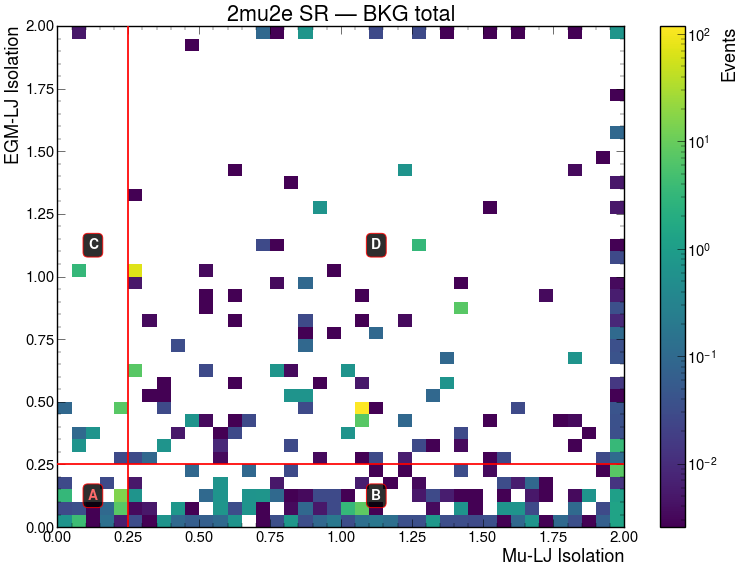

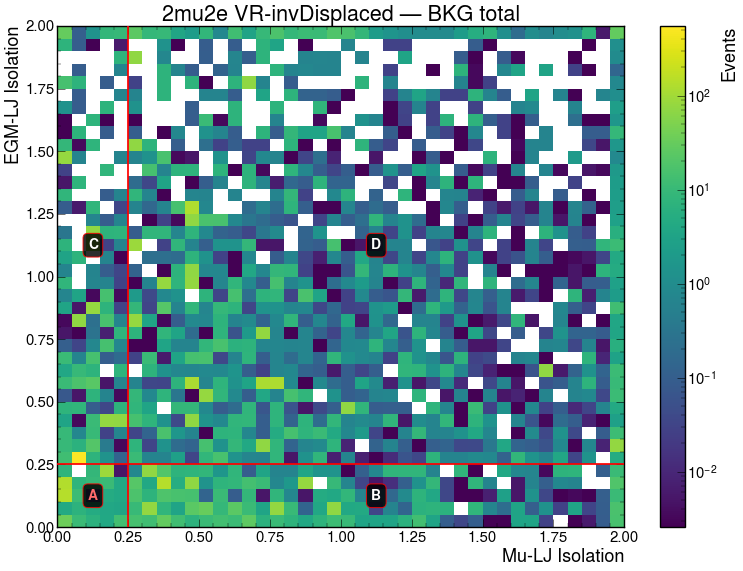

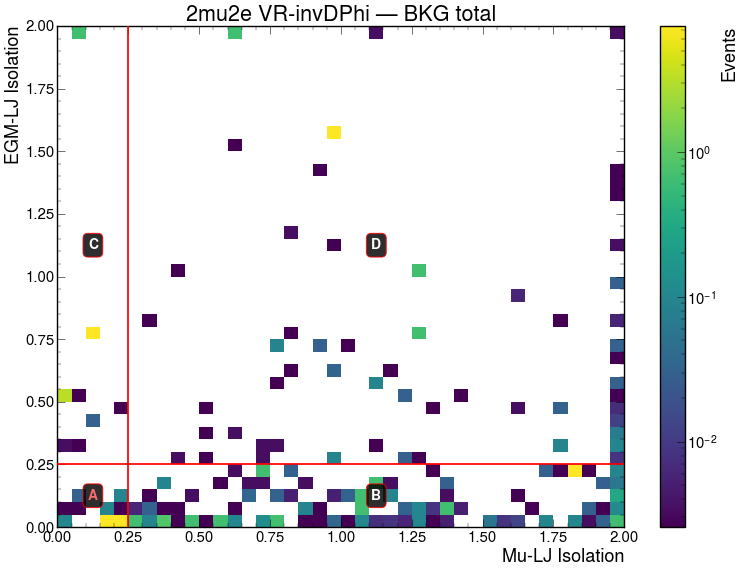

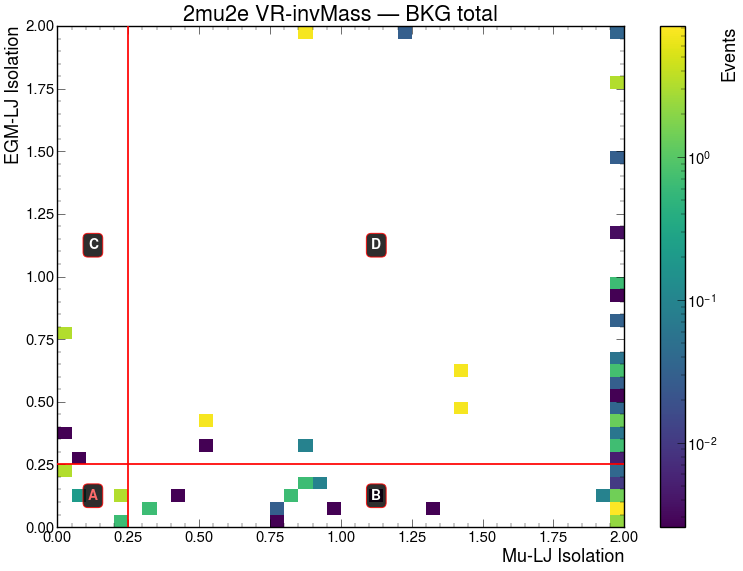

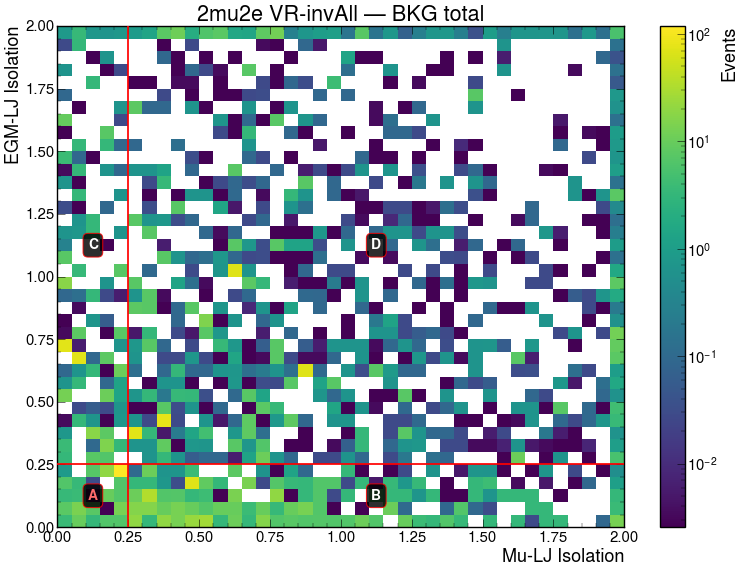

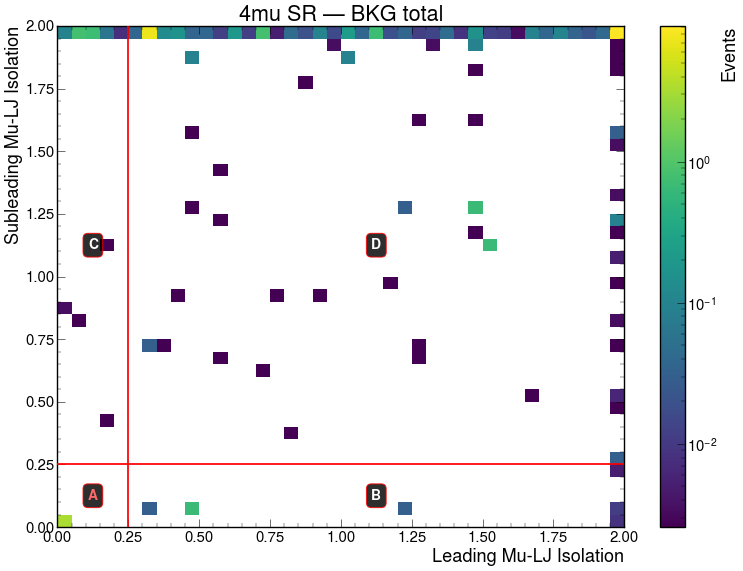

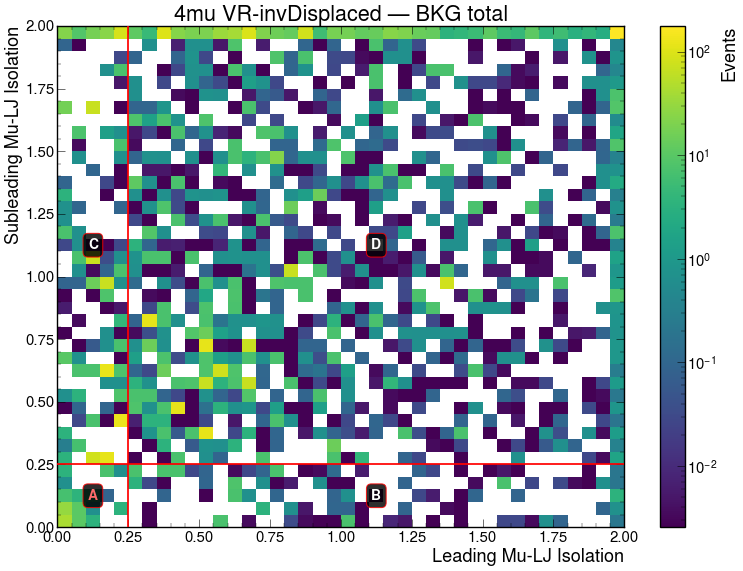

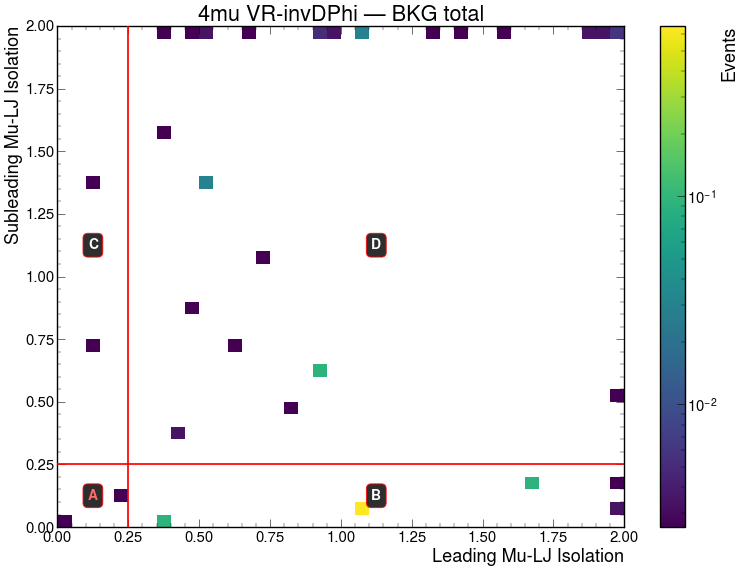

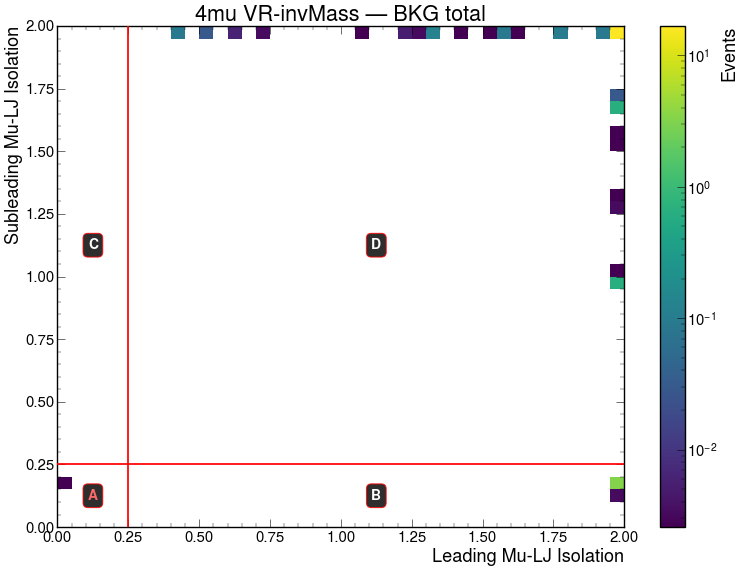

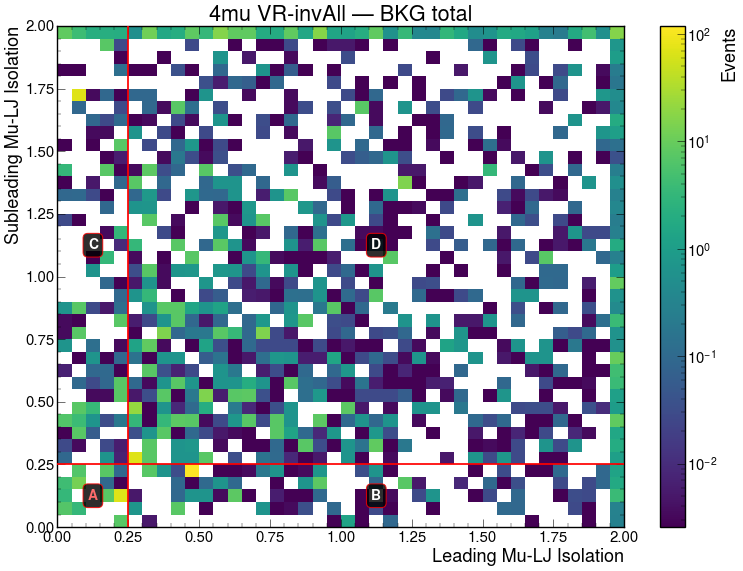

In [7]:
def plot_abcd_plane(h2d, title, cfg, blind_a=False):
    values, _ = values_variances(h2d)
    values = values.copy()
    masks = abcd_masks(h2d, *cfg["cuts"])
    if blind_a:
        values[masks["A"]] = np.nan
    xedges, yedges = h2d.axes[0].edges, h2d.axes[1].edges
    positive = values[np.isfinite(values) & (values > 0)]
    norm = LogNorm(vmin=max(positive.min(), 1e-8), vmax=positive.max()) if positive.size else None
    fig, ax = plt.subplots(figsize=(16, 12))
    mesh = ax.pcolormesh(xedges, yedges, values.T, shading="auto", cmap="viridis", norm=norm)
    xcut, ycut = cfg["cuts"]
    boundary_color = "r"
    ax.axvline(xcut, color=boundary_color, lw=2.5, zorder=3)
    ax.axhline(ycut, color=boundary_color, lw=2.5, zorder=3)
    positions = {
        "A": ((xedges[0]+xcut)/2, (yedges[0]+ycut)/2),
        "B": ((xcut+xedges[-1])/2, (yedges[0]+ycut)/2),
        "C": ((xedges[0]+xcut)/2, (ycut+yedges[-1])/2),
        "D": ((xcut+xedges[-1])/2, (ycut+yedges[-1])/2),
    }
    label_box = dict(boxstyle="round,pad=0.35", facecolor="black",
                     edgecolor=boundary_color, linewidth=1.5, alpha=0.82)
    for region, (xpos, ypos) in positions.items():
        label = "A (BLINDED)" if region == "A" and blind_a else region
        ax.text(xpos, ypos, label, ha="center", va="center", fontsize=20,
                fontweight="bold", color="#FF6B6B" if region == "A" else "white",
                bbox=label_box, zorder=4)
    ax.set(xlabel=cfg["x_label"], ylabel=cfg["y_label"], title=title)
    fig.colorbar(mesh, ax=ax, label="Events")
    fig.tight_layout()
    return fig, ax


for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in SELECTIONS:
        h2d = group_hist("BKG total", topology, region_type)
        if h2d is None:
            continue
        plot_abcd_plane(h2d, f"{topology} {region_type} — BKG total", cfg)
        plt.show()
        plt.close()


In [8]:
rows = []
groups = [*BACKGROUND_ORDER, "BKG total"]
for topology, cfg in CHANNEL_CONFIGS.items():
    for region_type in SELECTIONS:
        for group in groups:
            h2d = group_hist(group, topology, region_type)
            if h2d is None:
                continue
            y, pred, epred, kappa, ekappa, pull = closure(h2d, cfg["cuts"])
            row = {"topology": topology, "selection": region_type, "group": group,
                   "A_pred": pred, "A_pred_err": epred, "kappa": kappa,
                   "kappa_err": ekappa, "pull": pull}
            for r, (v, e) in y.items():
                row[r], row[f"{r}_err"] = v, e
            rows.append(row)
summary_columns = ["topology", "selection", "group", "A_pred", "A_pred_err",
                   "kappa", "kappa_err", "pull", "A", "A_err", "B", "B_err",
                   "C", "C_err", "D", "D_err"]
abcd_summary = pd.DataFrame(rows, columns=summary_columns)
display(abcd_summary)

,topology,selection,group,A_pred,A_pred_err,kappa,kappa_err,pull,A,A_err,B,B_err,C,C_err,D,D_err
0,2mu2e,SR,QCD,1.344413,1.464483,18.210236,21.985164,1.803692,24.482073,12.744073,33.595058,10.790015,8.869804,7.387737,221.644429,138.364387
1,2mu2e,SR,DY,NaN,NaN,NaN,NaN,NaN,3.248040,3.248040,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2mu2e,SR,TTJets,1.636827,2.588051,2.000000,3.741657,0.392232,3.273655,3.273655,3.273655,3.273655,3.273655,3.273655,6.547310,4.629647
3,2mu2e,SR,Diboson,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2mu2e,SR,BKG total,1.962007,1.865866,15.802071,16.539297,2.122839,31.003767,13.552784,36.868713,11.275693,12.143459,8.080562,228.191738,138.441819
5,2mu2e,VR-invDisplaced,QCD,382.658836,178.378229,0.995905,0.666426,-0.006133,381.091696,182.957109,971.552931,205.230822,1422.261275,571.411707,3611.055022,383.257708
6,2mu2e,VR-invDisplaced,DY,305.459656,223.596950,0.156542,0.131734,-1.147748,47.817257,19.850447,22.736277,8.593505,130.911281,31.969123,9.744119,5.625769
7,2mu2e,VR-invDisplaced,TTJets,60.752942,26.995184,1.401003,0.680465,0.767571,85.115024,16.692430,435.396087,37.753629,19.641929,8.018784,140.767156,21.466790
8,2mu2e,VR-invDisplaced,Diboson,NaN,NaN,NaN,NaN,NaN,8.058421,1.336635,2.026686,0.701471,1.209779,0.570223,0.000000,0.000000
9,2mu2e,VR-invDisplaced,BKG total,599.098679,242.558931,0.871446,0.468643,-0.252570,522.082398,184.791147,1431.711980,208.852501,1574.024265,572.361765,3761.566297,383.899652


In [9]:
transfer_rows = []
for topology in CHANNEL_CONFIGS:
    frame = abcd_summary[(abcd_summary.topology == topology) & (abcd_summary.group == "BKG total")]
    sr = frame[frame.selection == "SR"]
    if sr.empty:
        continue
    sr = sr.iloc[0]
    for validation_selection in VR_SELECTIONS:
        vr = frame[frame.selection == validation_selection]
        if vr.empty:
            continue
        vr = vr.iloc[0]
        ratio = sr.kappa / vr.kappa if vr.kappa > 0 else np.nan
        error = abs(ratio) * np.sqrt((sr.kappa_err / sr.kappa) ** 2 + (vr.kappa_err / vr.kappa) ** 2)             if sr.kappa > 0 and vr.kappa > 0 else np.nan
        transfer_rows.append({
            "topology": topology, "validation_selection": validation_selection,
            "kappa_SR_MC": sr.kappa, "kappa_SR_MC_err": sr.kappa_err,
            "kappa_VR_MC": vr.kappa, "kappa_VR_MC_err": vr.kappa_err,
            "R_kappa_SR_over_VR": ratio, "R_kappa_err": error,
        })
transfer_summary = pd.DataFrame(transfer_rows)
display(transfer_summary)


,topology,validation_selection,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,VR-invDisplaced,15.802071,16.539297,0.871446,0.468643,18.133152,21.337774
1,2mu2e,VR-invDPhi,15.802071,16.539297,0.801083,1.046908,19.725876,33.027628
2,2mu2e,VR-invMass,15.802071,16.539297,5.831961,7.935224,2.709564,4.651333
3,2mu2e,VR-invAll,15.802071,16.539297,0.837145,0.483165,18.876144,22.561494
4,4mu,VR-invDisplaced,57.170099,87.455540,4.180947,1.793683,13.673961,21.724672
5,4mu,VR-invDPhi,57.170099,87.455540,0.247433,0.337577,231.052982,473.601003
6,4mu,VR-invMass,57.170099,87.455540,NaN,NaN,NaN,NaN
7,4mu,VR-invAll,57.170099,87.455540,3.108924,3.033048,18.389032,33.364295


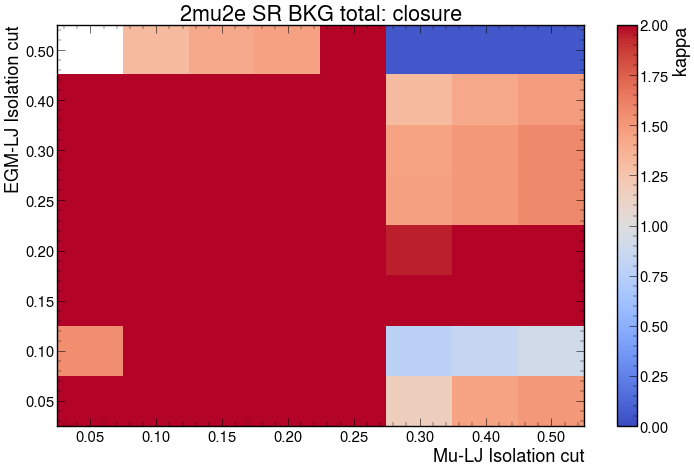

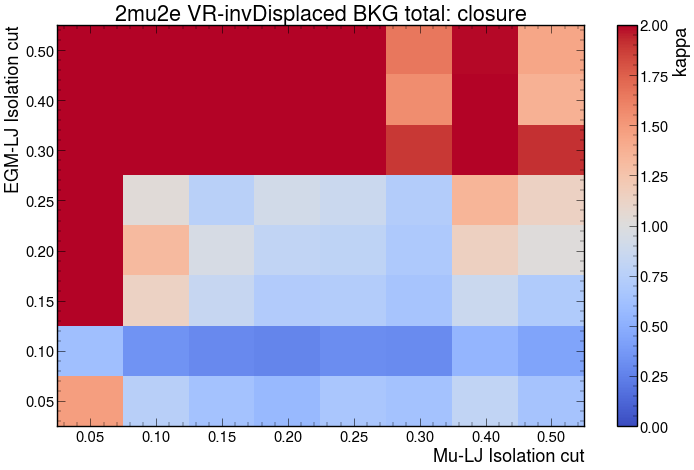

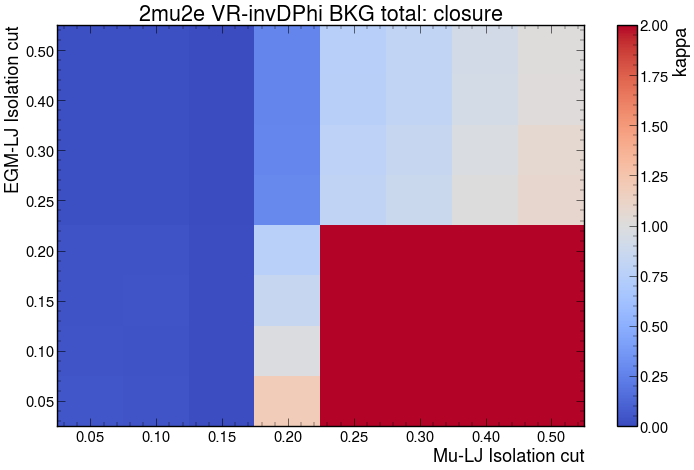

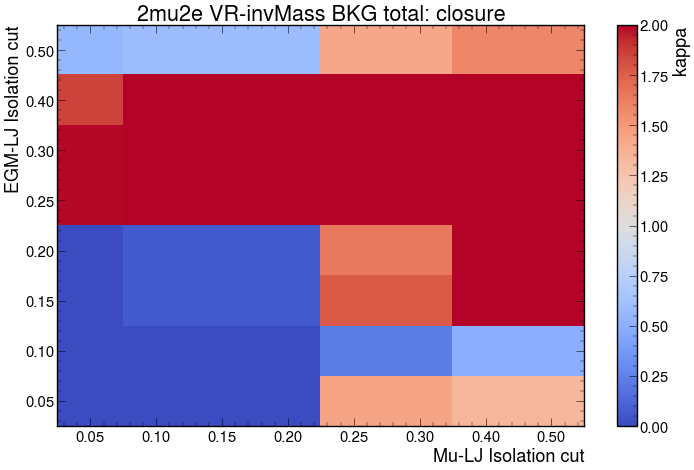

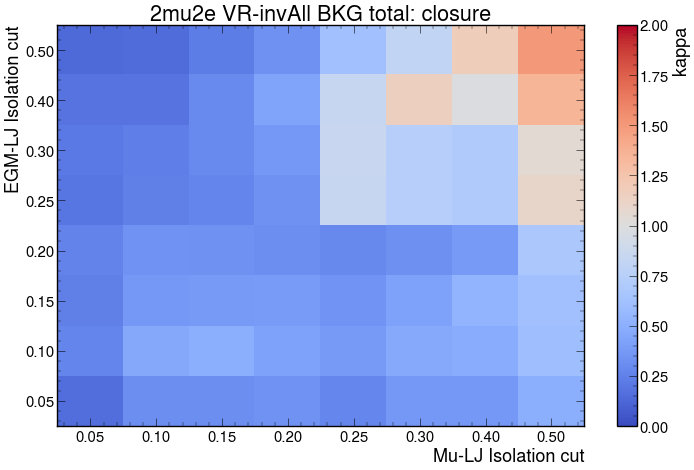

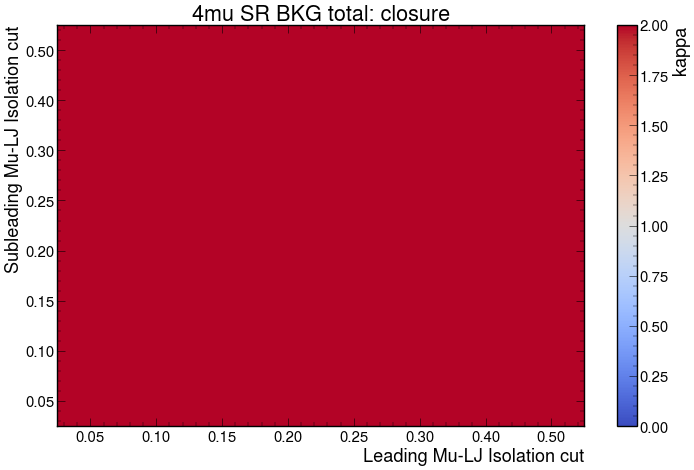

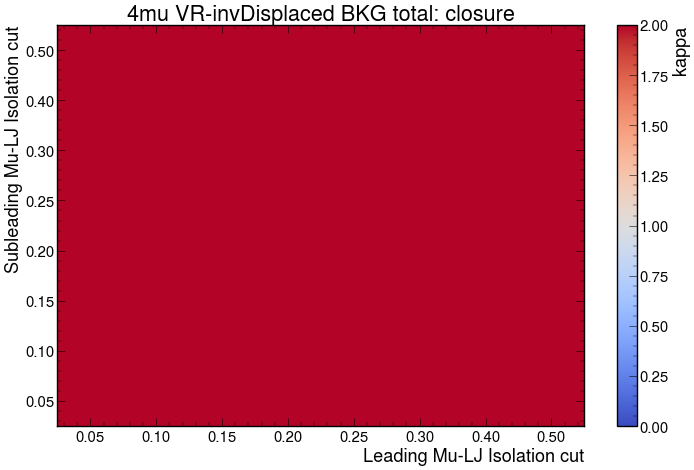

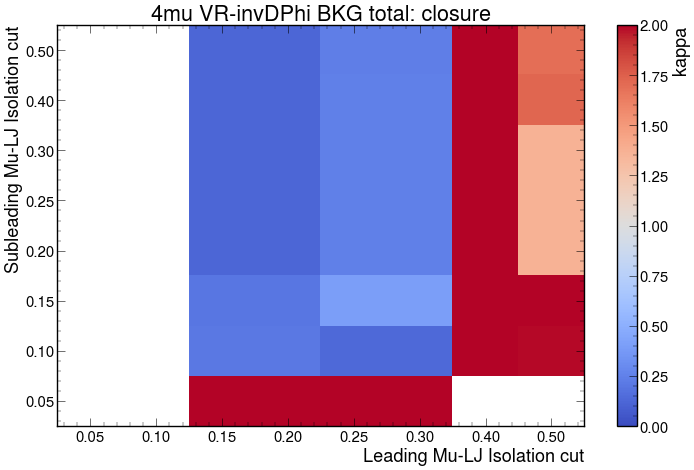

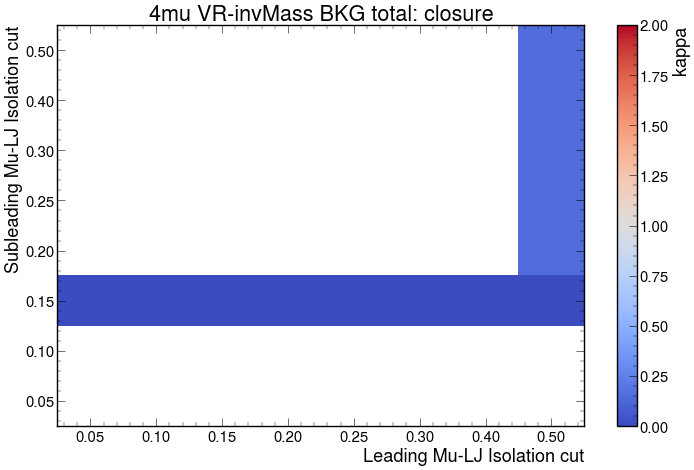

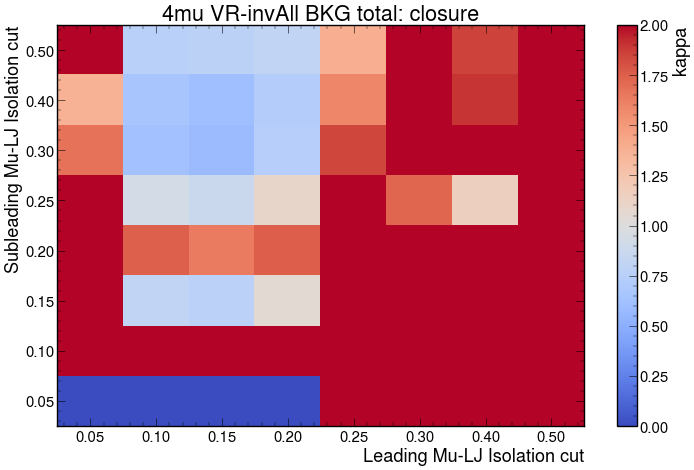

In [10]:
def scan_working_points(h2d, scan_values):
    rows = []
    for xcut in scan_values:
        for ycut in scan_values:
            y, pred, epred, kappa, ekappa, pull = closure(h2d, (xcut, ycut))
            rows.append({"xcut": xcut, "ycut": ycut, "kappa": kappa, "kappa_err": ekappa,
                         "pull": pull, "pred": pred,
                         "relative_pred_err": epred/pred if pred > 0 else np.nan,
                         "min_control_yield": min(y[r][0] for r in ["B", "C", "D"])})
    return pd.DataFrame(rows)


def heatmap(frame, value, title, x_label, y_label, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel=f"{x_label} cut", ylabel=f"{y_label} cut", title=title)
    fig.colorbar(im, ax=ax, label=value); fig.tight_layout()


wp_scans = {}
for topology, cfg in CHANNEL_CONFIGS.items():
    for selection in SELECTIONS:
        group = "BKG total"
        h2d = group_hist(group, topology, selection)
        if h2d is None:
            continue
        key = (topology, selection, group)
        wp_scans[key] = scan_working_points(h2d, SCAN_VALUES)
        heatmap(
            wp_scans[key], "kappa", f"{topology} {selection} {group}: closure",
            cfg["x_label"], cfg["y_label"], "coolwarm", 0, 2,
        )
        plt.show()

In [11]:
def weighted_corr(h2d):
    w, _ = values_variances(h2d)
    x, y = np.meshgrid(h2d.axes[0].centers, h2d.axes[1].centers, indexing="ij")
    mask = np.isfinite(w) & (w > 0)
    if not mask.any(): return np.nan
    w, x, y = w[mask], x[mask], y[mask]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x-mx)*(y-my), weights=w)
    vx, vy = np.average((x-mx)**2, weights=w), np.average((y-my)**2, weights=w)
    return cov/np.sqrt(vx*vy) if vx > 0 and vy > 0 else np.nan


corr_rows = []
for topology in CHANNEL_CONFIGS:
    for selection in SELECTIONS:
        for group in [*BACKGROUND_ORDER, "BKG total"]:
            h2d = group_hist(group, topology, selection)
            if h2d is not None:
                corr_rows.append({"topology": topology, "selection": selection,
                                  "group": group, "weighted_Pearson": weighted_corr(h2d)})
correlation_summary = pd.DataFrame(corr_rows)
display(correlation_summary)

,topology,selection,group,weighted_Pearson
0,2mu2e,SR,QCD,-0.361118
1,2mu2e,SR,DY,NaN
2,2mu2e,SR,TTJets,-0.064381
3,2mu2e,SR,Diboson,NaN
4,2mu2e,SR,BKG total,-0.300490
5,2mu2e,VR-invDisplaced,QCD,0.082152
6,2mu2e,VR-invDisplaced,DY,-0.061823
7,2mu2e,VR-invDisplaced,TTJets,0.133552
8,2mu2e,VR-invDisplaced,Diboson,-0.047094
9,2mu2e,VR-invDisplaced,BKG total,0.072196


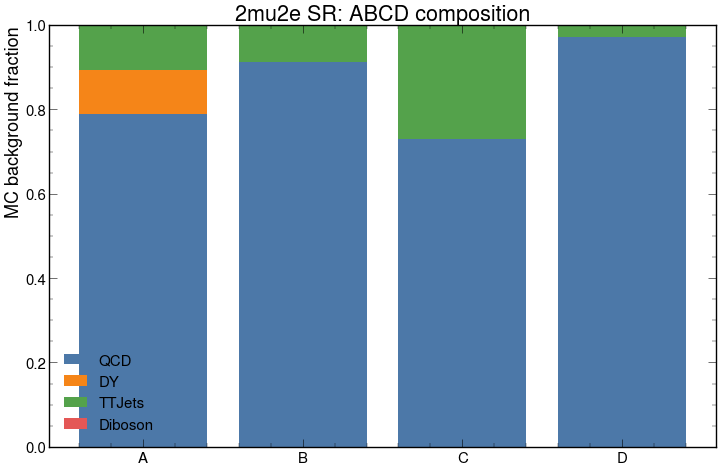

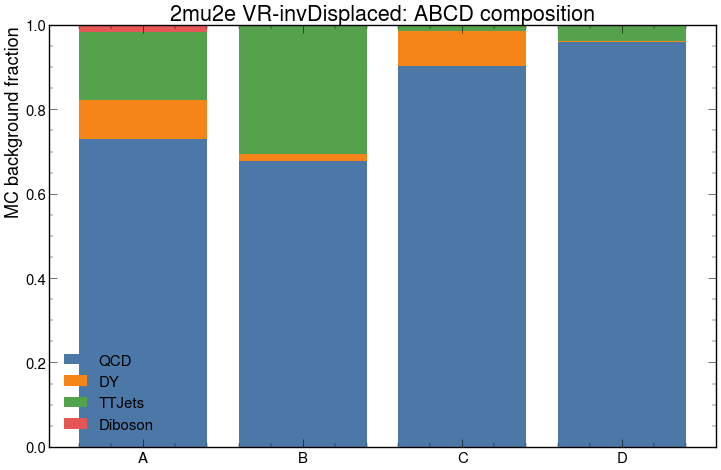

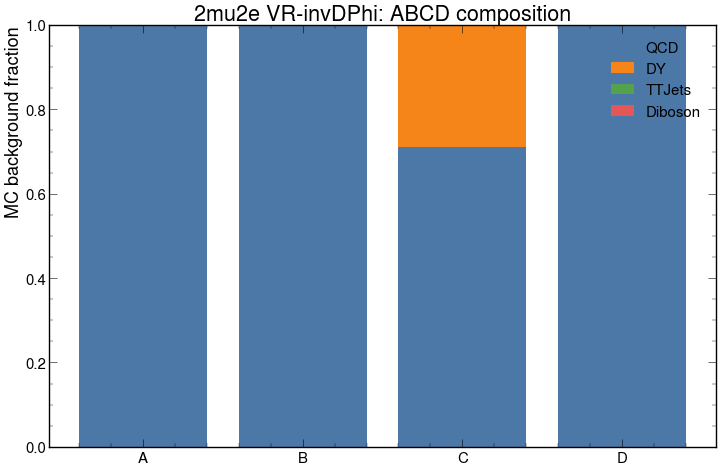

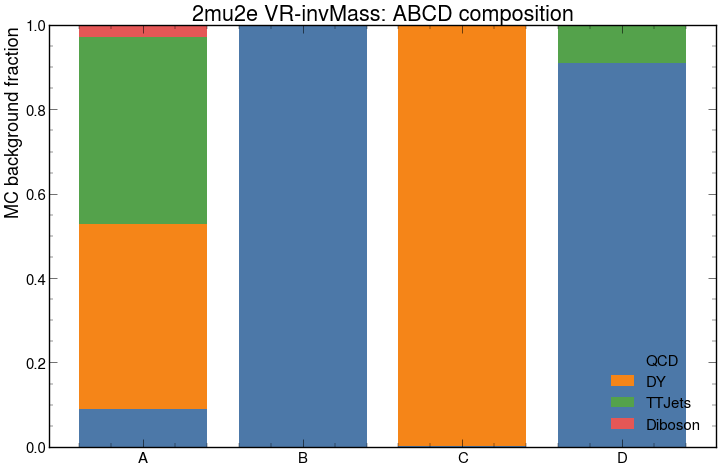

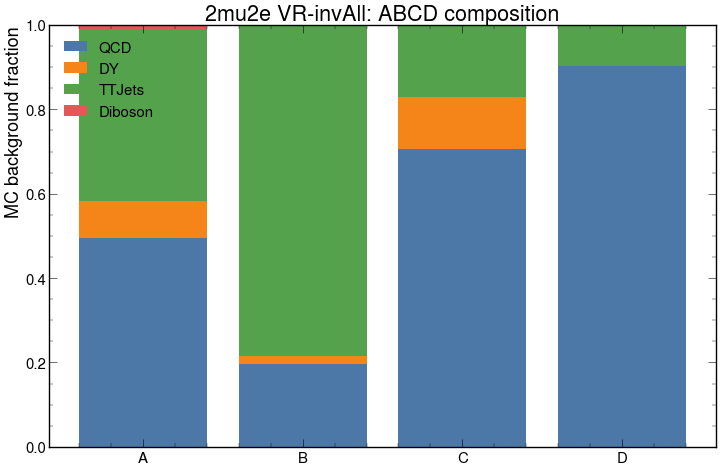

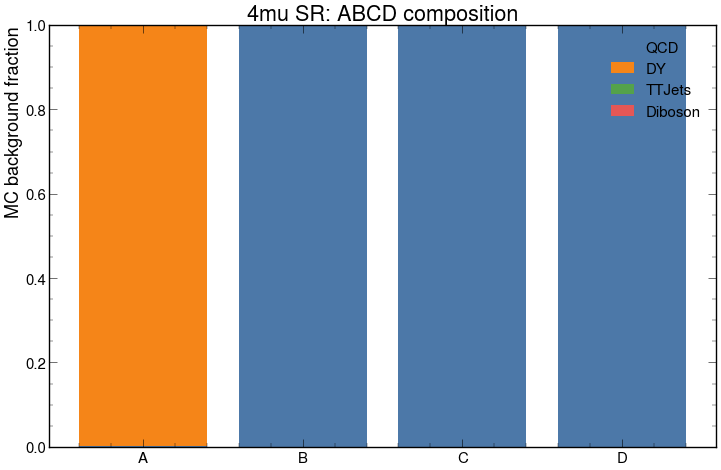

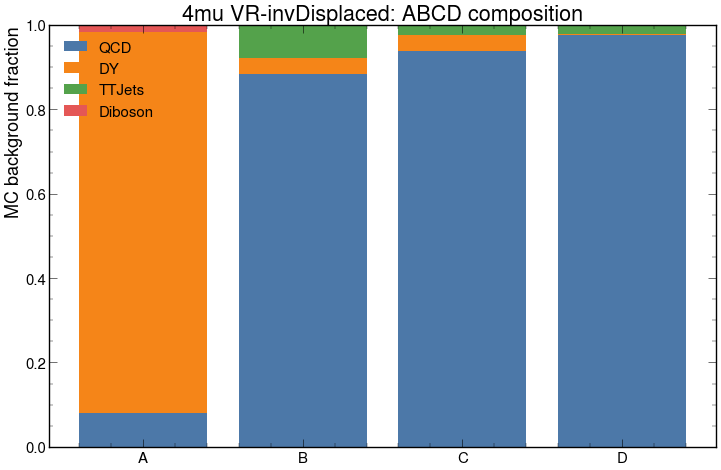

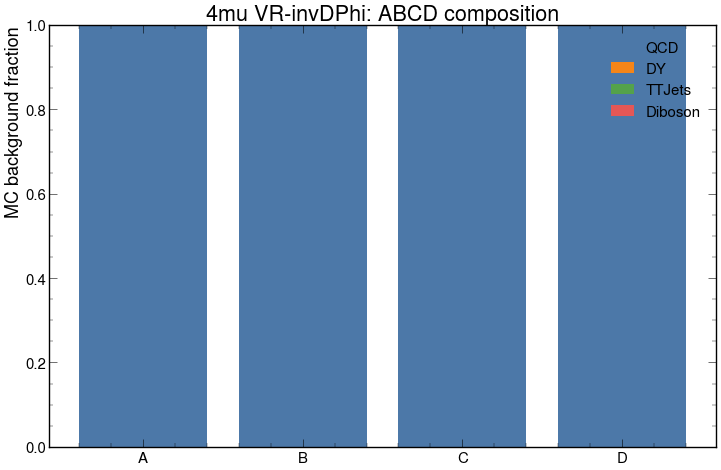

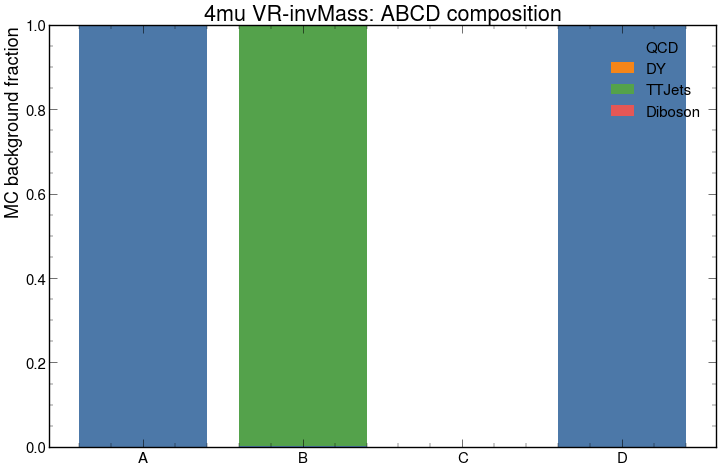

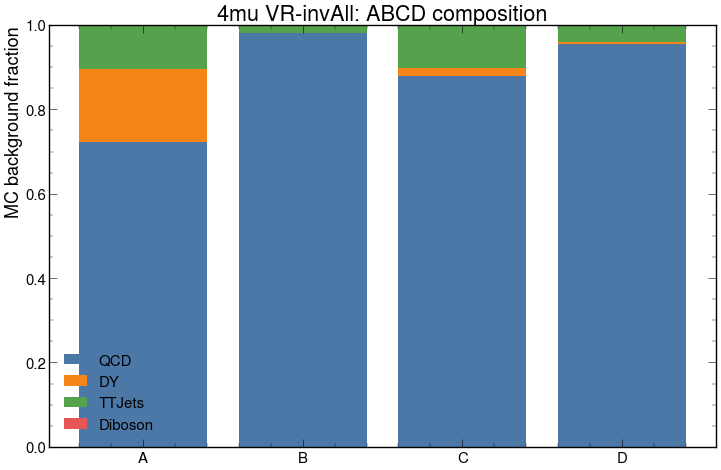

In [12]:
composition = abcd_summary[abcd_summary.group.isin(BACKGROUND_ORDER)].copy()
if not composition.empty:
    for topology in CHANNEL_CONFIGS:
        for selection in SELECTIONS:
            frame = composition[(composition.topology == topology) & (composition.selection == selection)]
            if frame.empty: continue
            regions = ["A", "B", "C", "D"]
            totals = frame[regions].sum(axis=0).to_numpy(float)
            bottom = np.zeros(4)
            fig, ax = plt.subplots(figsize=(15, 10))
            for group in BACKGROUND_ORDER:
                vals = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy(float)
                frac = np.divide(vals, totals, out=np.zeros_like(vals), where=totals != 0)
                ax.bar(regions, frac, bottom=bottom, label=group, color=COLORS[group])
                bottom += frac
            ax.set(ylabel="MC background fraction", ylim=(0,1),
                   title=f"{topology} {selection}: ABCD composition")
            ax.legend(frameon=False); fig.tight_layout(); plt.show()

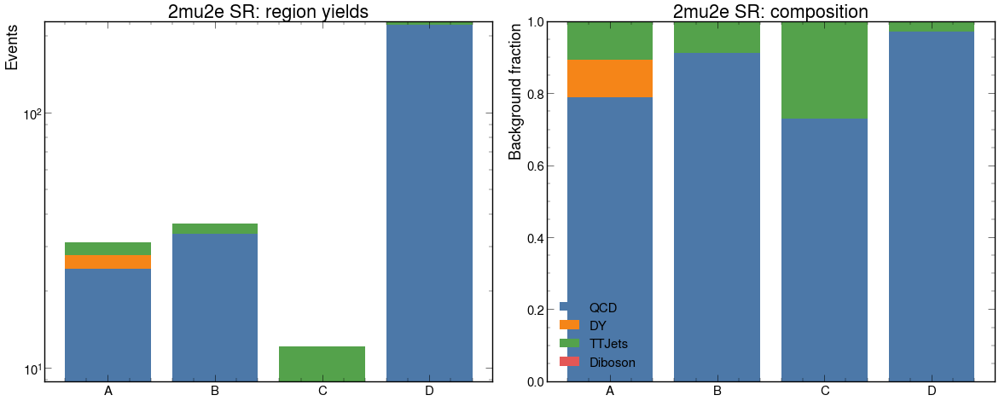

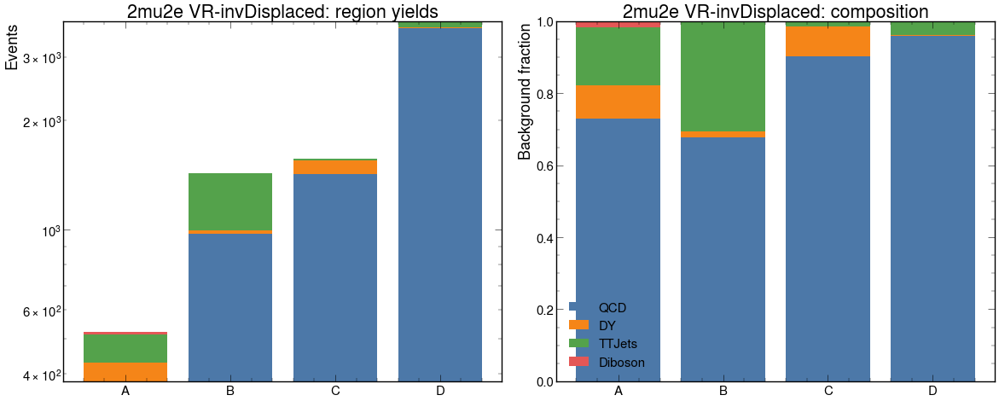

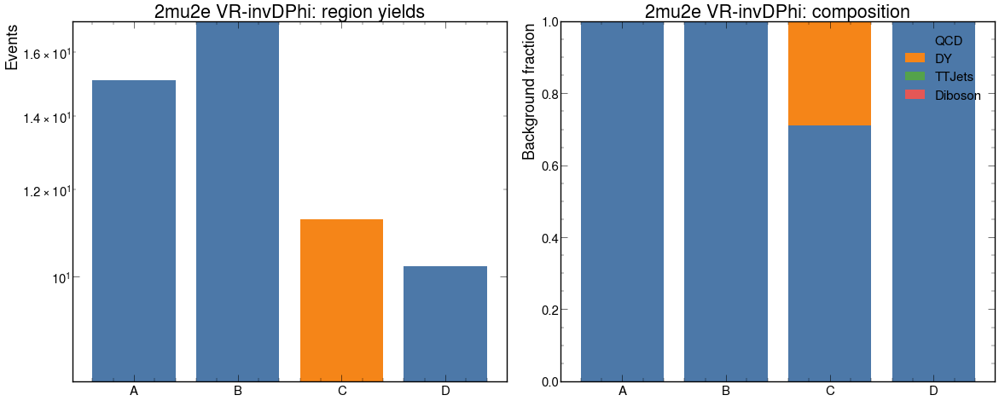

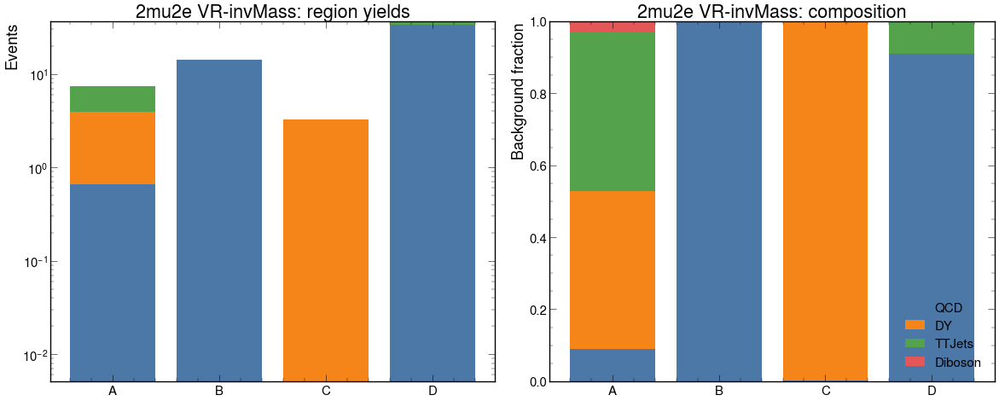

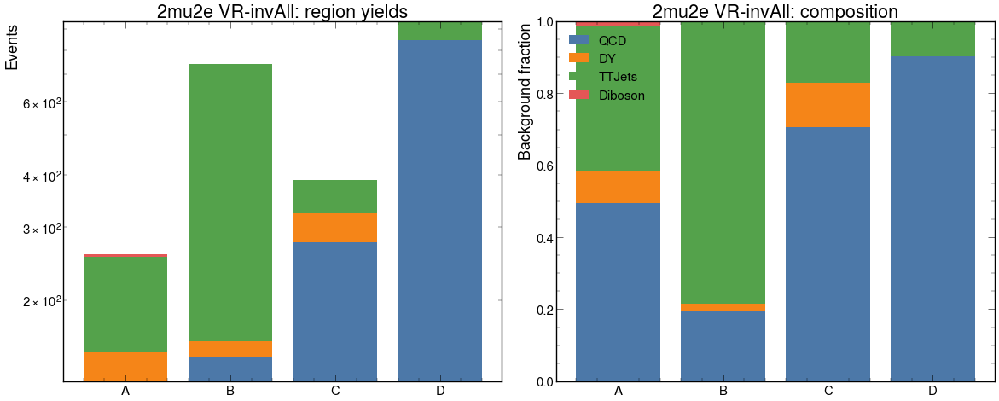

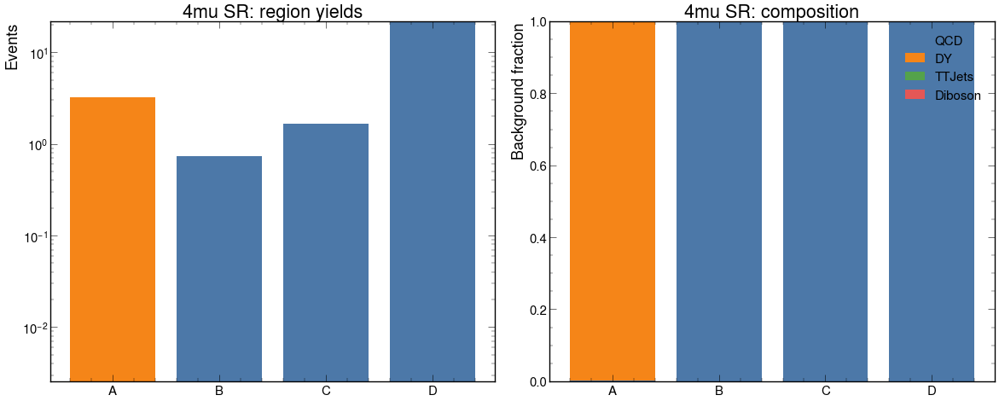

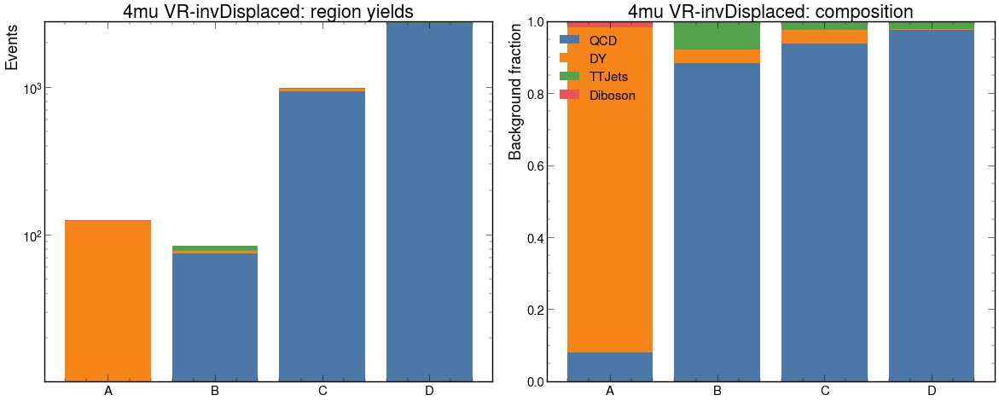

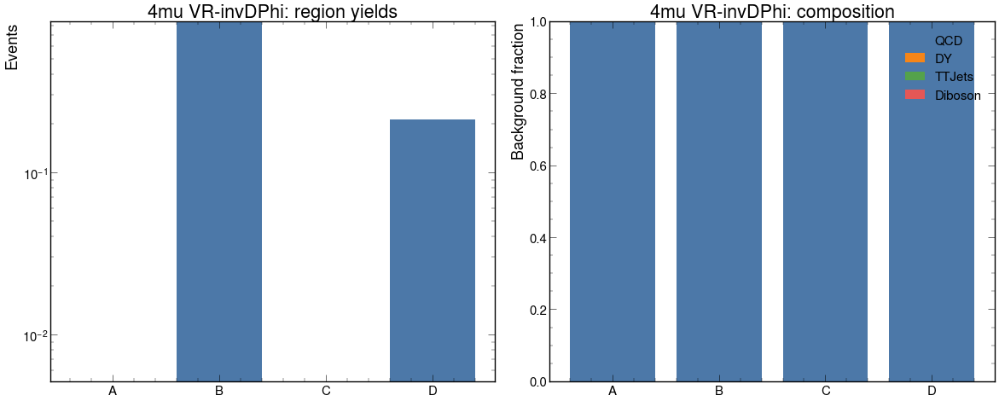

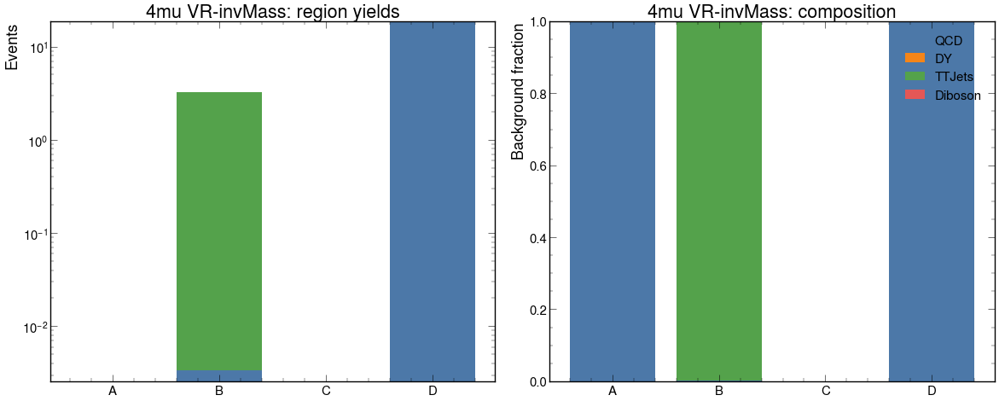

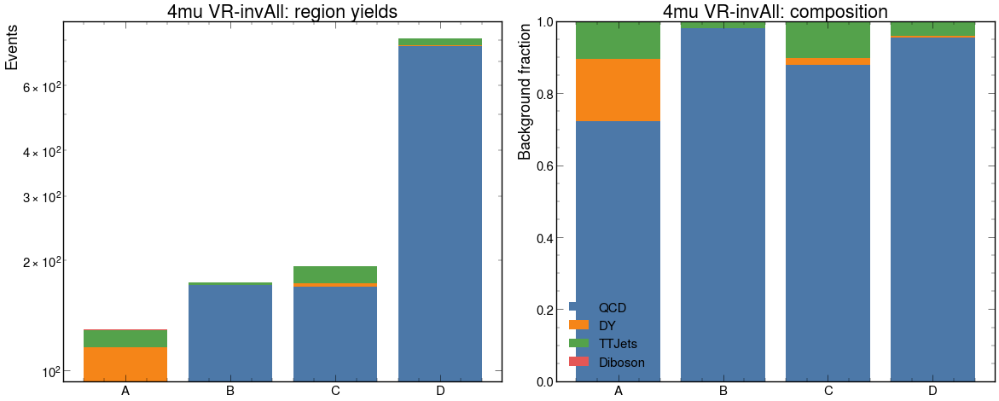

In [13]:
def plot_region_composition(summary, topology, selection):
    frame = summary[(summary.topology == topology) & (summary.selection == selection)
                    & summary.group.isin(BACKGROUND_ORDER)].copy()
    if frame.empty: return None
    regions = ["A", "B", "C", "D"]
    totals = frame[regions].sum(axis=0).to_numpy(float)
    bottom_y, bottom_f = np.zeros(4), np.zeros(4)
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    for group in BACKGROUND_ORDER:
        vals = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy(float)
        frac = np.divide(vals, totals, out=np.zeros_like(vals), where=totals != 0)
        axes[0].bar(regions, vals, bottom=bottom_y, label=group, color=COLORS[group])
        axes[1].bar(regions, frac, bottom=bottom_f, label=group, color=COLORS[group])
        bottom_y += vals; bottom_f += frac
    axes[0].set(ylabel="Events", title=f"{topology} {selection}: region yields")
    if np.any(totals > 0): axes[0].set_yscale("log")
    axes[1].set(ylabel="Background fraction", ylim=(0,1), title=f"{topology} {selection}: composition")
    axes[1].legend(frameon=False); fig.tight_layout()
    return fig

for topology in CHANNEL_CONFIGS:
    for selection in SELECTIONS:
        if plot_region_composition(abcd_summary, topology, selection):
            plt.show(); plt.close()


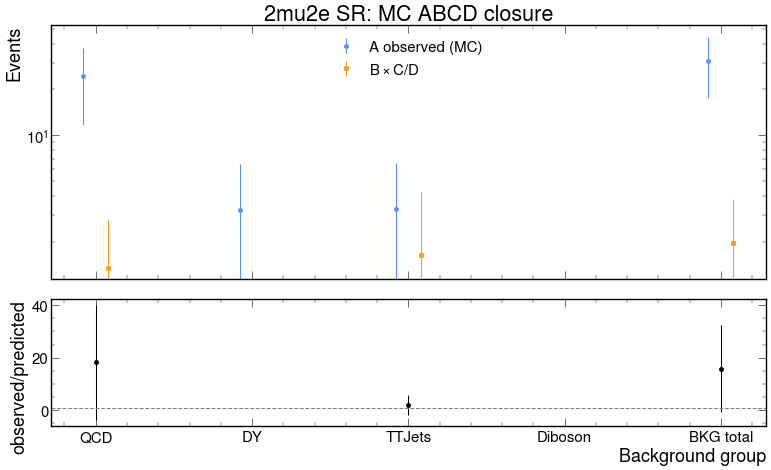

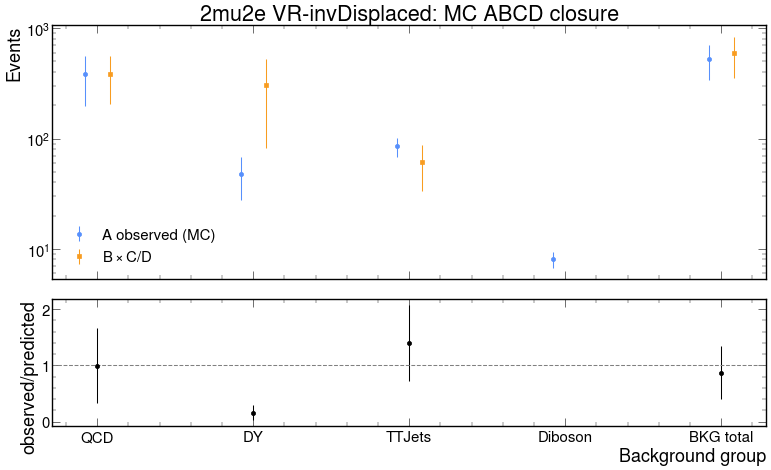

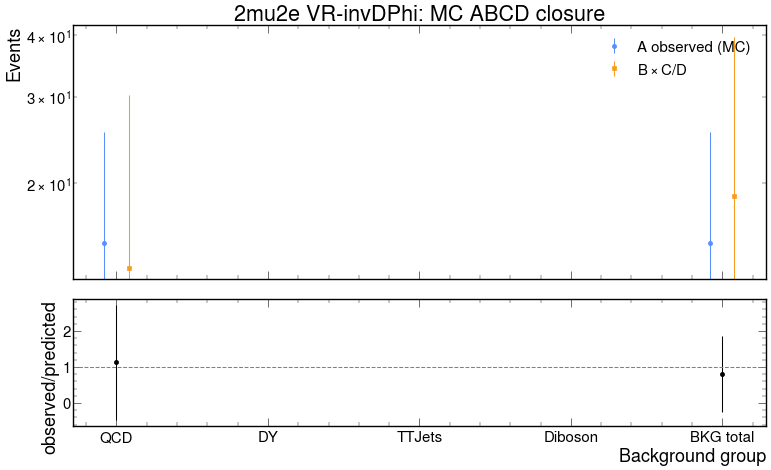

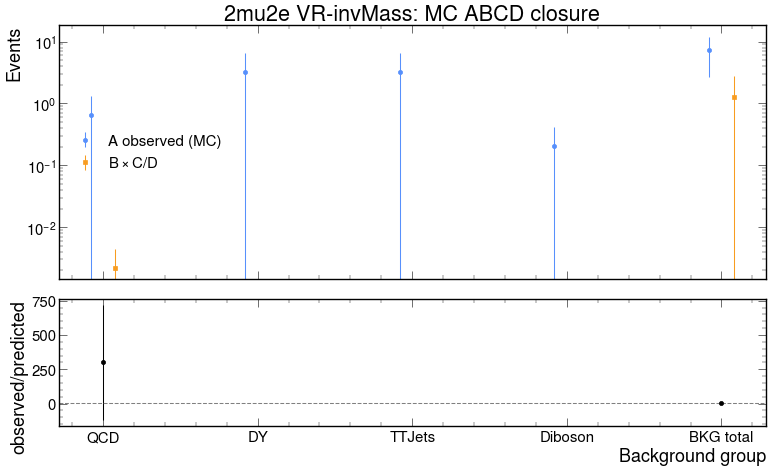

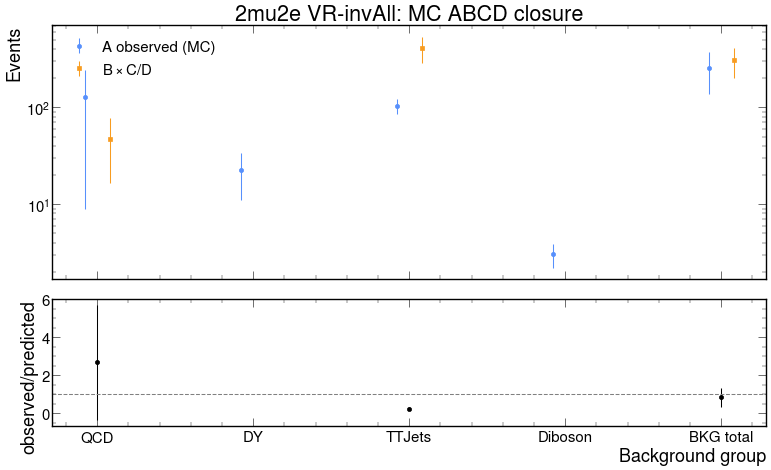

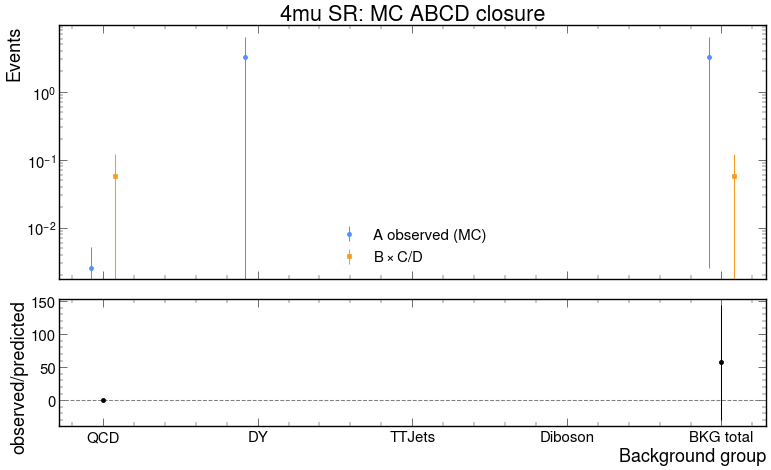

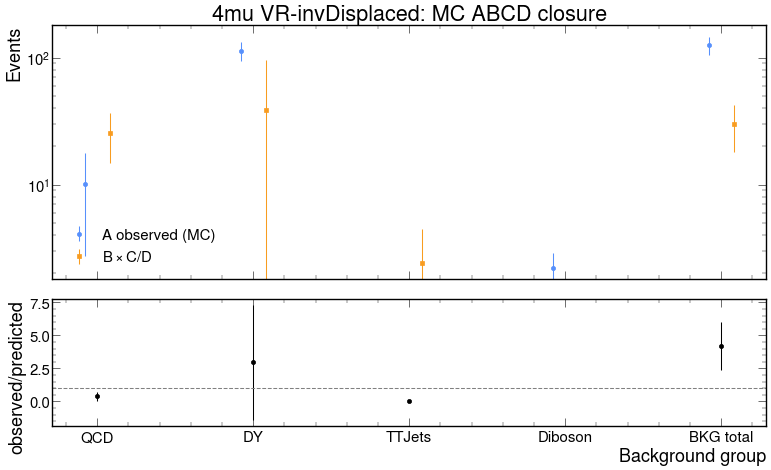

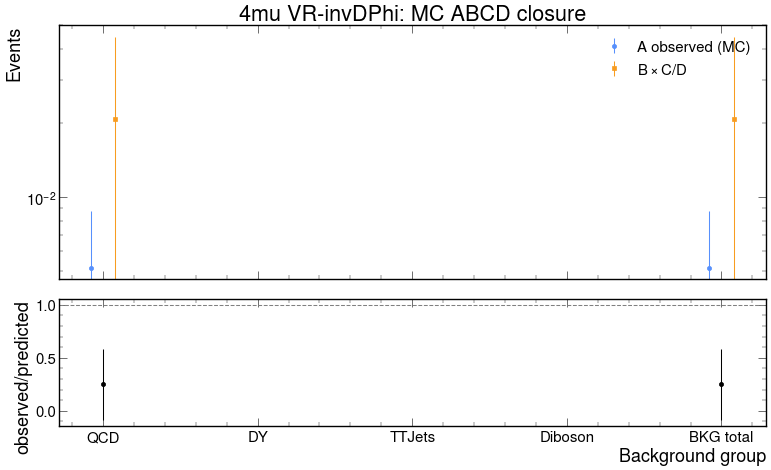

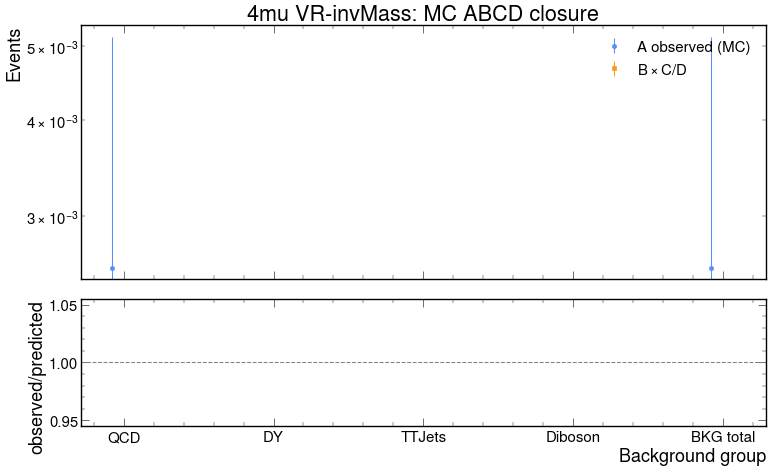

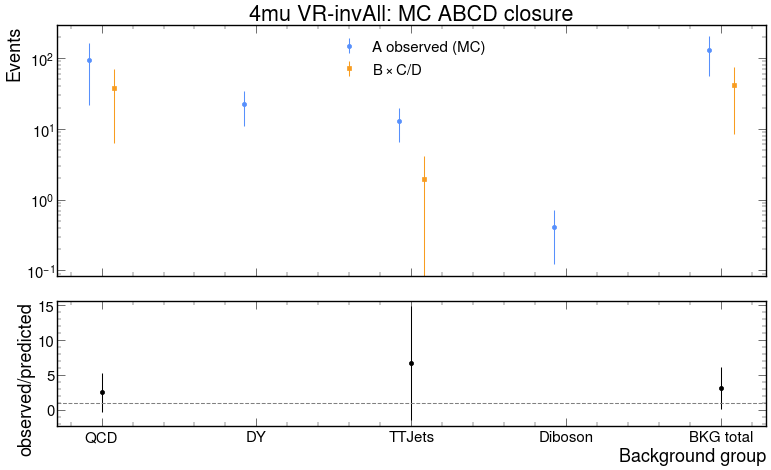

In [14]:
def plot_mc_closure(summary, topology, selection):
    frame = summary[(summary.topology == topology) & (summary.selection == selection)
                    & summary.group.isin([*BACKGROUND_ORDER, "BKG total"])].copy()
    if frame.empty: return None
    x = np.arange(len(frame))
    fig, axes = plt.subplots(2,1,figsize=(16,10),sharex=True,gridspec_kw={"height_ratios":[2,1]})
    axes[0].errorbar(x-.08,frame.A,yerr=frame.A_err,fmt="o",label="A observed (MC)")
    axes[0].errorbar(x+.08,frame.A_pred,yerr=frame.A_pred_err,fmt="s",label=r"$B\times C/D$")
    axes[0].set(ylabel="Events",title=f"{topology} {selection}: MC ABCD closure")
    if np.any((frame.A>0)|(frame.A_pred>0)): axes[0].set_yscale("log")
    axes[0].legend(frameon=False)
    axes[1].errorbar(x,frame.kappa,yerr=frame.kappa_err,fmt="o",color="black")
    axes[1].axhline(1,color="gray",ls="--")
    axes[1].set(ylabel="observed/predicted",xticks=x,xticklabels=frame.group,xlabel="Background group")
    fig.tight_layout(); return fig

for topology in CHANNEL_CONFIGS:
    for selection in SELECTIONS:
        if plot_mc_closure(abcd_summary, topology, selection):
            plt.show(); plt.close()


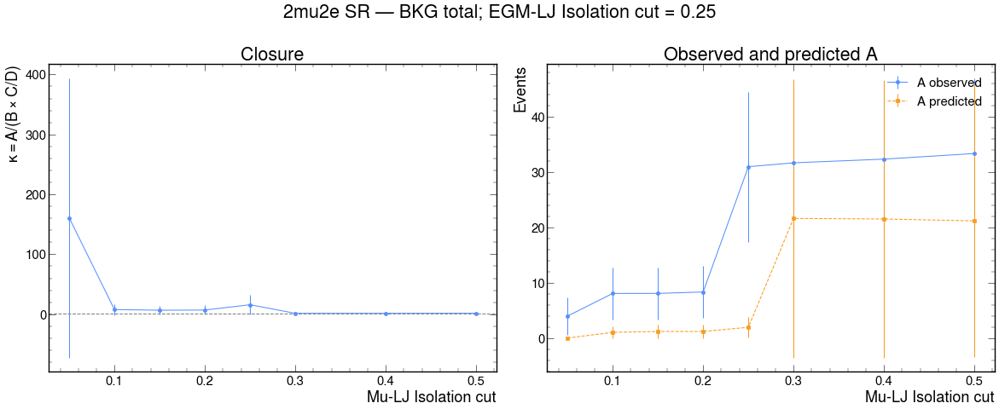

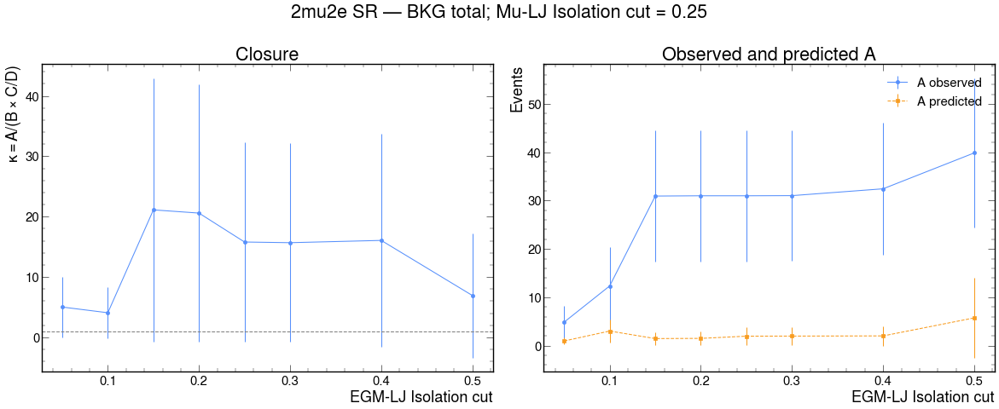

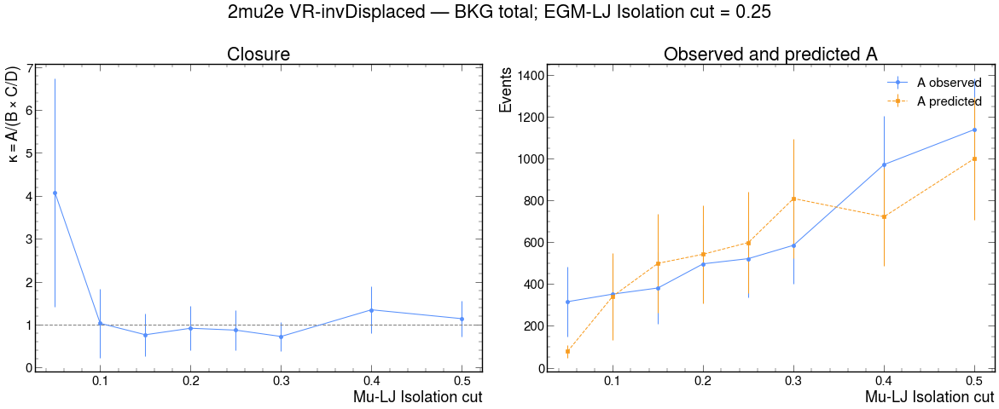

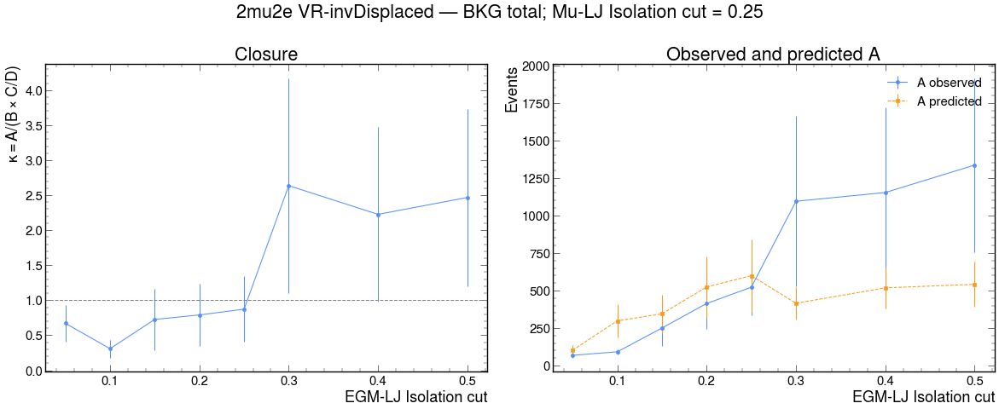

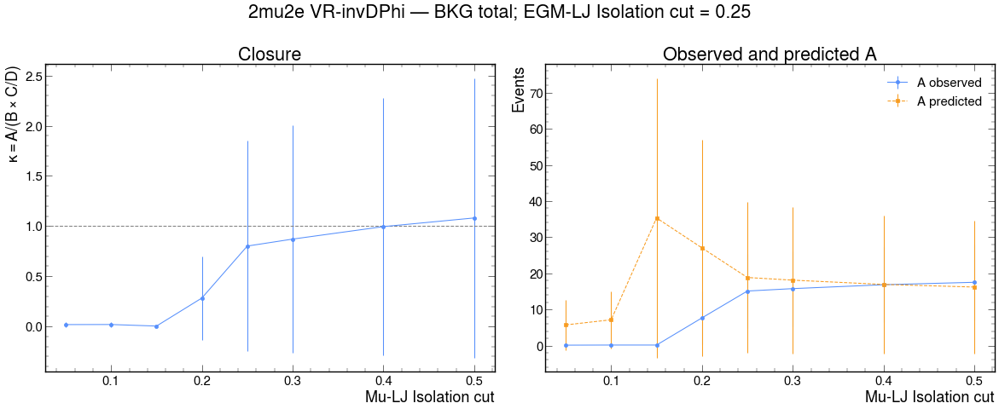

...

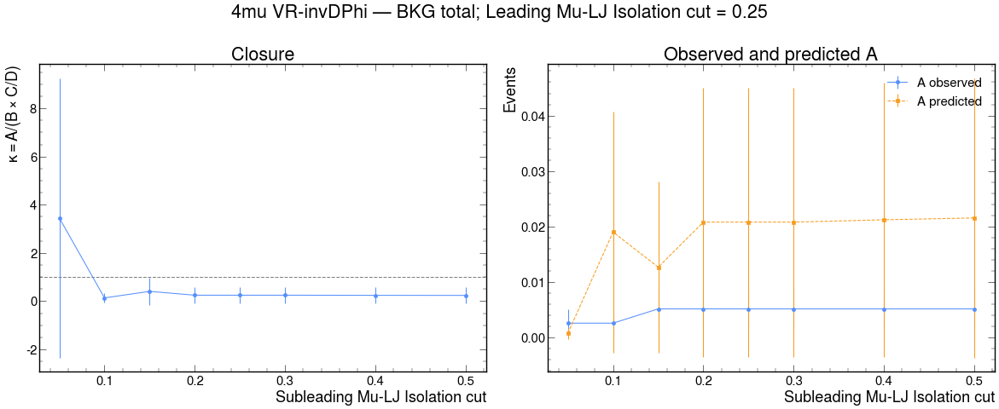

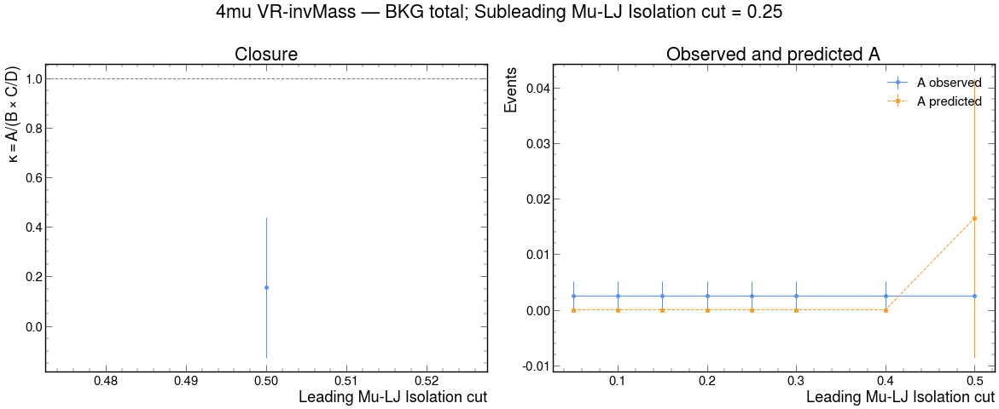

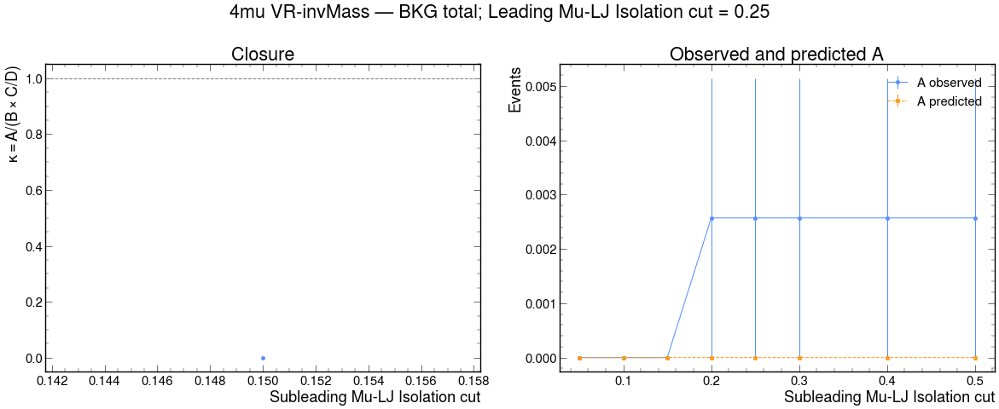

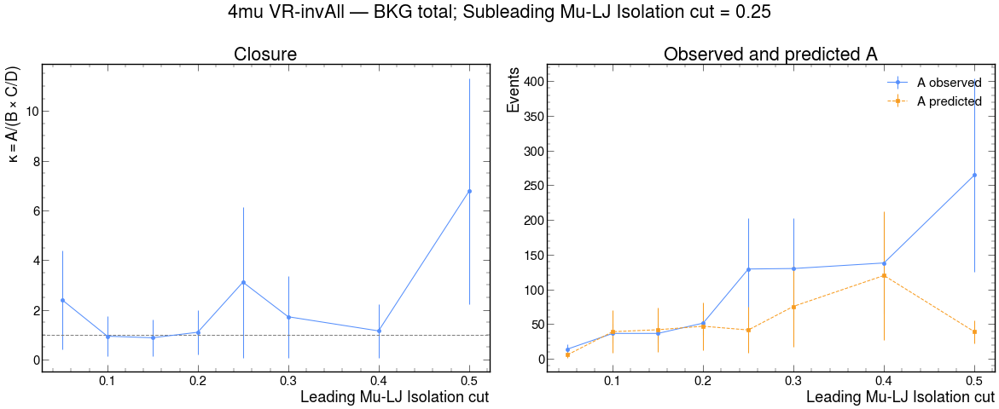

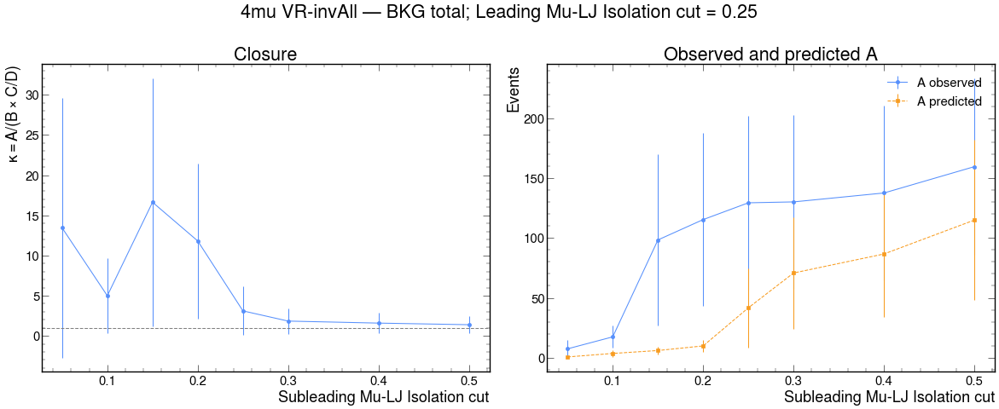

In [15]:
def scan_one_axis(h2d, scan_values, fixed_cut, scan_axis):
    rows=[]
    for cut in scan_values:
        cuts=(cut,fixed_cut) if scan_axis=="x" else (fixed_cut,cut)
        y,pred,epred,kappa,ekappa,pull=closure(h2d,cuts)
        rows.append({"scan_cut":cut,"A":y["A"][0],"A_err":y["A"][1],"A_pred":pred,
                     "A_pred_err":epred,"kappa":kappa,"kappa_err":ekappa,"pull":pull,
                     "min_control_yield":min(y[r][0] for r in ["B","C","D"])})
    return pd.DataFrame(rows)

def plot_one_axis_scan(frame,xlabel,title):
    fig,axes=plt.subplots(1,2,figsize=(24,10))
    axes[0].errorbar(frame.scan_cut,frame.kappa,yerr=frame.kappa_err,marker="o")
    axes[0].axhline(1,color="gray",ls="--")
    axes[0].set(xlabel=xlabel,ylabel=r"$\kappa=A/(B\times C/D)$",title="Closure")
    axes[1].errorbar(frame.scan_cut,frame.A,yerr=frame.A_err,marker="o",label="A observed")
    axes[1].errorbar(frame.scan_cut,frame.A_pred,yerr=frame.A_pred_err,marker="s",ls="--",label="A predicted")
    axes[1].set(xlabel=xlabel,ylabel="Events",title="Observed and predicted A")
    axes[1].legend(frameon=False); fig.suptitle(title); fig.tight_layout(); return fig

one_axis_scans={}
for topology,cfg in CHANNEL_CONFIGS.items():
    for selection in SELECTIONS:
        group = "BKG total"
        h2d=group_hist(group,topology,selection)
        if h2d is None: continue
        for index,axis_name in enumerate(["x","y"]):
            frame=scan_one_axis(h2d,SCAN_VALUES,cfg["cuts"][1-index],axis_name)
            one_axis_scans[(topology,selection,group,axis_name)]=frame
            axis_label = cfg["x_label"] if axis_name == "x" else cfg["y_label"]
            fixed_axis_label = cfg["y_label"] if axis_name == "x" else cfg["x_label"]
            fixed_value = cfg["cuts"][1 - index]
            plot_one_axis_scan(
                frame, f"{axis_label} cut",
                f"{topology} {selection} — {group}; {fixed_axis_label} cut = {fixed_value:.2f}",
            )
            plt.show(); plt.close()

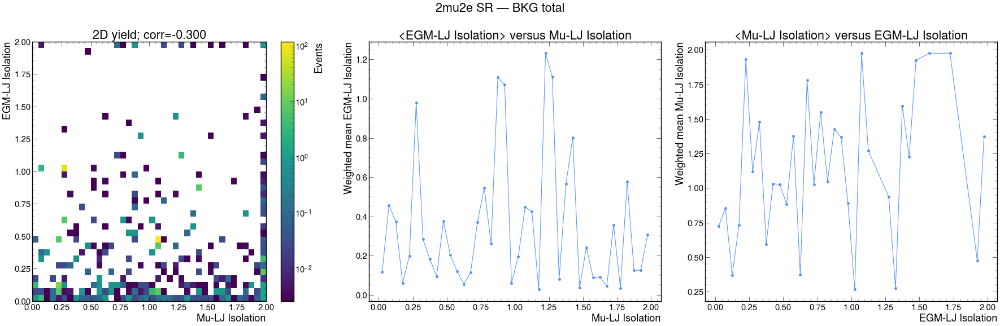

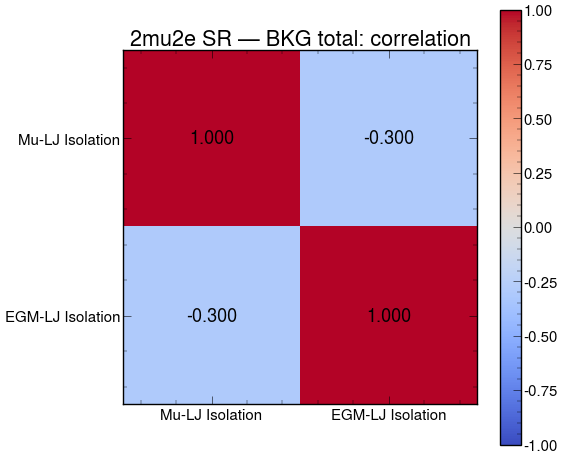

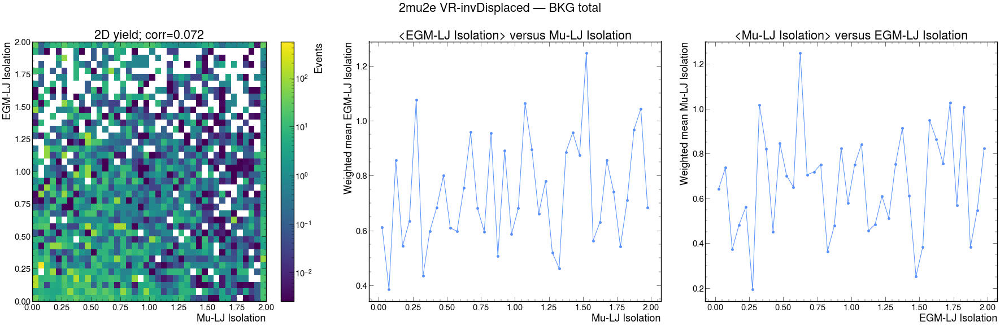

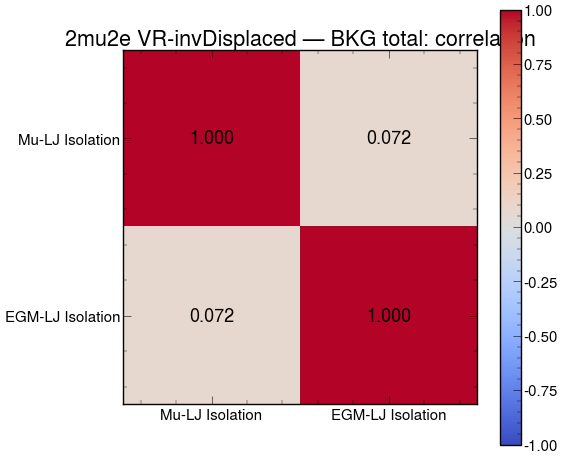

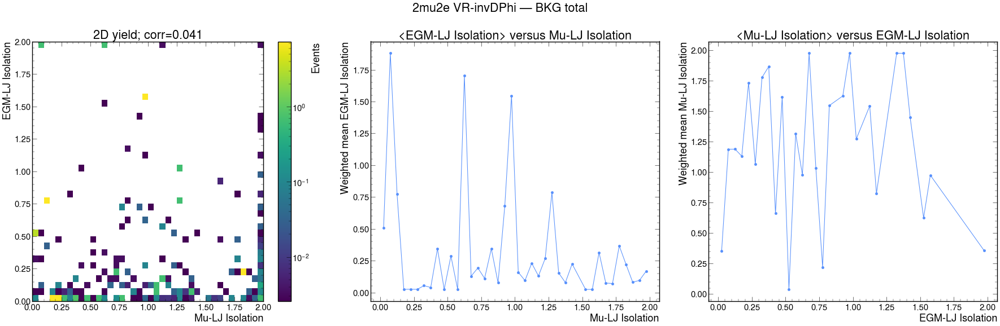

...

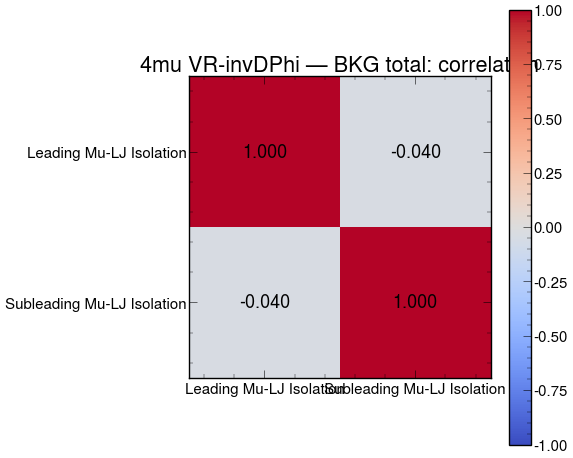

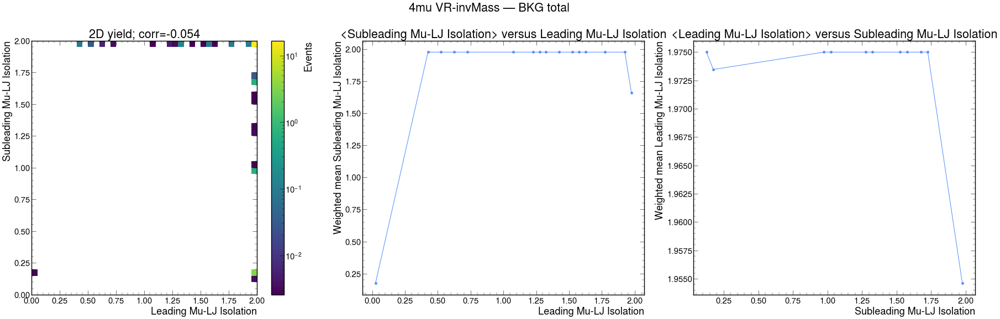

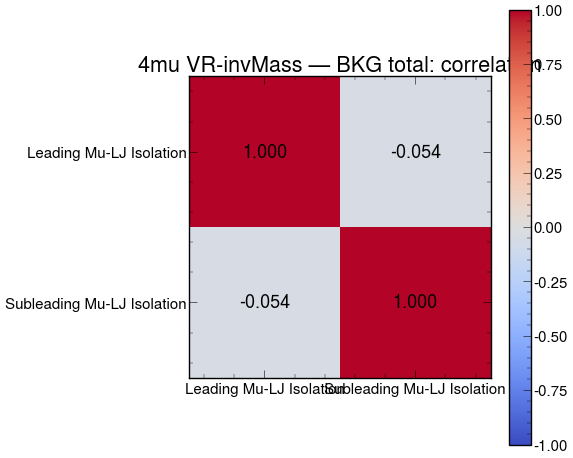

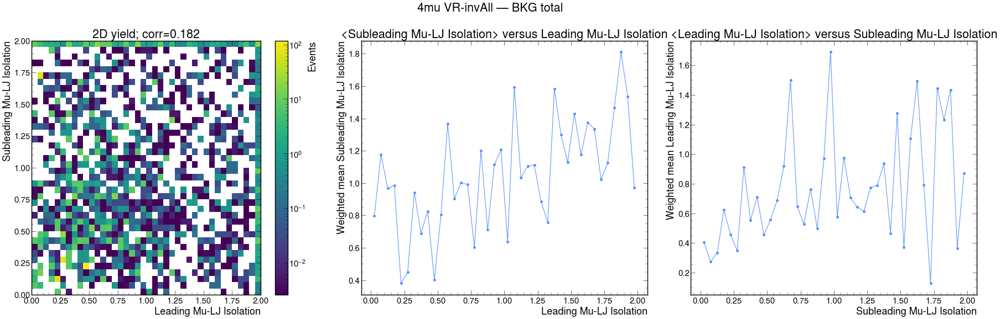

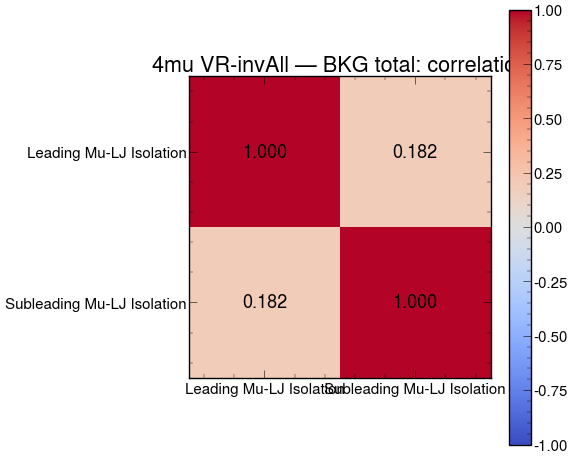

In [16]:
def hist2d_to_dataframe(h2d):
    x,y=np.meshgrid(h2d.axes[0].centers,h2d.axes[1].centers,indexing="ij")
    values,_=values_variances(h2d)
    return pd.DataFrame({"x":x.ravel(),"y":y.ravel(),"yield":values.ravel()})

def plot_correlation_profile(h2d,title,cfg):
    frame=hist2d_to_dataframe(h2d)
    positive=frame[np.isfinite(frame["yield"])&(frame["yield"]>0)].copy()
    folded_values,_=values_variances(h2d); corr=weighted_corr(h2d); values=folded_values.T
    pos=values[np.isfinite(values)&(values>0)]
    norm=LogNorm(vmin=max(pos.min(),1e-12),vmax=pos.max()) if pos.size else None
    fig,axes=plt.subplots(1,3,figsize=(36,12))
    mesh=axes[0].pcolormesh(h2d.axes[0].edges,h2d.axes[1].edges,values,shading="auto",cmap="viridis",norm=norm)
    fig.colorbar(mesh,ax=axes[0],label="Events")
    axes[0].set(title=f"2D yield; corr={corr:.3f}",xlabel=cfg["x_label"],ylabel=cfg["y_label"])
    if not positive.empty:
        xp=pd.Series({value:np.average(group["y"],weights=group["yield"])
                      for value,group in positive.groupby("x")})
        yp=pd.Series({value:np.average(group["x"],weights=group["yield"])
                      for value,group in positive.groupby("y")})
        axes[1].plot(xp.index,xp.values,marker="o"); axes[2].plot(yp.index,yp.values,marker="o")
    axes[1].set(
        xlabel=cfg["x_label"], ylabel=f"Weighted mean {cfg['y_label']}",
        title=f"<{cfg['y_label']}> versus {cfg['x_label']}",
    )
    axes[2].set(
        xlabel=cfg["y_label"], ylabel=f"Weighted mean {cfg['x_label']}",
        title=f"<{cfg['x_label']}> versus {cfg['y_label']}",
    )
    fig.suptitle(title); fig.tight_layout()
    mf,ma=plt.subplots(figsize=(12,10)); matrix=np.array([[1.,corr],[corr,1.]])
    im=ma.imshow(matrix,vmin=-1,vmax=1,cmap="coolwarm")
    for i in range(2):
        for j in range(2): ma.text(j,i,f"{matrix[i,j]:.3f}",ha="center",va="center")
    axis_labels = [cfg["x_label"], cfg["y_label"]]
    ma.set(xticks=[0,1],yticks=[0,1],xticklabels=axis_labels,yticklabels=axis_labels,title=f"{title}: correlation")
    mf.colorbar(im,ax=ma); mf.tight_layout()

for topology, cfg in CHANNEL_CONFIGS.items():
    for selection in SELECTIONS:
        group = "BKG total"
        h2d=group_hist(group,topology,selection)
        if h2d is not None:
            plot_correlation_profile(h2d,f"{topology} {selection} — {group}",cfg)
            plt.show(); plt.close("all")


In [17]:
import re

SIGNAL_LOW_STAT_NEFF = 10.0
SIGNAL_NAME_PATTERN = re.compile(
    r"^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_"
    r"(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$"
)

def decode_sample_number(token):
    return float(token.replace("p", "."))

def parse_signal_point(sample):
    match = SIGNAL_NAME_PATTERN.match(sample.split(":")[0])
    if match is None:
        raise ValueError(f"Unrecognized signal sample: {sample}")
    fields = match.groupdict()
    return {
        "topology": "2mu2e" if fields["topology"] == "2Mu2E" else "4mu",
        "mA_GeV": decode_sample_number(fields["mA"]),
        "mZd_GeV": decode_sample_number(fields["mZd"]),
        "ctau_mm": decode_sample_number(fields["ctau"]),
    }

def region_weight_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        result[region] = {
            "yield": value,
            "variance": variance,
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result

def total_weight_stats(h2d):
    values, variances = values_variances(h2d)
    value = float(values.sum())
    variance = float(np.clip(variances.sum(), 0, None))
    return {"yield": value, "variance": variance,
            "neff": value**2 / variance if variance > 0 else np.nan}

def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan

signal_rows = []
for sample in sample_groups.get("Signal", []):
    parameters = parse_signal_point(sample)
    topology = parameters["topology"]
    cuts = CHANNEL_CONFIGS[topology]["cuts"]
    sr_hist = group_hist(sample, topology, "SR")
    if sr_hist is None:
        continue

    sr = region_weight_stats(sr_hist, cuts)
    sr_total = sum(sr[r]["yield"] for r in "ABCD") if sr else 0.0
    bkg_hist = group_hist("BKG total", topology, "SR")
    bkg = abcd_yields(bkg_hist, cuts) if bkg_hist is not None else {}
    pred_b, _ = prediction(bkg) if bkg else (np.nan, np.nan)

    for validation_selection in VR_SELECTIONS:
        vr_hist = group_hist(sample, topology, validation_selection)
        vr = total_weight_stats(vr_hist) if vr_hist is not None else {
            "yield": 0.0, "variance": 0.0, "neff": np.nan}
        row = {"signal": sample, **parameters, "validation_selection": validation_selection,
               "SR_2D_expected_yield": sr_total,
               "VR_2D_expected_yield": vr["yield"],
               "conditional_VR_fraction": safe_ratio(vr["yield"], sr_total + vr["yield"]),
               "VR_neff": vr["neff"]}
        signal_yields, low_regions = {}, []
        for region in "ABCD":
            stats = sr.get(region, {"yield": 0.0, "variance": 0.0, "neff": np.nan})
            signal_yields[region] = stats["yield"]
            row[f"SR_{region}_expected_yield"] = stats["yield"]
            row[f"SR_{region}_fraction"] = safe_ratio(stats["yield"], sr_total)
            row[f"SR_{region}_variance"] = stats["variance"]
            row[f"SR_{region}_neff"] = stats["neff"]
            bval = bkg.get(region, (np.nan, np.nan))[0] if bkg else np.nan
            row[f"SR_{region}_over_BkgMC"] = stats["yield"] / bval if np.isfinite(bval) and bval > 0 else np.nan
            if not np.isfinite(stats["neff"]) or stats["neff"] < SIGNAL_LOW_STAT_NEFF:
                low_regions.append(region)

        row["SR_ABCD_CR_leakage"] = safe_ratio(sum(signal_yields[r] for r in "BCD"), sr_total)
        combined = {r: (bkg[r][0] + signal_yields[r], np.sqrt(bkg[r][1]**2 + sr[r]["variance"]))
                    for r in "ABCD"} if bkg else {}
        pred_bs, _ = prediction(combined) if combined else (np.nan, np.nan)
        shift = pred_bs - pred_b
        row["A_pred_bkg"] = pred_b
        row["A_pred_bkg_plus_signal"] = pred_bs
        row["delta_ABCD"] = shift / pred_b if np.isfinite(shift) and pred_b > 0 else np.nan
        row["signal_absorption_fraction"] = shift / signal_yields["A"]             if np.isfinite(shift) and signal_yields["A"] > 0 else np.nan
        row["low_stat_regions"] = ",".join(low_regions)
        row["low_stat_flag"] = bool(low_regions or not np.isfinite(vr["neff"]) or vr["neff"] < SIGNAL_LOW_STAT_NEFF)
        signal_rows.append(row)

signal_summary = pd.DataFrame(signal_rows).sort_values(
    ["topology", "validation_selection", "mZd_GeV", "mA_GeV", "ctau_mm"]).reset_index(drop=True)
display(signal_summary)


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,validation_selection,SR_2D_expected_yield,VR_2D_expected_yield,conditional_VR_fraction,VR_neff,...,SR_D_variance,SR_D_neff,SR_D_over_BkgMC,SR_ABCD_CR_leakage,A_pred_bkg,A_pred_bkg_plus_signal,delta_ABCD,signal_absorption_fraction,low_stat_regions,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,0.010354,0.000038,0.003663,1.0,...,0.000000e+00,NaN,0.000000e+00,0.095588,1.962007,1.962158,0.000077,0.016196,"B,D",True
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,VR-invAll,0.121708,0.000133,0.001093,4.0,...,1.109438e-09,1.0,1.459660e-07,0.093596,1.962007,1.963787,0.000908,0.016142,D,True
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,VR-invAll,0.623979,0.000066,0.000106,1.0,...,3.512405e-08,8.0,2.322990e-06,0.082298,1.962007,1.969525,0.003832,0.013130,D,True
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,200.0,0.25,5.00,VR-invAll,0.253257,0.000024,0.000095,1.0,...,2.919365e-09,5.0,5.294553e-07,0.063734,1.962007,1.964065,0.001049,0.008682,D,True
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,200.0,0.25,10.00,VR-invAll,0.130288,0.000000,0.000000,NaN,...,1.281158e-07,4.0,3.137123e-06,0.078297,1.962007,1.963048,0.000531,0.008674,D,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,4Mu_1000GeV_5p0GeV_0p04mm,4mu,1000.0,5.00,0.04,VR-invMass,0.008311,0.000000,0.000000,NaN,...,0.000000e+00,NaN,0.000000e+00,0.022989,0.056859,0.056865,0.000115,0.000803,"B,C,D",True
476,4Mu_1000GeV_5p0GeV_0p4mm,4mu,1000.0,5.00,0.40,VR-invMass,0.415264,0.000000,0.000000,NaN,...,0.000000e+00,NaN,0.000000e+00,0.011064,0.056859,0.057038,0.003149,0.000436,"B,D",True
477,4Mu_1000GeV_5p0GeV_4p0mm,4mu,1000.0,5.00,4.00,VR-invMass,3.619042,0.000378,0.000104,5.0,...,2.285754e-08,4.0,1.390665e-05,0.013974,0.056859,0.058769,0.033592,0.000535,D,True
478,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1000.0,5.00,20.00,VR-invMass,1.127204,0.000765,0.000678,8.0,...,3.659367e-08,4.0,1.759587e-05,0.031905,0.056859,0.058257,0.024587,0.001281,D,True


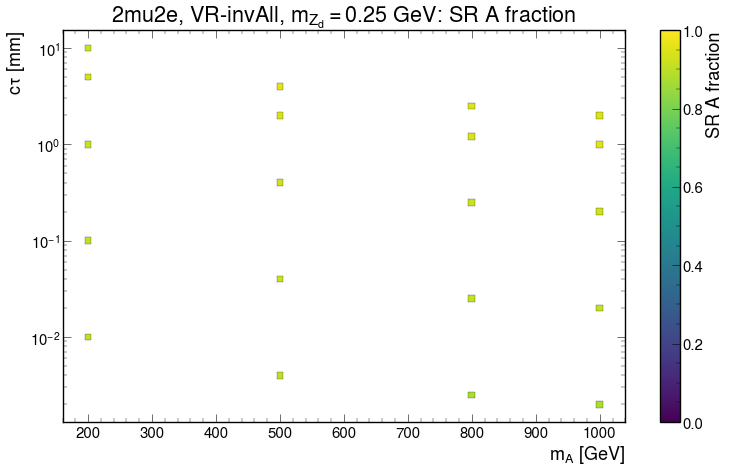

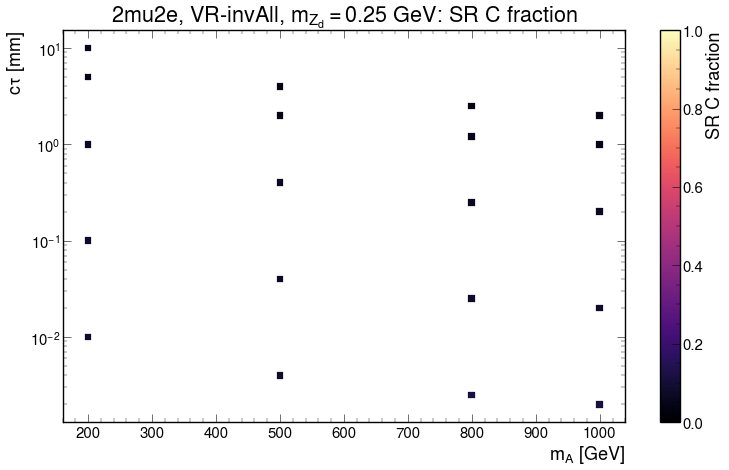

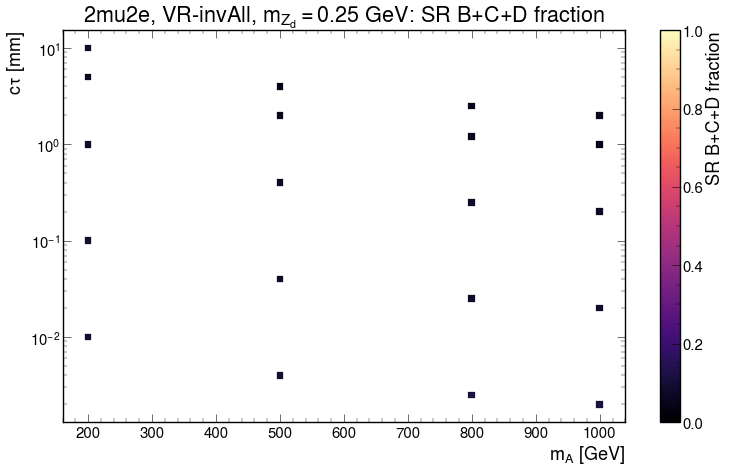

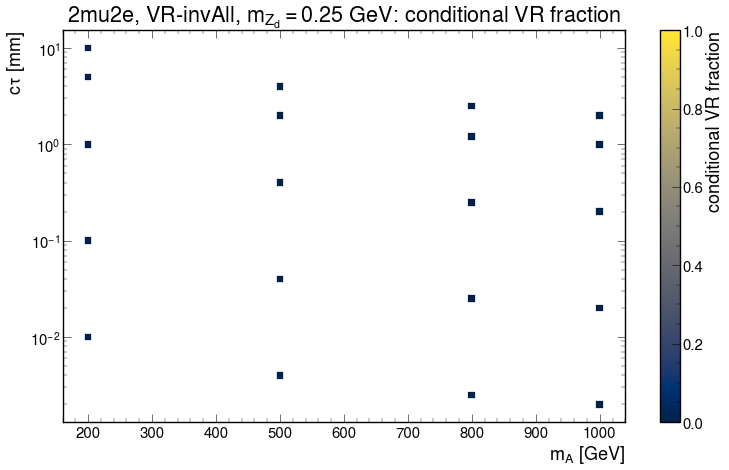

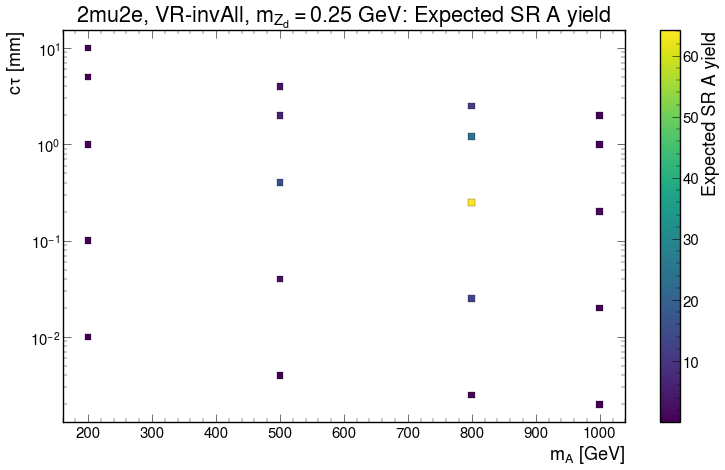

...

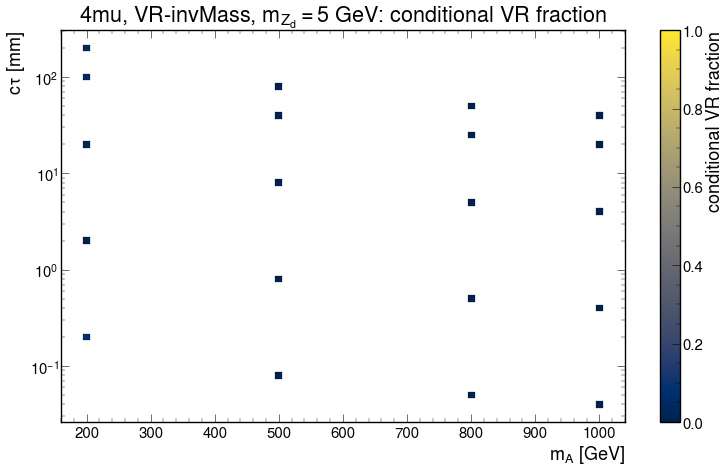

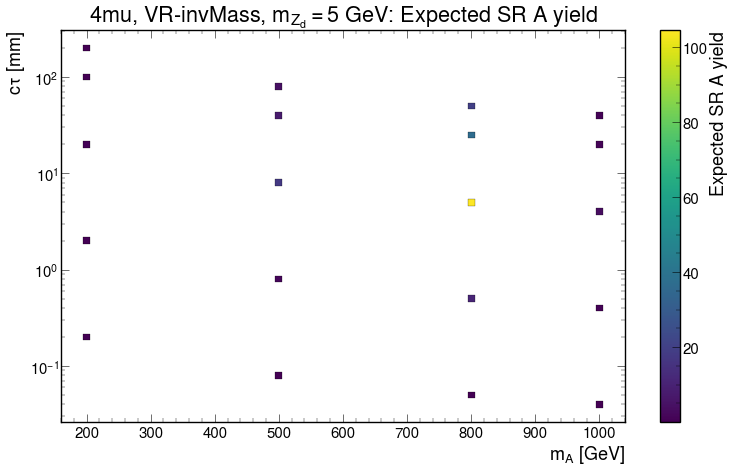

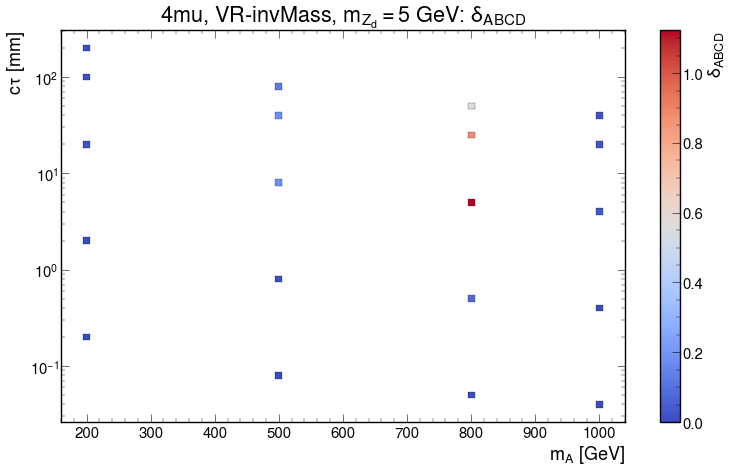

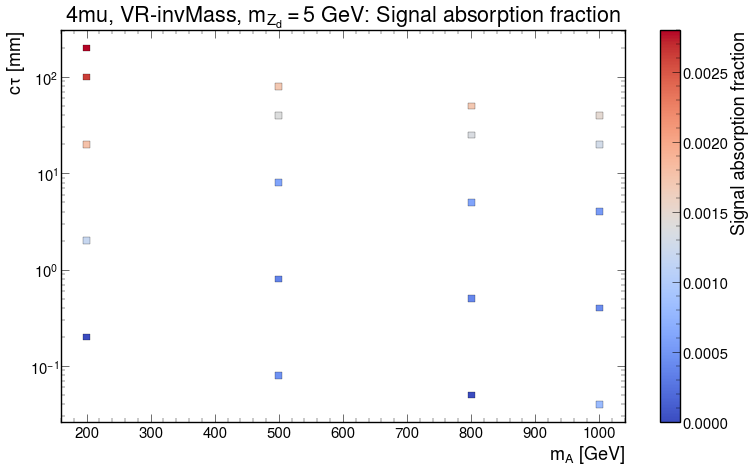

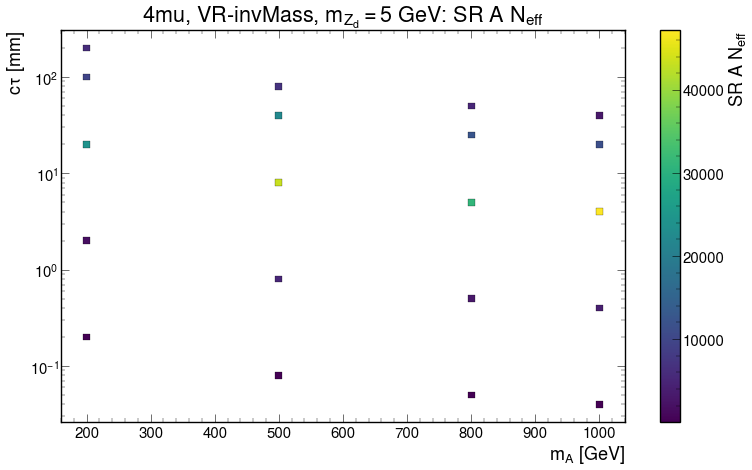

In [18]:
def plot_signal_parameter_map(frame, value, label, cmap="viridis", vmin=None, vmax=None):
    finite = frame[np.isfinite(frame[value]) & (frame.ctau_mm > 0)].copy()
    if finite.empty:
        return None
    fig, ax = plt.subplots(figsize=(16, 10))
    points = ax.scatter(finite.mA_GeV, finite.ctau_mm, c=finite[value],
                        s=95, marker="s", cmap=cmap, vmin=vmin, vmax=vmax,
                        edgecolor="black", linewidth=0.35)
    ax.set_yscale("log")
    ax.set(xlabel=r"$m_A$ [GeV]", ylabel=r"$c\tau$ [mm]",
           title=f"{finite.topology.iloc[0]}, {finite.validation_selection.iloc[0]}, $m_{{Z_d}}={finite.mZd_GeV.iloc[0]:g}$ GeV: {label}")
    fig.colorbar(points, ax=ax, label=label)
    fig.tight_layout()
    return fig, ax

SIGNAL_PARAMETER_MAPS = [
    ("SR_A_fraction", "SR A fraction", "viridis", 0, 1),
    ("SR_C_fraction", "SR C fraction", "magma", 0, 1),
    ("SR_ABCD_CR_leakage", "SR B+C+D fraction", "magma", 0, 1),
    ("conditional_VR_fraction", "conditional VR fraction", "cividis", 0, 1),
    ("SR_A_expected_yield", "Expected SR A yield", "viridis", None, None),
    ("delta_ABCD", r"$\delta_{ABCD}$", "coolwarm", None, None),
    ("signal_absorption_fraction", "Signal absorption fraction", "coolwarm", None, None),
    ("SR_A_neff", r"SR A $N_{eff}$", "viridis", None, None),
]
for (_, _, _), frame in signal_summary.groupby(["topology", "validation_selection", "mZd_GeV"]):
    for value, label, cmap, vmin, vmax in SIGNAL_PARAMETER_MAPS:
        if plot_signal_parameter_map(frame, value, label, cmap, vmin, vmax) is not None:
            plt.show()
            plt.close()


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,xcut,ycut,SR_A_fraction,SR_ABCD_CR_leakage,SR_A_expected_yield,S_over_sqrt_Bpred,delta_ABCD,signal_absorption_fraction,SR_A_neff,SR_B_neff,SR_C_neff,SR_D_neff,low_stat_flag
0,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.05,0.05,0.753472,0.246528,0.022747,0.064278,0.001934,0.010646,217.0,10.0,60.0,1.0,True
1,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.05,0.10,0.791667,0.208333,0.023900,0.035751,0.001542,0.028827,228.0,10.0,49.0,1.0,True
2,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.05,0.15,0.819444,0.180556,0.024739,0.149635,0.035034,0.038707,236.0,10.0,41.0,1.0,True
3,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.05,0.20,0.829861,0.170139,0.025053,0.171937,0.042592,0.036096,239.0,11.0,38.0,NaN,True
4,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.05,0.25,0.843750,0.156250,0.025473,0.161494,0.038108,0.037220,243.0,11.0,34.0,NaN,True


Signal WP scan rows: 7680


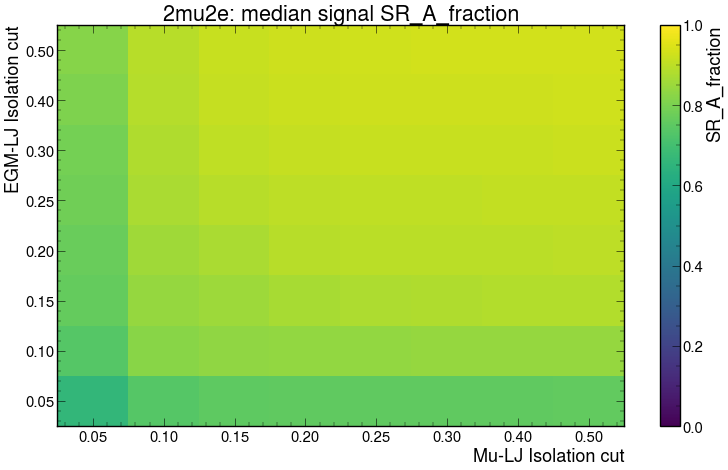

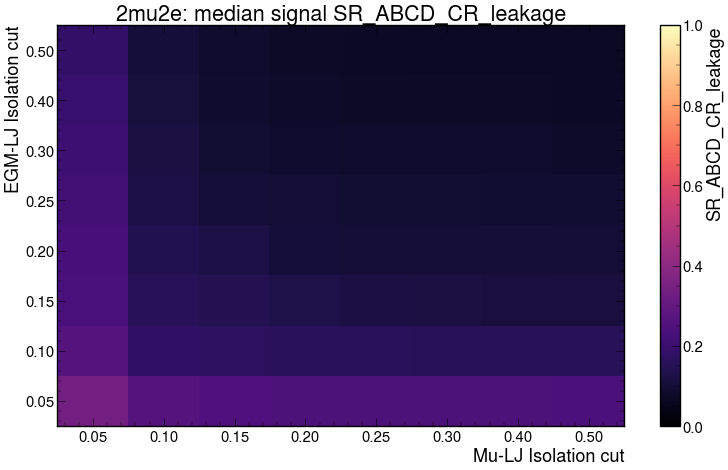

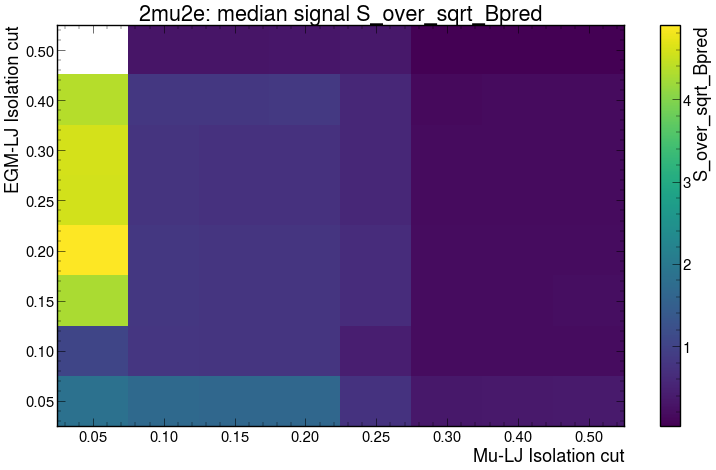

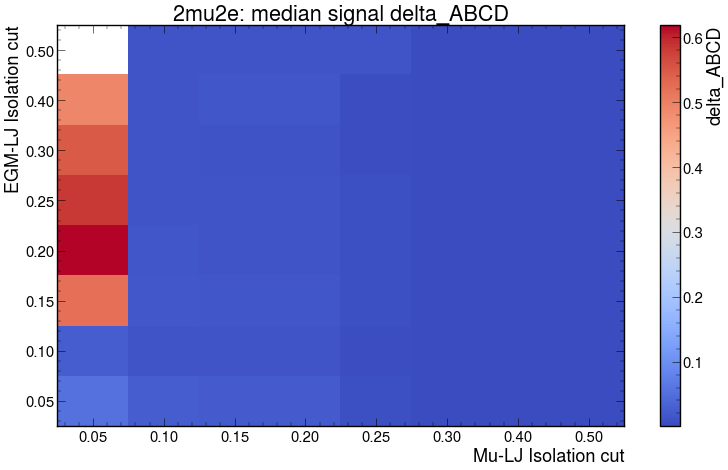

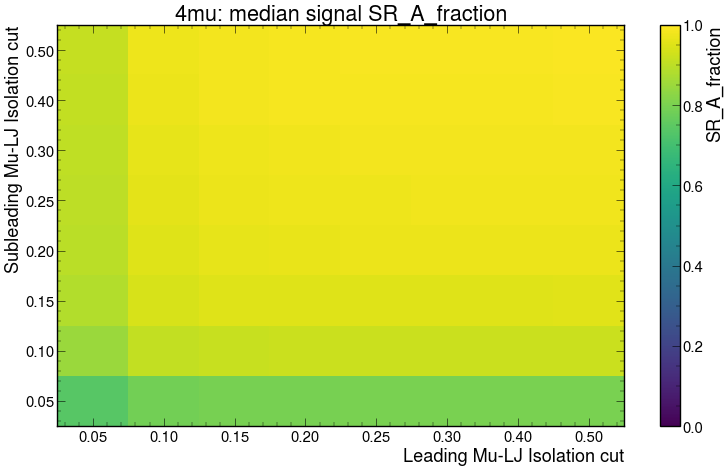

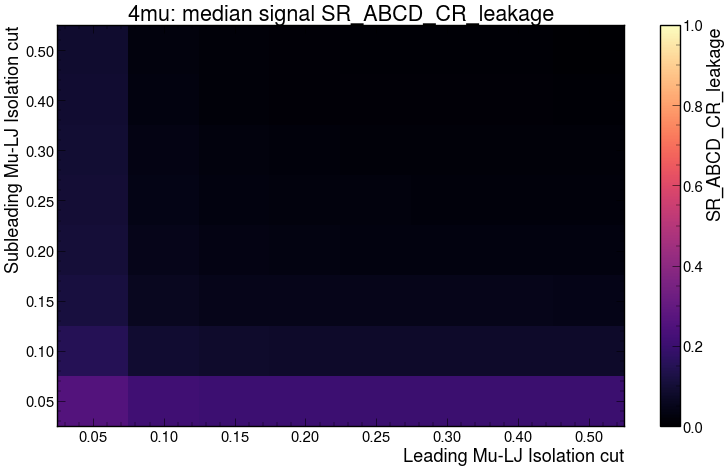

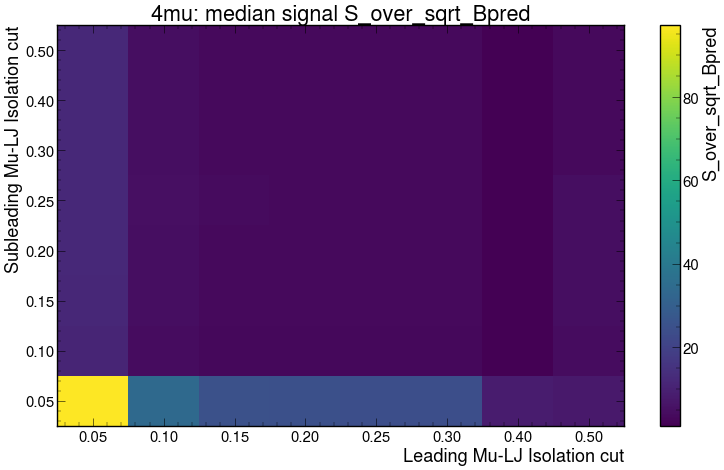

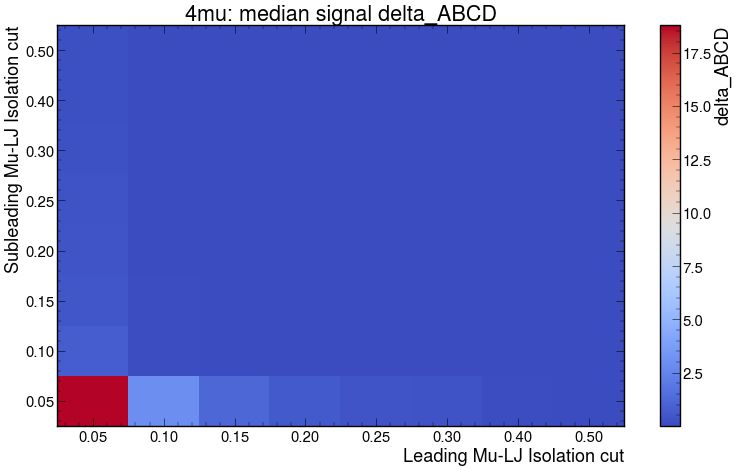

In [19]:
def signal_working_point_row(sample, parameters, signal_hist, bkg_hist, xcut, ycut):
    cuts = (xcut, ycut)
    sig = region_weight_stats(signal_hist, cuts)
    bkg = abcd_yields(bkg_hist, cuts)
    sigvals = {r: sig[r]["yield"] for r in "ABCD"}
    total = sum(sigvals.values())
    pred_b, _ = prediction(bkg)
    combined = {
        r: (
            bkg[r][0] + sigvals[r],
            np.sqrt(bkg[r][1]**2 + sig[r]["variance"]),
        )
        for r in "ABCD"
    }
    pred_bs, _ = prediction(combined)
    shift = pred_bs - pred_b
    row = {"signal": sample, **parameters, "xcut": xcut, "ycut": ycut,
           "SR_A_fraction": safe_ratio(sigvals["A"], total),
           "SR_ABCD_CR_leakage": safe_ratio(sum(sigvals[r] for r in "BCD"), total),
           "SR_A_expected_yield": sigvals["A"],
           "S_over_sqrt_Bpred": (
               sigvals["A"] / np.sqrt(pred_b)
               if np.isfinite(pred_b) and pred_b > 0 else np.nan),
           "delta_ABCD": shift / pred_b if np.isfinite(shift) and pred_b > 0 else np.nan,
           "signal_absorption_fraction": (
               shift / sigvals["A"]
               if np.isfinite(shift) and sigvals["A"] > 0 else np.nan)}
    for region in "ABCD":
        row[f"SR_{region}_neff"] = sig[region]["neff"]
    row["low_stat_flag"] = any(
        not np.isfinite(sig[r]["neff"]) or sig[r]["neff"] < SIGNAL_LOW_STAT_NEFF
        for r in "ABCD")
    return row

signal_wp_rows = []
for sample in sample_groups.get("Signal", []):
    pars = parse_signal_point(sample)
    topology = pars["topology"]
    sh = group_hist(sample, topology, "SR")
    bh = group_hist("BKG total", topology, "SR")
    if sh is None or bh is None:
        continue
    for xcut in SCAN_VALUES:
        for ycut in SCAN_VALUES:
            signal_wp_rows.append(signal_working_point_row(
                sample, pars, sh, bh, xcut, ycut))
signal_wp_scan = pd.DataFrame(signal_wp_rows)
display(signal_wp_scan.head())
print(f"Signal WP scan rows: {len(signal_wp_scan)}")

def plot_signal_wp_median(frame, value, topology, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot_table(index="ycut", columns="xcut", values=value, aggfunc="median")
    fig, ax = plt.subplots(figsize=(16, 10))
    image = ax.imshow(table.values, origin="lower", aspect="auto",
                      cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    cfg = CHANNEL_CONFIGS[topology]
    ax.set(xlabel=f"{cfg['x_label']} cut", ylabel=f"{cfg['y_label']} cut",
           title=f"{topology}: median signal {value}")
    fig.colorbar(image, ax=ax, label=value)
    fig.tight_layout()

if not signal_wp_scan.empty:
    for topology, frame in signal_wp_scan.groupby("topology"):
        for value, cmap, vmin, vmax in [
            ("SR_A_fraction", "viridis", 0, 1),
            ("SR_ABCD_CR_leakage", "magma", 0, 1),
            ("S_over_sqrt_Bpred", "viridis", None, None),
            ("delta_ABCD", "coolwarm", None, None)]:
            plot_signal_wp_median(frame, value, topology, cmap, vmin, vmax)
            plt.show()
            plt.close()


In [20]:
print("MC closure")
display(abcd_summary[abcd_summary.group == "BKG total"])
print("SR/VR MC transferability")
display(transfer_summary)
print("Signal leakage")
display(signal_summary)
print("MC-only ABCD analysis complete.")


MC closure


,topology,selection,group,A_pred,A_pred_err,kappa,kappa_err,pull,A,A_err,B,B_err,C,C_err,D,D_err
4,2mu2e,SR,BKG total,1.962007,1.865866,15.802071,16.539297,2.122839,31.003767,13.552784,36.868713,11.275693,12.143459,8.080562,228.191738,138.441819
9,2mu2e,VR-invDisplaced,BKG total,599.098679,242.558931,0.871446,0.468643,-0.252570,522.082398,184.791147,1431.711980,208.852501,1574.024265,572.361765,3761.566297,383.899652
14,2mu2e,VR-invDPhi,BKG total,18.837168,20.943663,0.801083,1.046908,-0.160349,15.090142,10.364402,17.068156,7.630986,11.274547,8.042201,10.215746,7.419362
19,2mu2e,VR-invMass,BKG total,1.266663,1.526791,5.831961,7.935224,1.247406,7.387132,4.662963,14.216778,7.593357,3.253182,3.248042,36.513059,15.089462
24,2mu2e,VR-invAll,BKG total,307.839249,104.027035,0.837145,0.483165,-0.314809,257.706110,120.576921,742.061653,85.493058,389.211576,106.344714,938.213650,152.053373
29,4mu,SR,BKG total,0.056859,0.065860,57.170099,87.455540,0.983084,3.250611,3.248041,0.741834,0.660070,1.666524,0.939519,21.743142,10.476439
34,4mu,VR-invDisplaced,BKG total,30.152731,11.959003,4.180947,1.793683,4.023948,126.066956,20.618683,84.542744,22.788358,990.876541,261.927837,2778.236651,337.657849
39,4mu,VR-invDPhi,BKG total,0.020781,0.024247,0.247433,0.337577,-0.637866,0.005142,0.003636,0.851819,0.671900,0.005142,0.003636,0.210768,0.103080
44,4mu,VR-invMass,BKG total,0.000000,0.000000,NaN,NaN,1.000000,0.002571,0.002571,3.277035,3.273657,0.000000,0.000000,18.657505,10.431444
49,4mu,VR-invAll,BKG total,41.639654,33.183603,3.108924,3.033048,1.096956,129.454509,72.851652,174.445391,119.561910,192.827749,75.128286,807.833622,93.993520


SR/VR MC transferability


,topology,validation_selection,kappa_SR_MC,kappa_SR_MC_err,kappa_VR_MC,kappa_VR_MC_err,R_kappa_SR_over_VR,R_kappa_err
0,2mu2e,VR-invDisplaced,15.802071,16.539297,0.871446,0.468643,18.133152,21.337774
1,2mu2e,VR-invDPhi,15.802071,16.539297,0.801083,1.046908,19.725876,33.027628
2,2mu2e,VR-invMass,15.802071,16.539297,5.831961,7.935224,2.709564,4.651333
3,2mu2e,VR-invAll,15.802071,16.539297,0.837145,0.483165,18.876144,22.561494
4,4mu,VR-invDisplaced,57.170099,87.455540,4.180947,1.793683,13.673961,21.724672
5,4mu,VR-invDPhi,57.170099,87.455540,0.247433,0.337577,231.052982,473.601003
6,4mu,VR-invMass,57.170099,87.455540,NaN,NaN,NaN,NaN
7,4mu,VR-invAll,57.170099,87.455540,3.108924,3.033048,18.389032,33.364295


Signal leakage


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,validation_selection,SR_2D_expected_yield,VR_2D_expected_yield,conditional_VR_fraction,VR_neff,...,SR_D_variance,SR_D_neff,SR_D_over_BkgMC,SR_ABCD_CR_leakage,A_pred_bkg,A_pred_bkg_plus_signal,delta_ABCD,signal_absorption_fraction,low_stat_regions,low_stat_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,0.010354,0.000038,0.003663,1.0,...,0.000000e+00,NaN,0.000000e+00,0.095588,1.962007,1.962158,0.000077,0.016196,"B,D",True
1,2Mu2E_200GeV_0p25GeV_0p1mm,2mu2e,200.0,0.25,0.10,VR-invAll,0.121708,0.000133,0.001093,4.0,...,1.109438e-09,1.0,1.459660e-07,0.093596,1.962007,1.963787,0.000908,0.016142,D,True
2,2Mu2E_200GeV_0p25GeV_1p0mm,2mu2e,200.0,0.25,1.00,VR-invAll,0.623979,0.000066,0.000106,1.0,...,3.512405e-08,8.0,2.322990e-06,0.082298,1.962007,1.969525,0.003832,0.013130,D,True
3,2Mu2E_200GeV_0p25GeV_5p0mm,2mu2e,200.0,0.25,5.00,VR-invAll,0.253257,0.000024,0.000095,1.0,...,2.919365e-09,5.0,5.294553e-07,0.063734,1.962007,1.964065,0.001049,0.008682,D,True
4,2Mu2E_200GeV_0p25GeV_10p0mm,2mu2e,200.0,0.25,10.00,VR-invAll,0.130288,0.000000,0.000000,NaN,...,1.281158e-07,4.0,3.137123e-06,0.078297,1.962007,1.963048,0.000531,0.008674,D,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,4Mu_1000GeV_5p0GeV_0p04mm,4mu,1000.0,5.00,0.04,VR-invMass,0.008311,0.000000,0.000000,NaN,...,0.000000e+00,NaN,0.000000e+00,0.022989,0.056859,0.056865,0.000115,0.000803,"B,C,D",True
476,4Mu_1000GeV_5p0GeV_0p4mm,4mu,1000.0,5.00,0.40,VR-invMass,0.415264,0.000000,0.000000,NaN,...,0.000000e+00,NaN,0.000000e+00,0.011064,0.056859,0.057038,0.003149,0.000436,"B,D",True
477,4Mu_1000GeV_5p0GeV_4p0mm,4mu,1000.0,5.00,4.00,VR-invMass,3.619042,0.000378,0.000104,5.0,...,2.285754e-08,4.0,1.390665e-05,0.013974,0.056859,0.058769,0.033592,0.000535,D,True
478,4Mu_1000GeV_5p0GeV_20p0mm,4mu,1000.0,5.00,20.00,VR-invMass,1.127204,0.000765,0.000678,8.0,...,3.659367e-08,4.0,1.759587e-05,0.031905,0.056859,0.058257,0.024587,0.001281,D,True


MC-only ABCD analysis complete.


In [21]:
CONTAMINATION_METRICS = ("S_over_B_MC", "S_over_SplusB_MC")
contamination_rows = []
for sample in sample_groups.get("Signal", []):
    parameters = parse_signal_point(sample)
    topology = parameters["topology"]
    cuts = CHANNEL_CONFIGS[topology]["cuts"]
    for selection in SELECTIONS:
        signal_hist = group_hist(sample, topology, selection)
        bkg_hist = group_hist("BKG total", topology, selection)
        if signal_hist is None or bkg_hist is None:
            continue
        signal_stats = region_weight_stats(signal_hist, cuts)
        bkg_stats = region_weight_stats(bkg_hist, cuts)
        for region in "ABCD":
            signal_yield = signal_stats[region]["yield"]
            background_yield = bkg_stats[region]["yield"]
            contamination_rows.append({
                "signal": sample, **parameters, "selection": selection, "region": region,
                "signal_yield": signal_yield,
                "signal_variance": signal_stats[region]["variance"],
                "signal_neff": signal_stats[region]["neff"],
                "background_mc_yield": background_yield,
                "background_mc_variance": bkg_stats[region]["variance"],
                "background_mc_neff": bkg_stats[region]["neff"],
                "S_over_B_MC": safe_ratio(signal_yield, background_yield),
                "S_over_SplusB_MC": safe_ratio(
                    signal_yield, signal_yield + background_yield),
                "small_background_flag": (
                    not np.isfinite(background_yield) or background_yield <= 0
                    or not np.isfinite(bkg_stats[region]["neff"])
                    or bkg_stats[region]["neff"] < SIGNAL_LOW_STAT_NEFF),
            })

control_contamination = pd.DataFrame(contamination_rows).sort_values(
    ["topology", "mZd_GeV", "mA_GeV", "ctau_mm", "selection", "region"]
).reset_index(drop=True)
vr_contamination = control_contamination[
    control_contamination.selection.isin(VR_SELECTIONS)
].copy()
max_vr_contamination = (
    vr_contamination.groupby(
        ["signal", "topology", "mA_GeV", "mZd_GeV", "ctau_mm"],
        as_index=False,
    ).agg(
        max_VR_S_over_B_MC=("S_over_B_MC", "max"),
        max_VR_S_over_SplusB_MC=("S_over_SplusB_MC", "max"),
        any_small_background=("small_background_flag", "any"),
    )
)
display(control_contamination.head(12))
display(max_vr_contamination)
print(f"Contamination rows: {len(control_contamination):,}")


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,selection,region,signal_yield,signal_variance,signal_neff,background_mc_yield,background_mc_variance,background_mc_neff,S_over_B_MC,S_over_SplusB_MC,small_background_flag
0,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,A,0.009364,3.564773e-07,246.0,31.003767,183.677967,5.233255,3.020432e-04,3.019520e-04,True
1,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,B,0.000076,2.898190e-09,2.0,36.868713,127.141241,10.691275,2.065002e-06,2.064997e-06,False
2,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,C,0.000914,3.477828e-08,24.0,12.143459,65.295476,2.258404,7.523454e-05,7.522888e-05,True
3,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,SR,D,0.000000,0.000000e+00,NaN,228.191738,19166.137155,2.716847,0.000000e+00,0.000000e+00,True
4,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,A,0.000000,0.000000e+00,NaN,257.706110,14538.793890,4.567947,0.000000e+00,0.000000e+00,True
5,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,B,0.000000,0.000000e+00,NaN,742.061653,7309.062948,75.338727,0.000000e+00,0.000000e+00,False
6,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,C,0.000038,1.449095e-09,1.0,389.211576,11309.198148,13.394906,9.780536e-08,9.780535e-08,False
7,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invAll,D,0.000000,0.000000e+00,NaN,938.213650,23120.228208,38.072498,0.000000e+00,0.000000e+00,False
8,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invDPhi,A,0.000114,4.347285e-09,3.0,15.090142,107.420821,2.119816,7.567917e-06,7.567859e-06,True
9,2Mu2E_200GeV_0p25GeV_0p01mm,2mu2e,200.0,0.25,0.01,VR-invDPhi,B,0.000000,0.000000e+00,NaN,17.068156,58.231944,5.002786,0.000000e+00,0.000000e+00,True


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,max_VR_S_over_B_MC,max_VR_S_over_SplusB_MC,any_small_background
0,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.007937,0.007875,True
1,2Mu2E_1000GeV_0p25GeV_0p02mm,2mu2e,1000.0,0.25,0.020,0.004382,0.004362,True
2,2Mu2E_1000GeV_0p25GeV_0p2mm,2mu2e,1000.0,0.25,0.200,0.000953,0.000952,True
3,2Mu2E_1000GeV_0p25GeV_1p0mm,2mu2e,1000.0,0.25,1.000,0.000524,0.000524,True
4,2Mu2E_1000GeV_0p25GeV_2p0mm,2mu2e,1000.0,0.25,2.000,0.000489,0.000489,True
...,...,...,...,...,...,...,...,...
115,4Mu_800GeV_5p0GeV_0p05mm,4mu,800.0,5.00,0.050,2.724226,0.731488,True
116,4Mu_800GeV_5p0GeV_0p5mm,4mu,800.0,5.00,0.500,9.880925,0.908096,True
117,4Mu_800GeV_5p0GeV_25p0mm,4mu,800.0,5.00,25.000,56.921322,1.000000,True
118,4Mu_800GeV_5p0GeV_50p0mm,4mu,800.0,5.00,50.000,37.430892,1.000000,True


Contamination rows: 2,400


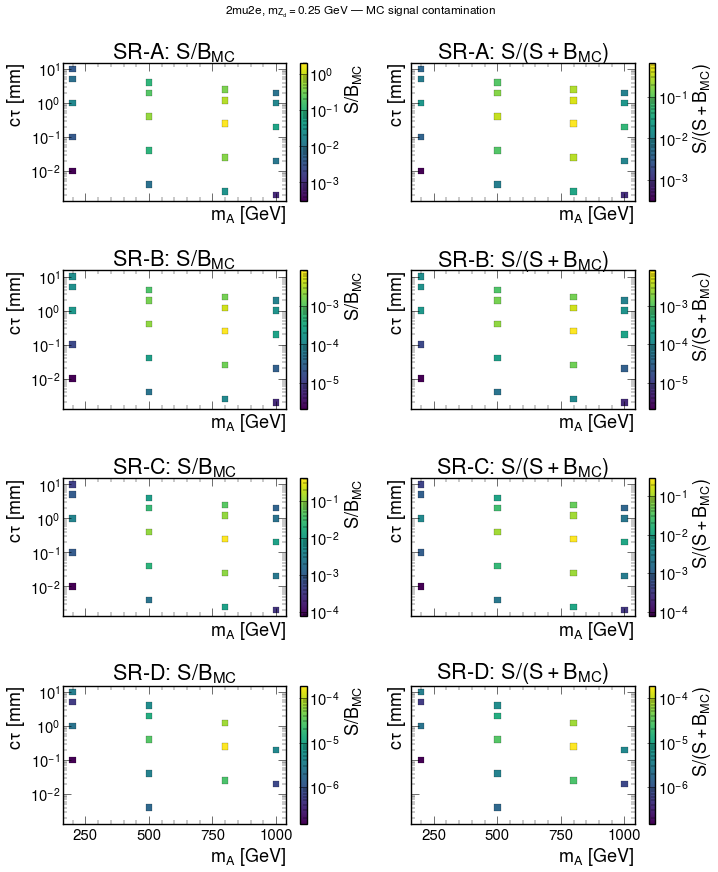

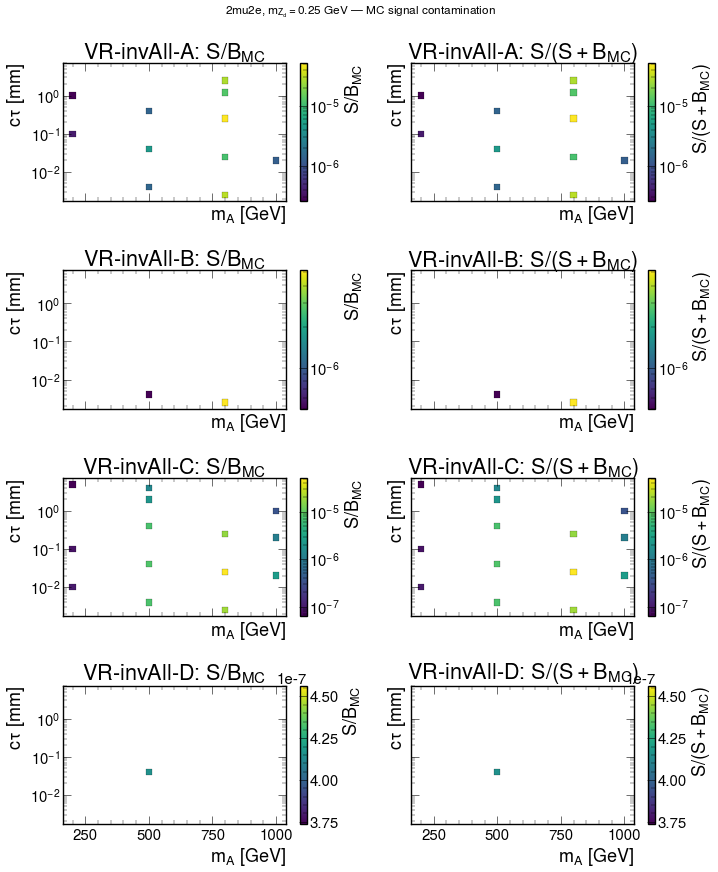

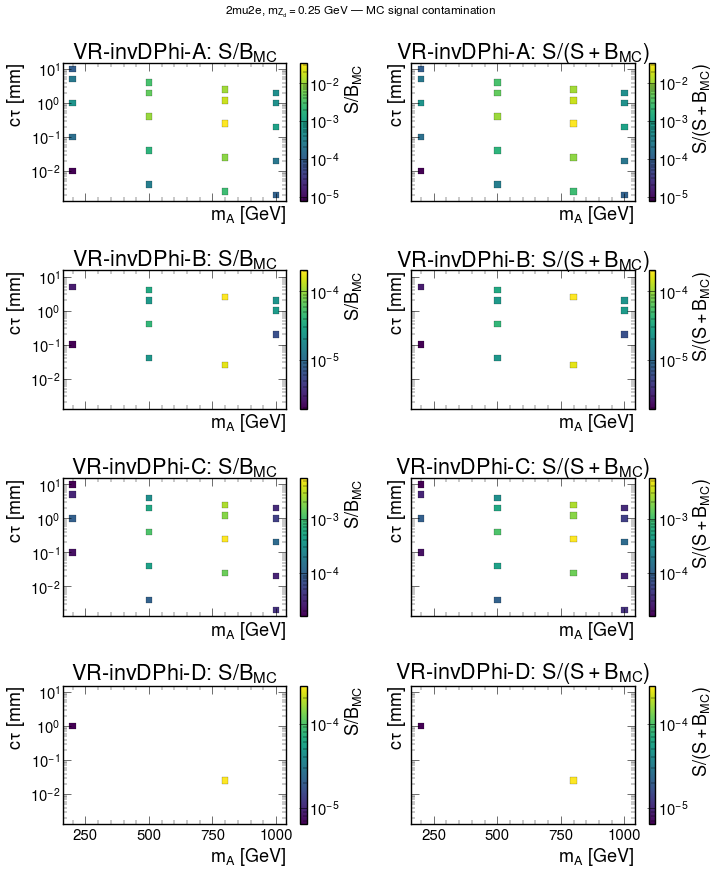

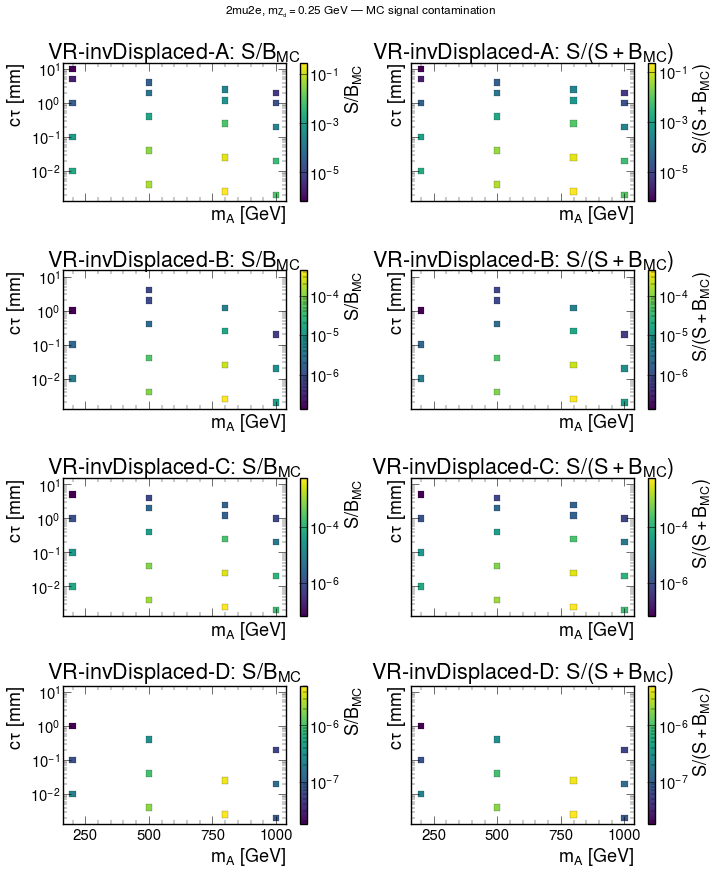

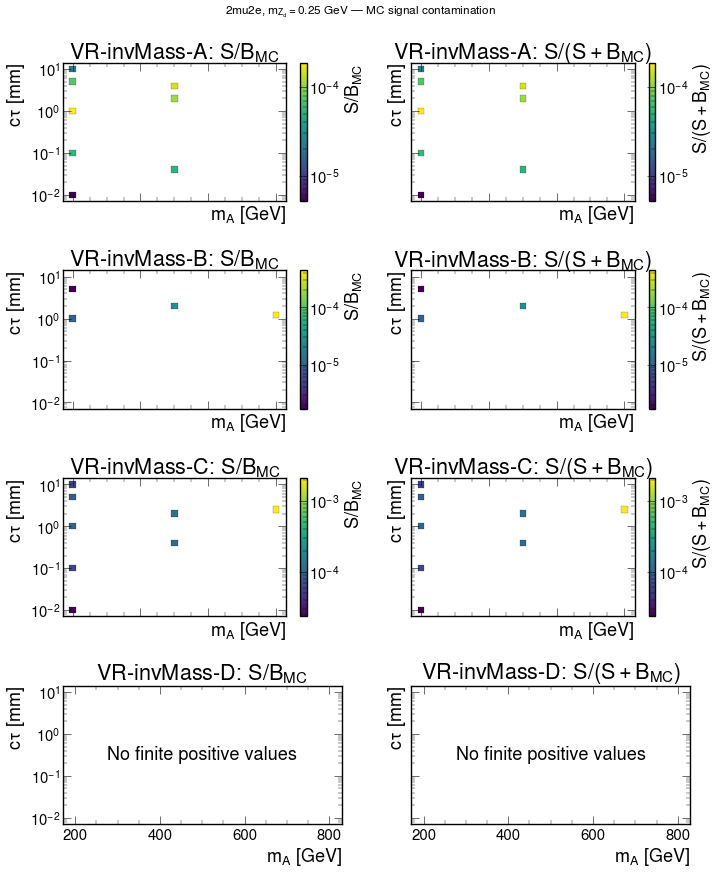

...

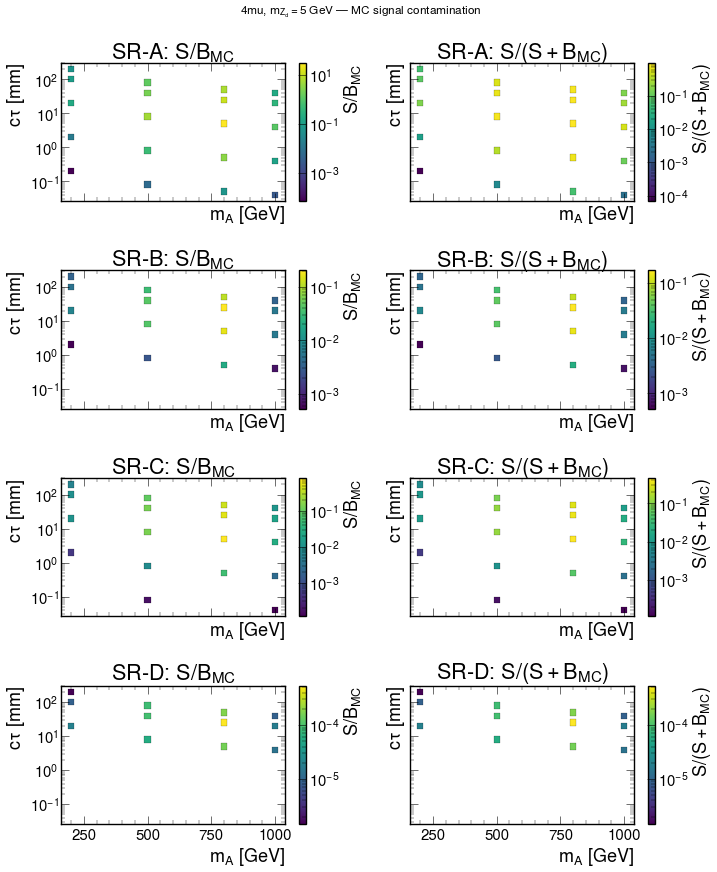

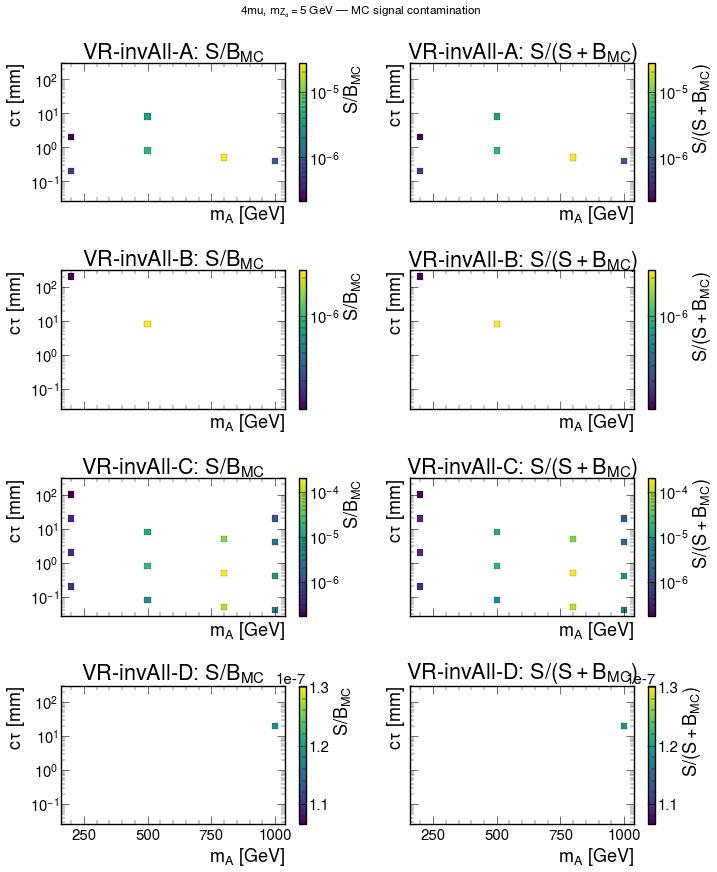

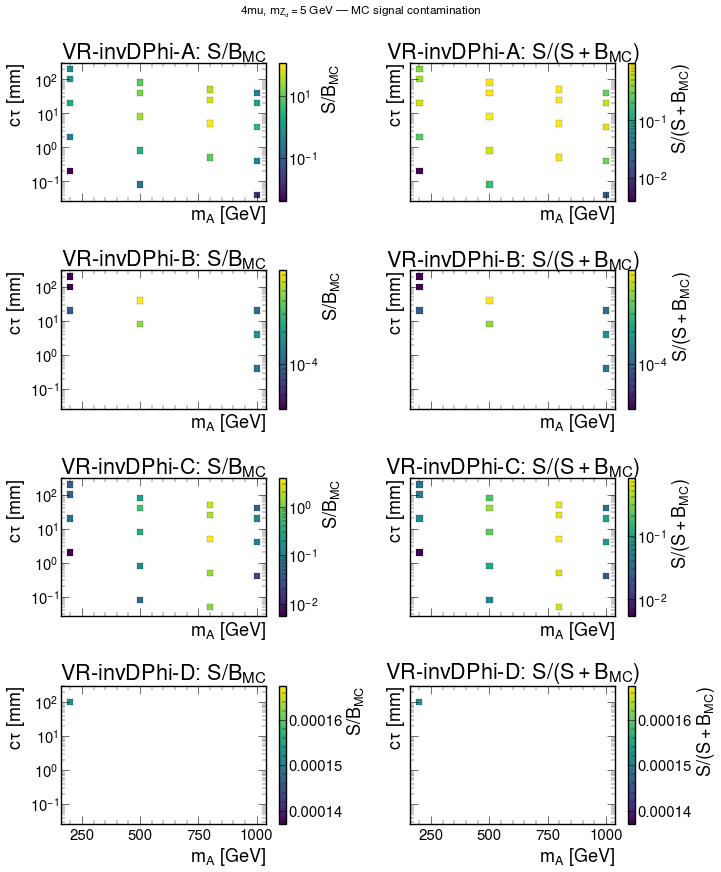

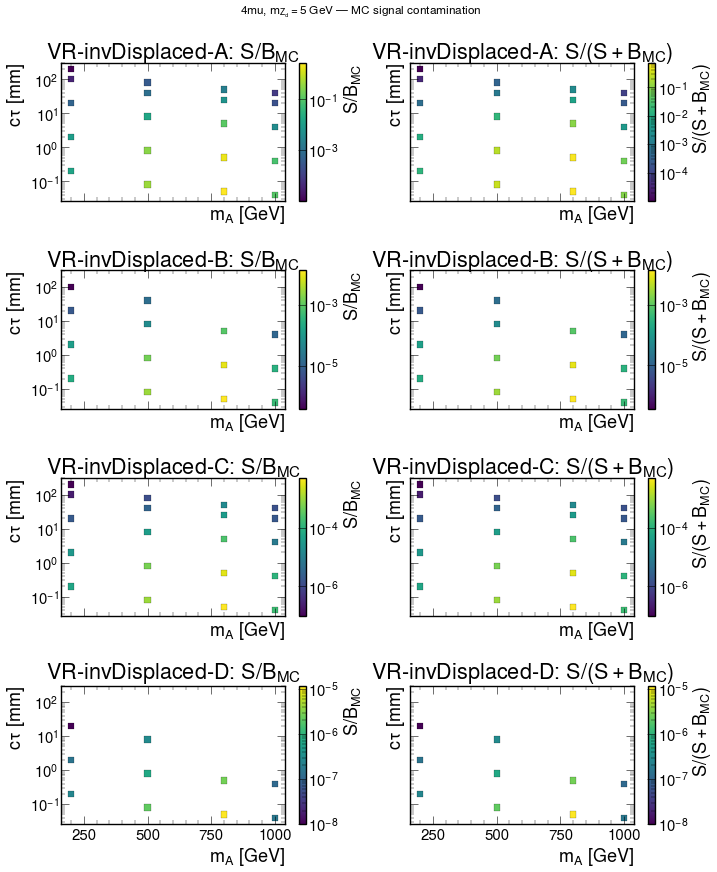

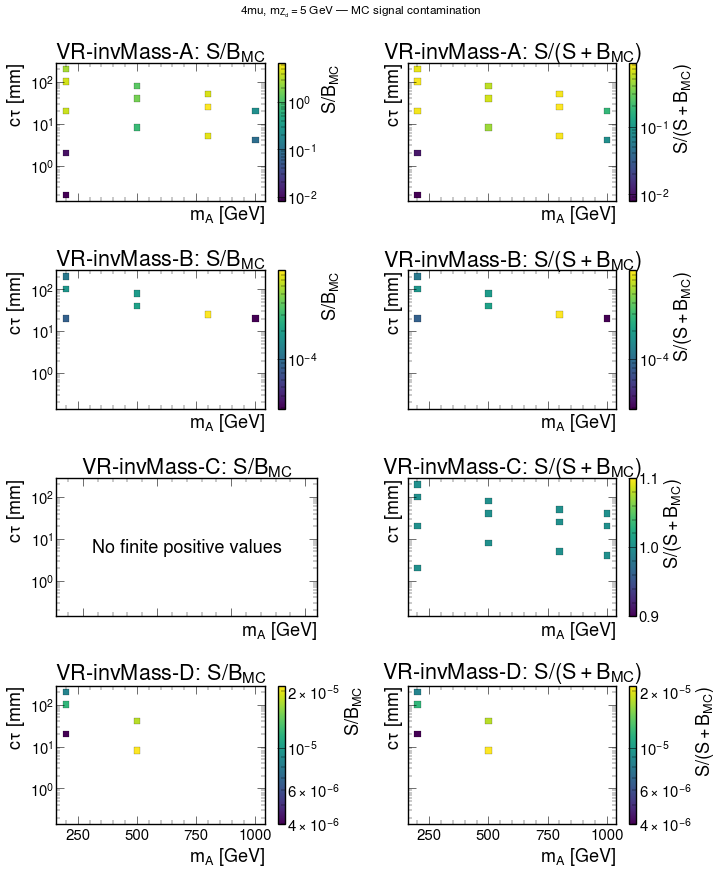

In [22]:
def plot_contamination_grid(frame, topology, mzd, selection):
    regions = tuple("ABCD")
    labels = {
        "S_over_B_MC": r"$S/B_{MC}$",
        "S_over_SplusB_MC": r"$S/(S+B_{MC})$",
    }
    fig, axes = plt.subplots(
        len(regions), len(CONTAMINATION_METRICS),
        figsize=(15, 4.5 * len(regions)), squeeze=False, sharex=True, sharey=True,
    )
    for row_index, region in enumerate(regions):
        region_frame = frame[frame.region == region]
        for column_index, metric in enumerate(CONTAMINATION_METRICS):
            ax = axes[row_index, column_index]
            finite = region_frame[
                np.isfinite(region_frame[metric]) & (region_frame[metric] > 0)
            ]
            if finite.empty:
                ax.text(0.5, 0.5, "No finite positive values",
                        ha="center", va="center", transform=ax.transAxes)
            else:
                values = finite[metric].to_numpy(float)
                norm = (LogNorm(vmin=max(values.min(), 1e-8), vmax=values.max())
                        if values.max() > values.min() else None)
                points = ax.scatter(
                    finite.mA_GeV, finite.ctau_mm, c=values, s=85, marker="s",
                    cmap="viridis", norm=norm, edgecolor="black", linewidth=0.25,
                )
                fig.colorbar(points, ax=ax, label=labels[metric])
            ax.set_yscale("log")
            ax.set(title=f"{selection}-{region}: {labels[metric]}",
                   xlabel=r"$m_A$ [GeV]", ylabel=r"$c\tau$ [mm]")
    fig.suptitle(
        f"{topology}, $m_{{Z_d}}={mzd:g}$ GeV — MC signal contamination",
        fontsize=17,
    )
    fig.tight_layout()
    return fig

for (topology, mzd, selection), frame in control_contamination.groupby(
    ["topology", "mZd_GeV", "selection"]
):
    plot_contamination_grid(frame, topology, mzd, selection)
    plt.show()
    plt.close()


In [23]:
contamination_summary = (
    control_contamination.groupby(["topology", "selection", "region"])
    .agg(
        points=("signal", "size"),
        nonzero_signal_points=("signal_yield", lambda values: (values > 0).sum()),
        median_S_over_B_MC=("S_over_B_MC", "median"),
        max_S_over_B_MC=("S_over_B_MC", "max"),
        small_background_points=("small_background_flag", "sum"),
    )
    .reset_index()
)
display(contamination_summary)

# Optional exports:
# control_contamination.to_csv("control_region_signal_contamination_mc_only.csv", index=False)
# max_vr_contamination.to_csv("max_vr_signal_contamination_mc_only.csv", index=False)


,topology,selection,region,points,nonzero_signal_points,median_S_over_B_MC,max_S_over_B_MC,small_background_points
0,2mu2e,SR,A,60,60,2.586542e-02,2.195366,60
1,2mu2e,SR,B,60,57,1.724067e-04,0.011184,0
2,2mu2e,SR,C,60,58,5.352153e-03,1.191046,60
3,2mu2e,SR,D,60,43,3.093630e-06,0.000290,60
4,2mu2e,VR-invAll,A,60,23,0.000000e+00,0.000052,60
5,2mu2e,VR-invAll,B,60,7,0.000000e+00,0.000005,0
6,2mu2e,VR-invAll,C,60,42,6.359471e-07,0.000085,0
7,2mu2e,VR-invAll,D,60,3,0.000000e+00,0.000006,0
8,2mu2e,VR-invDPhi,A,60,58,5.839442e-04,0.035436,60
9,2mu2e,VR-invDPhi,B,60,24,0.000000e+00,0.000239,60


Aggregated signal planes are normalized shape diagnostics; their summed yield is not a physical benchmark prediction.


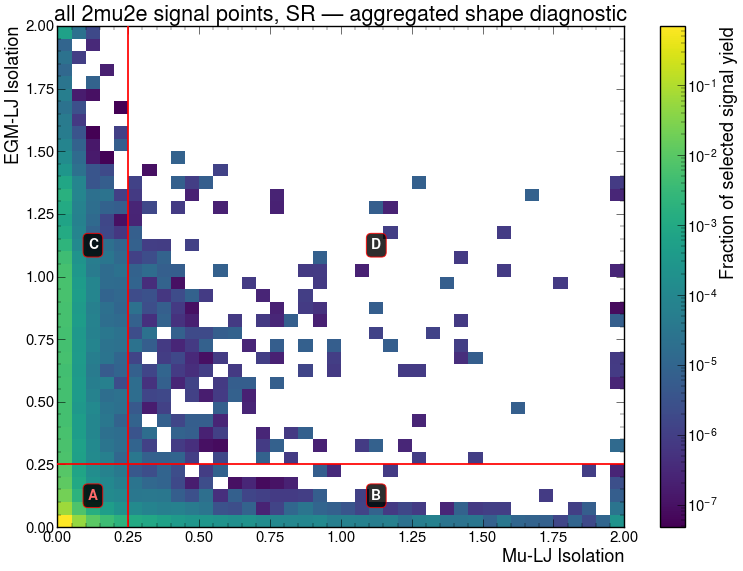

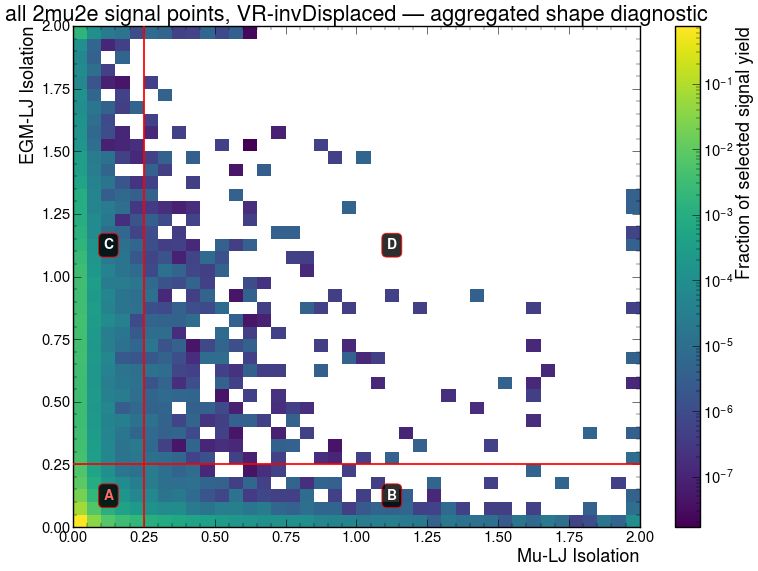

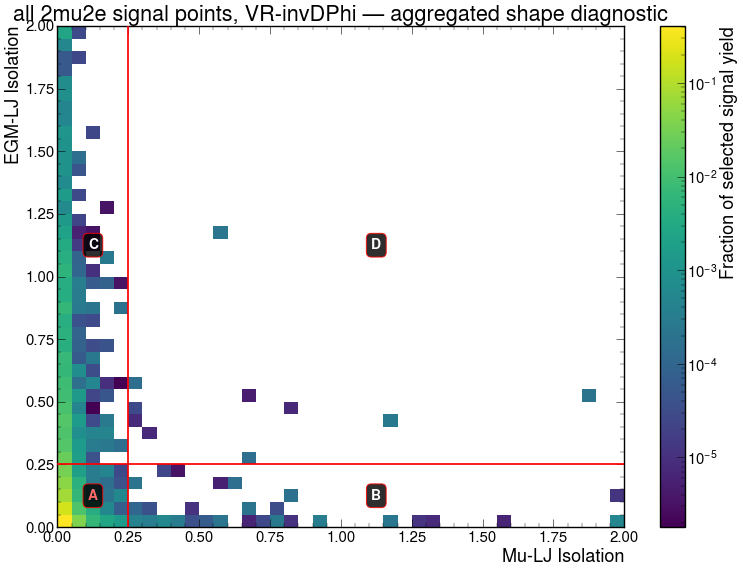

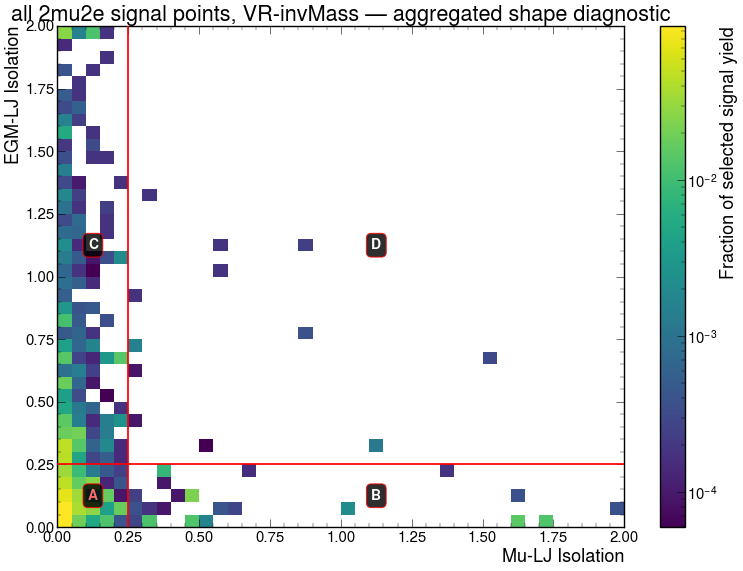

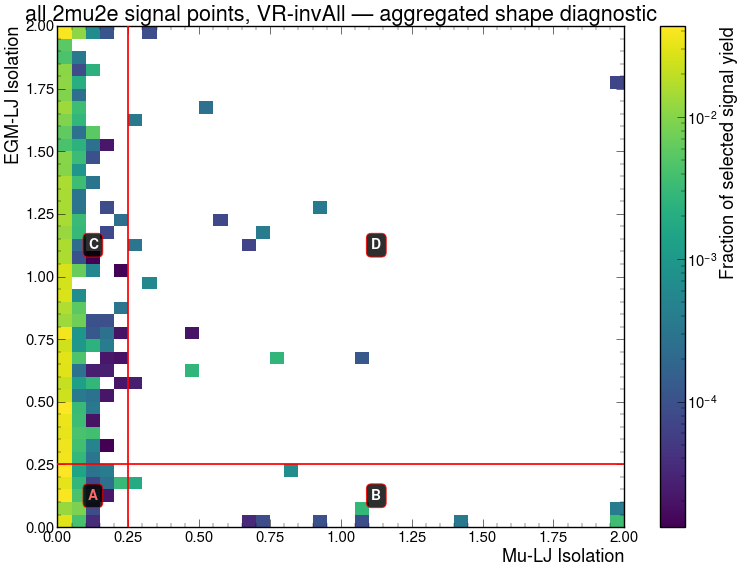

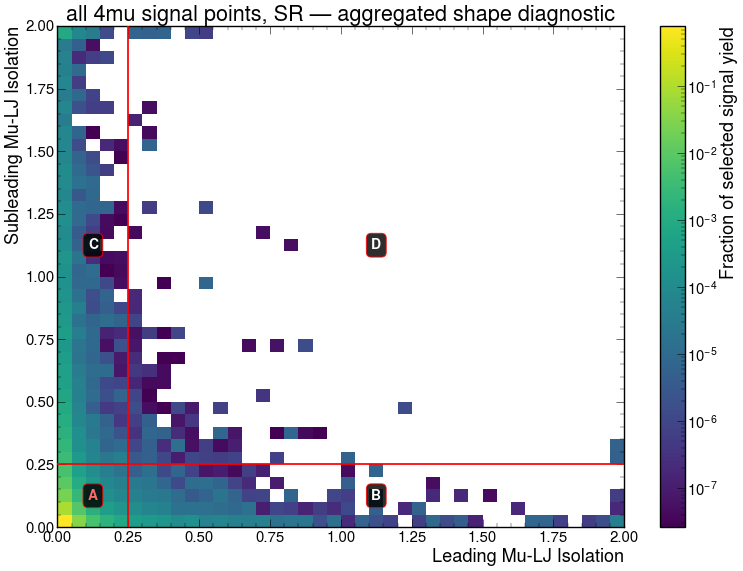

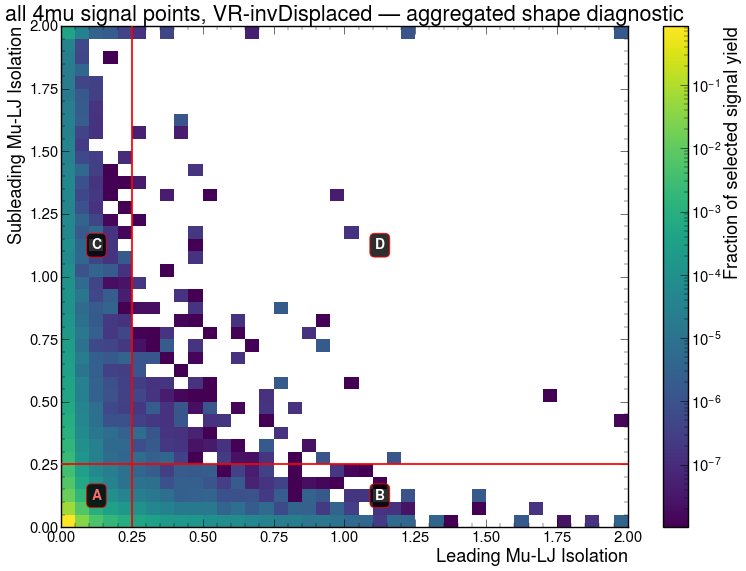

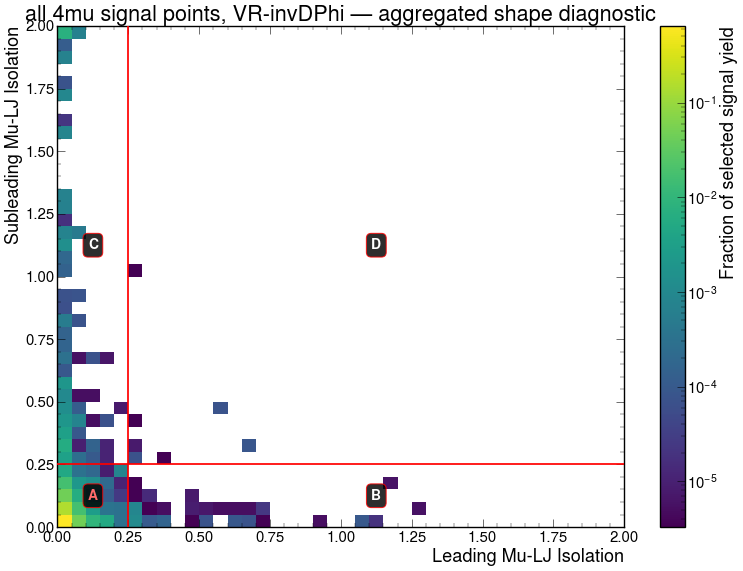

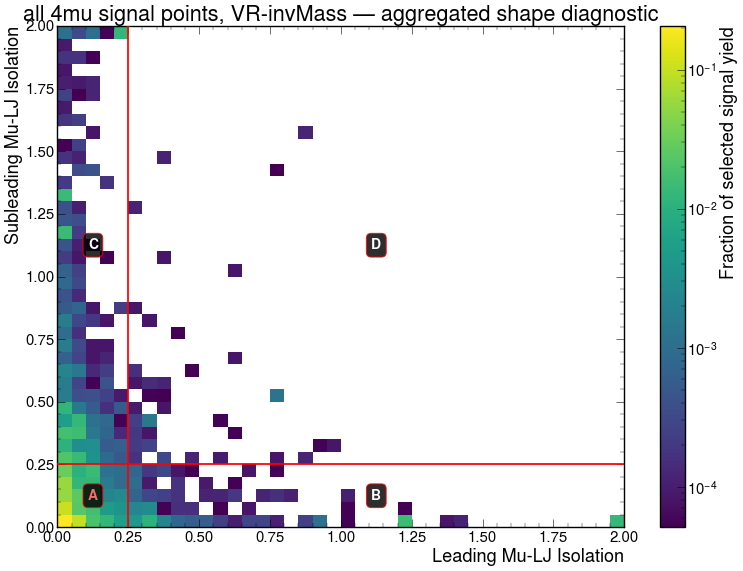

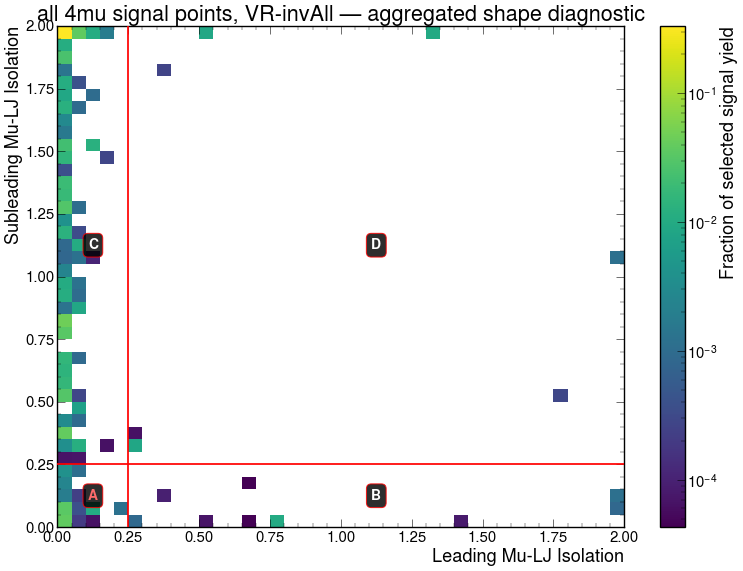

In [24]:
# Signal ABCD planes. Leave this empty for topology-wise aggregate shape plots.
# Add exact sample names to draw physically normalized individual benchmarks instead.
SIGNAL_PLANE_SAMPLES = []
SIGNAL_PLANE_SELECTIONS = SELECTIONS

if SIGNAL_PLANE_SAMPLES:
    signal_plane_targets = [
        (sample, parse_signal_point(sample)["topology"], sample, False)
        for sample in SIGNAL_PLANE_SAMPLES
    ]
else:
    signal_plane_targets = [
        ("Signal", topology, f"all {topology} signal points", True)
        for topology in CHANNEL_CONFIGS
    ]
    print(
        "Aggregated signal planes are normalized shape diagnostics; "
        "their summed yield is not a physical benchmark prediction."
    )

for target, topology, label, normalize_shape in signal_plane_targets:
    cfg = CHANNEL_CONFIGS[topology]
    for selection in SIGNAL_PLANE_SELECTIONS:
        plane = group_hist(target, topology, selection)
        if plane is None:
            continue
        shown_plane = plane
        colorbar_label = "Expected signal yield"
        title_suffix = ""
        if normalize_shape:
            visible_yield = values_variances(plane)[0].sum()
            if visible_yield <= 0:
                print(f"Skip empty plane: {label}, {selection}")
                continue
            shown_plane = plane * (1.0 / visible_yield)
            colorbar_label = "Fraction of selected signal yield"
            title_suffix = " — aggregated shape diagnostic"
        fig, ax = plot_abcd_plane(
            shown_plane, f"{label}, {selection}{title_suffix}", cfg, blind_a=False,
        )
        fig.axes[-1].set_ylabel(colorbar_label)
        plt.show()
        plt.close(fig)


CAUTION: these yields are summed over the full signal grid and do not represent a single physical benchmark. Set SIGNAL_PLANE_SAMPLES for benchmark-level expected yields.


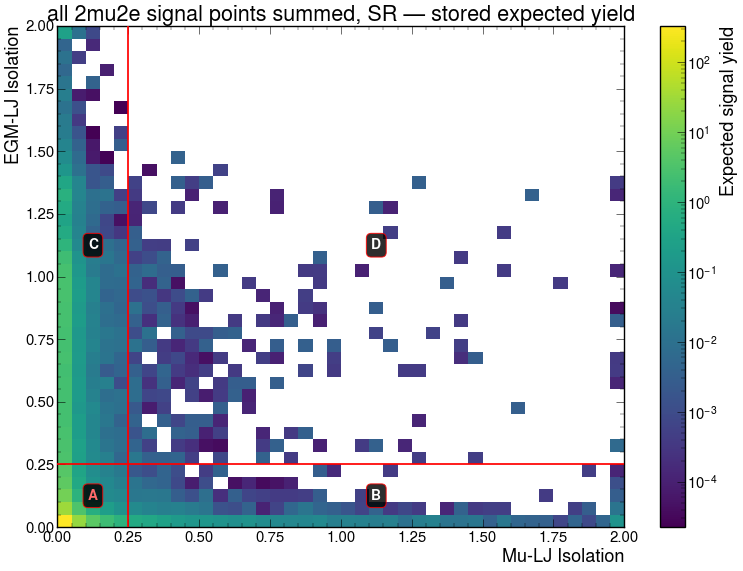

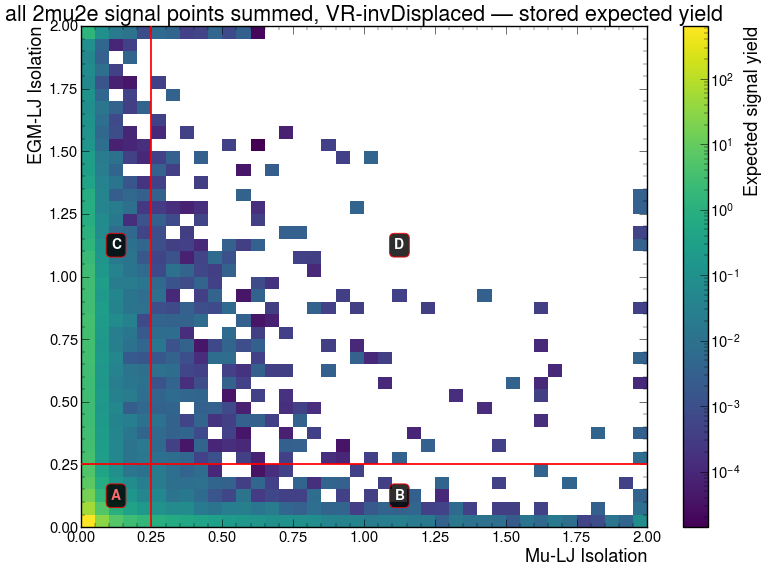

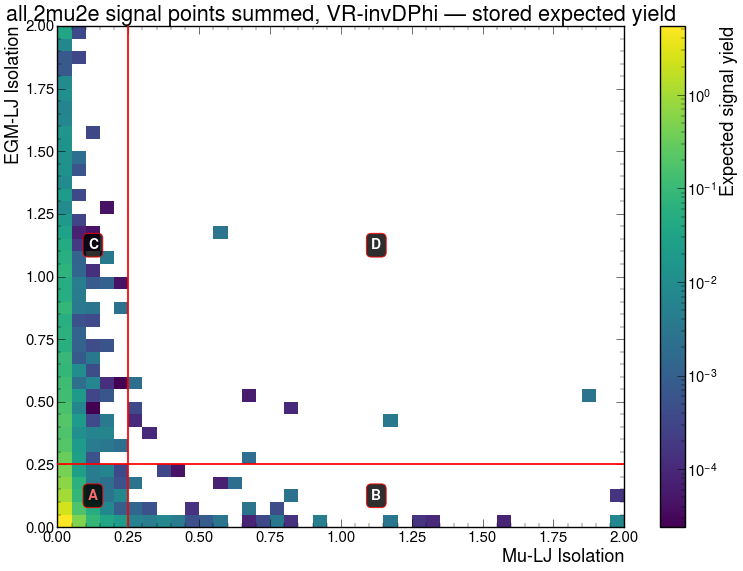

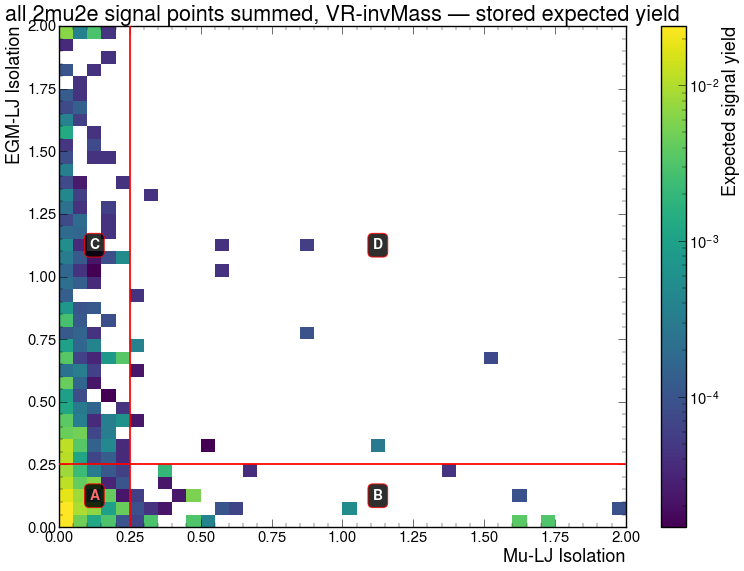

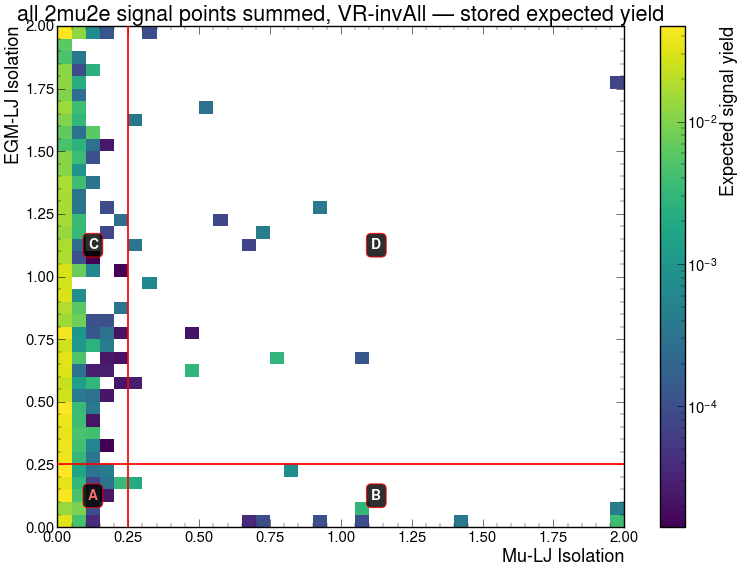

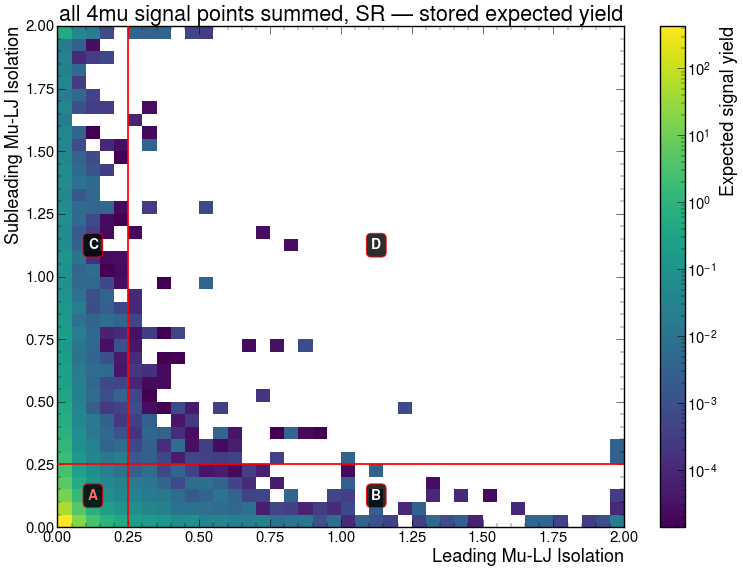

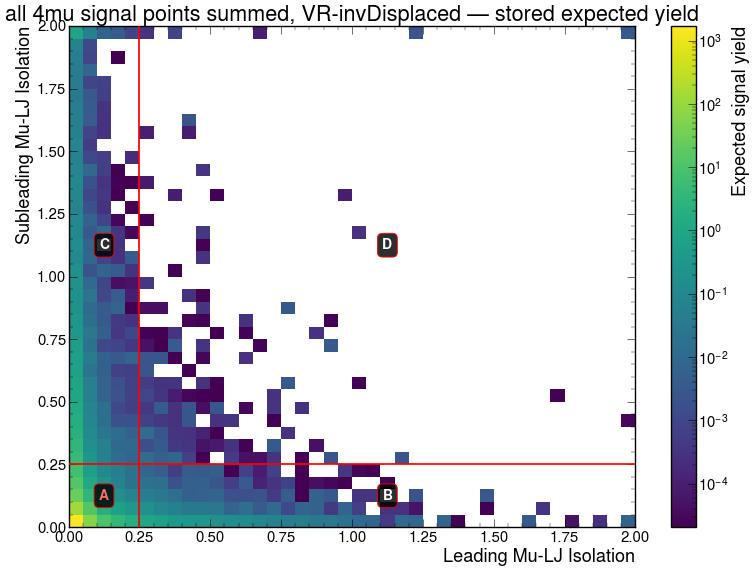

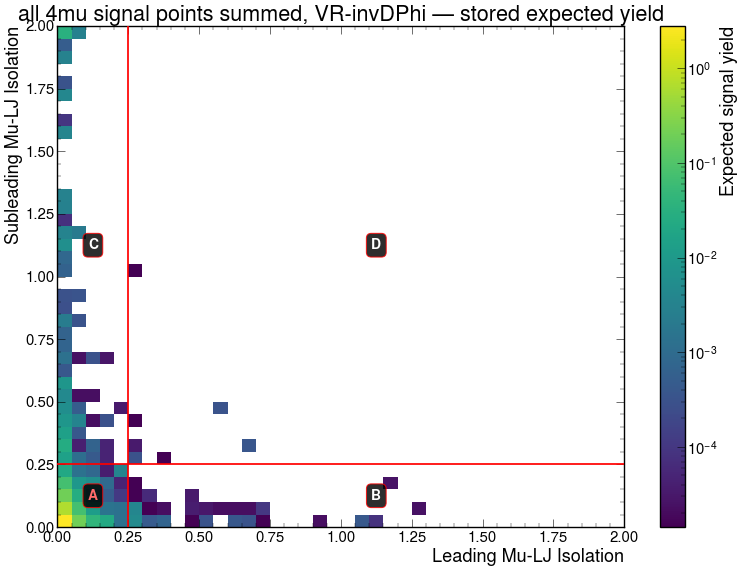

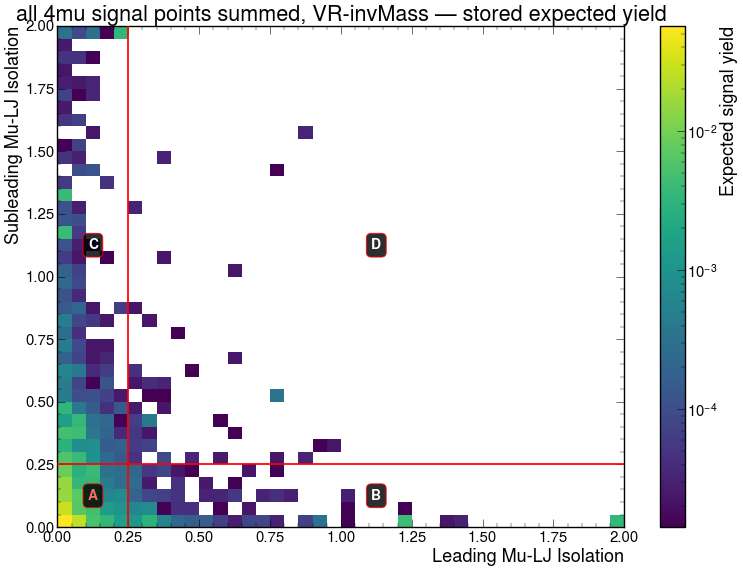

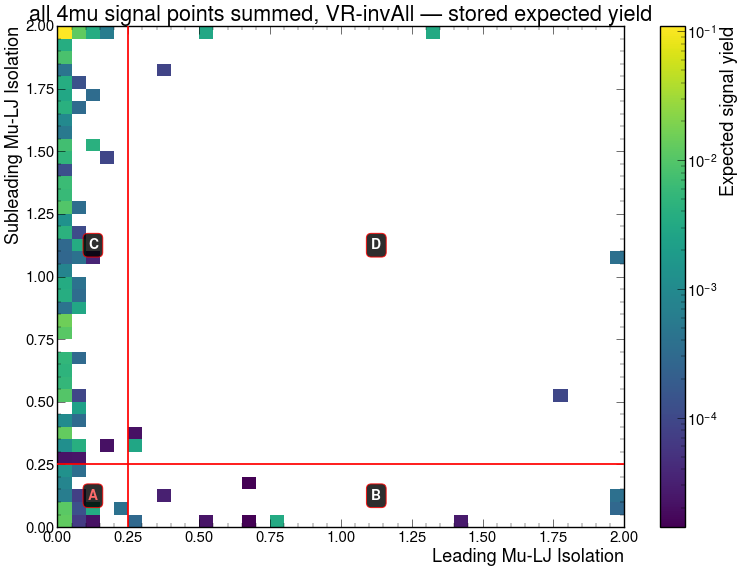

In [25]:
# Signal ABCD planes with the stored expected yields (no shape normalization).
SIGNAL_YIELD_PLANE_SAMPLES = SIGNAL_PLANE_SAMPLES
SIGNAL_YIELD_PLANE_SELECTIONS = SIGNAL_PLANE_SELECTIONS

if SIGNAL_YIELD_PLANE_SAMPLES:
    signal_yield_targets = [
        (sample, parse_signal_point(sample)["topology"], sample)
        for sample in SIGNAL_YIELD_PLANE_SAMPLES
    ]
else:
    signal_yield_targets = [
        ("Signal", topology, f"all {topology} signal points summed")
        for topology in CHANNEL_CONFIGS
    ]
    print(
        "CAUTION: these yields are summed over the full signal grid and do not "
        "represent a single physical benchmark. Set SIGNAL_PLANE_SAMPLES for "
        "benchmark-level expected yields."
    )

for target, topology, label in signal_yield_targets:
    cfg = CHANNEL_CONFIGS[topology]
    for selection in SIGNAL_YIELD_PLANE_SELECTIONS:
        plane = group_hist(target, topology, selection)
        if plane is None or values_variances(plane)[0].sum() <= 0:
            print(f"Skip empty plane: {label}, {selection}")
            continue
        fig, ax = plot_abcd_plane(
            plane, f"{label}, {selection} — stored expected yield",
            cfg, blind_a=False,
        )
        fig.axes[-1].set_ylabel("Expected signal yield")
        plt.show()
        plt.close(fig)


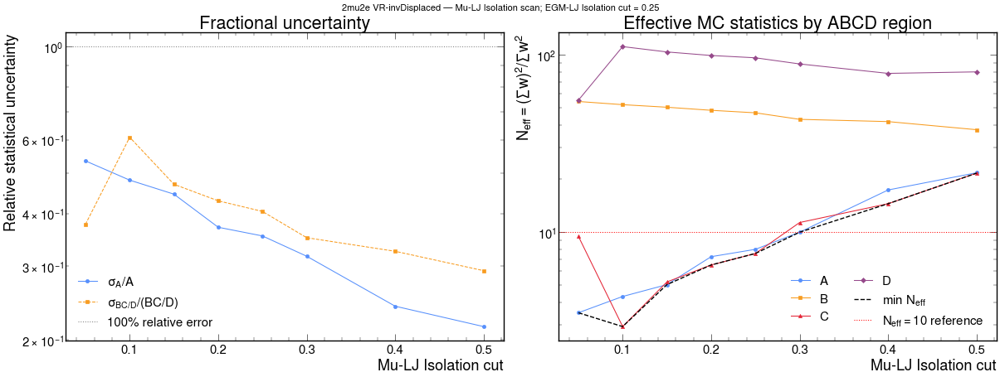

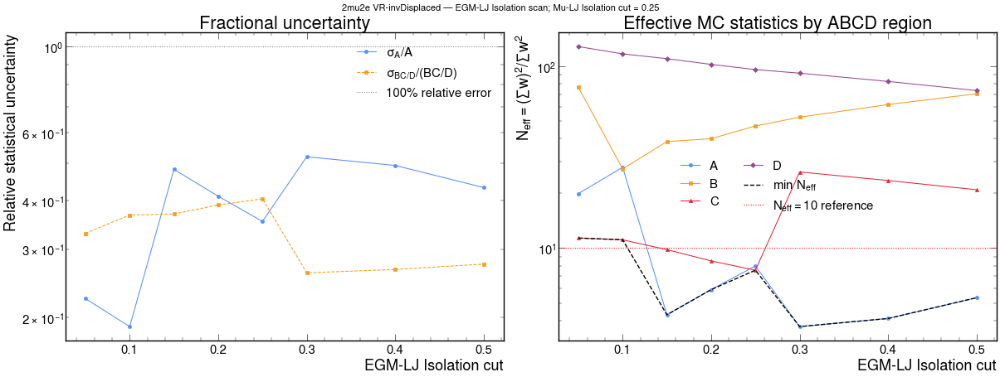

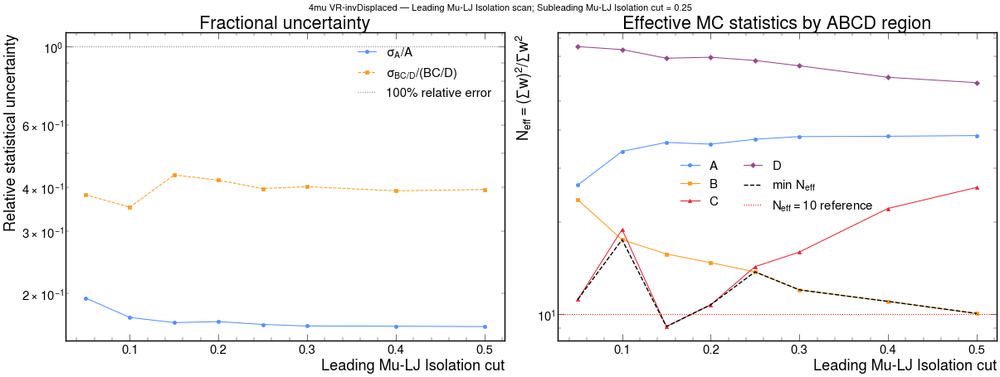

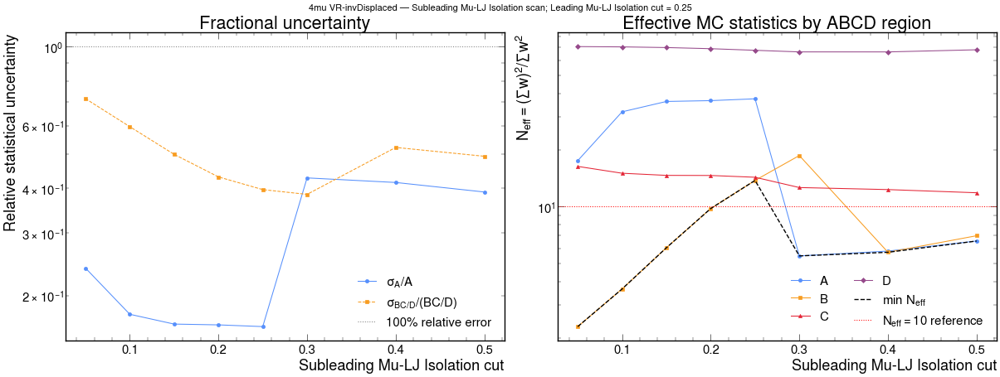

In [26]:
# Diagnostic companion to the one-axis closure scans.
CLOSURE_DIAGNOSTIC_SELECTIONS = ("VR-invDisplaced",)
CLOSURE_DIAGNOSTIC_AXES = ("x", "y")
NEFF_REFERENCE = 10.0

def closure_stat_diagnostic_row(h2d, cuts):
    values, variances = values_variances(h2d)
    stats = {}
    closure_inputs = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        error = np.sqrt(variance)
        stats[region] = {
            "yield": value,
            "error": error,
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
        closure_inputs[region] = (value, error)
    predicted, predicted_error = prediction(closure_inputs)
    observed = stats["A"]["yield"]
    observed_error = stats["A"]["error"]
    row = {
        "A_relative_error": (observed_error / observed if observed > 0 else np.nan),
        "prediction_relative_error": (
            predicted_error / predicted if predicted > 0 else np.nan),
        "A_prediction": predicted,
    }
    for region in "ABCD":
        row[f"{region}_neff"] = stats[region]["neff"]
    row["min_neff"] = np.nanmin([stats[r]["neff"] for r in "ABCD"])
    return row

closure_stat_diagnostics = {}
for topology, cfg in CHANNEL_CONFIGS.items():
    for selection in CLOSURE_DIAGNOSTIC_SELECTIONS:
        h2d = group_hist("BKG total", topology, selection)
        if h2d is None:
            continue
        for index, scan_axis in enumerate(CLOSURE_DIAGNOSTIC_AXES):
            fixed_cut = cfg["cuts"][1 - index]
            rows = []
            for scan_cut in SCAN_VALUES:
                cuts = ((scan_cut, fixed_cut) if scan_axis == "x"
                        else (fixed_cut, scan_cut))
                rows.append({
                    "scan_cut": scan_cut,
                    **closure_stat_diagnostic_row(h2d, cuts),
                })
            frame = pd.DataFrame(rows)
            closure_stat_diagnostics[(topology, selection, scan_axis)] = frame

            scan_label = cfg["x_label"] if scan_axis == "x" else cfg["y_label"]
            fixed_label = cfg["y_label"] if scan_axis == "x" else cfg["x_label"]
            fig, axes = plt.subplots(1, 2, figsize=(24, 9), constrained_layout=True)
            axes[0].plot(
                frame.scan_cut, frame.A_relative_error, "o-", label=r"$\sigma_A/A$",
            )
            axes[0].plot(
                frame.scan_cut, frame.prediction_relative_error, "s--",
                label=r"$\sigma_{B C/D}/(B C/D)$",
            )
            axes[0].axhline(1, color="gray", linestyle=":", label="100% relative error")
            axes[0].set_yscale("log")
            axes[0].set(
                xlabel=f"{scan_label} cut", ylabel="Relative statistical uncertainty",
                title="Fractional uncertainty",
            )
            axes[0].legend(frameon=False)

            for region, marker in zip("ABCD", ("o", "s", "^", "D")):
                axes[1].plot(
                    frame.scan_cut, frame[f"{region}_neff"],
                    marker=marker, label=region,
                )
            axes[1].plot(
                frame.scan_cut, frame.min_neff, "k--", linewidth=2, label=r"min $N_{eff}$",
            )
            axes[1].axhline(
                NEFF_REFERENCE, color="red", linestyle=":",
                label=fr"$N_{{eff}}={NEFF_REFERENCE:g}$ reference",
            )
            axes[1].set_yscale("log")
            axes[1].set(
                xlabel=f"{scan_label} cut", ylabel=r"$N_{eff}=(\sum w)^2/\sum w^2$",
                title="Effective MC statistics by ABCD region",
            )
            axes[1].legend(frameon=False, ncol=2)
            fig.suptitle(
                f"{topology} {selection} — {scan_label} scan; "
                f"{fixed_label} cut = {fixed_cut:.2f}",
                fontsize=16,
            )
            plt.show()
            plt.close(fig)


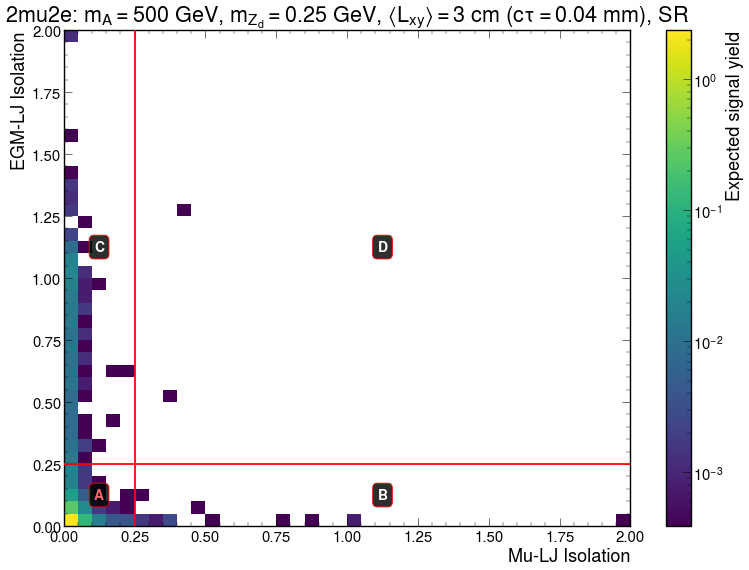

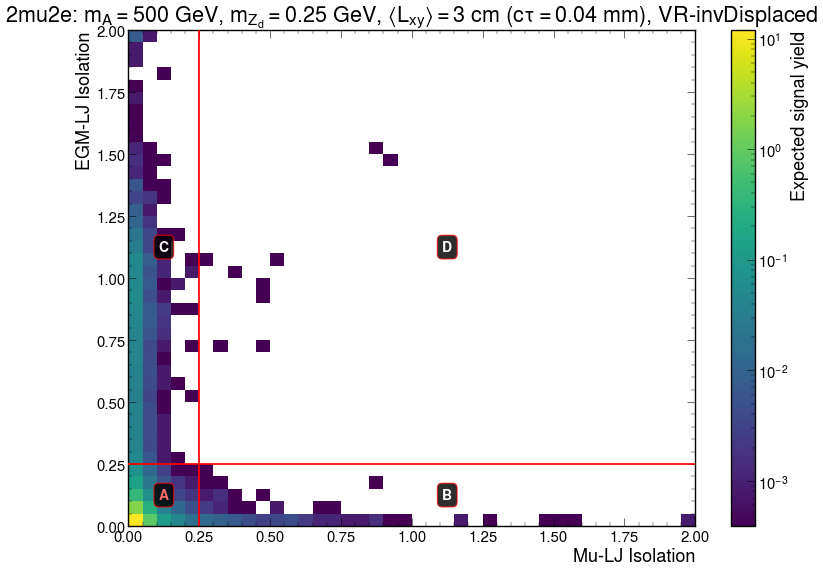

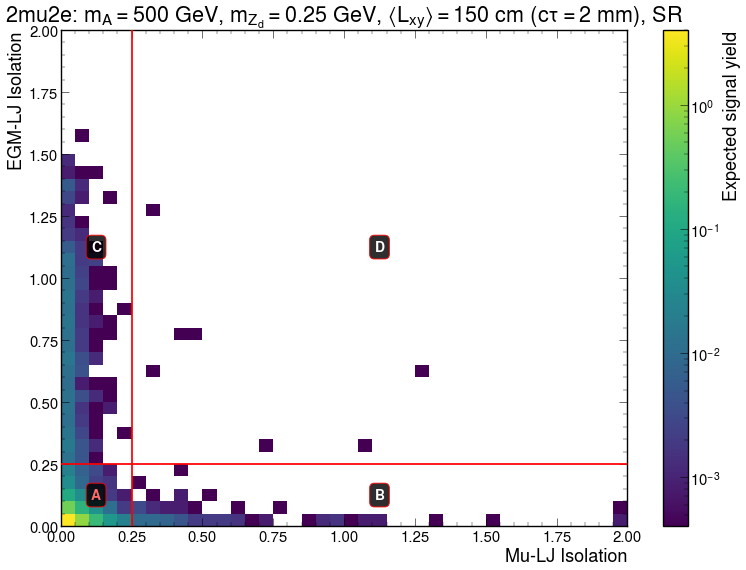

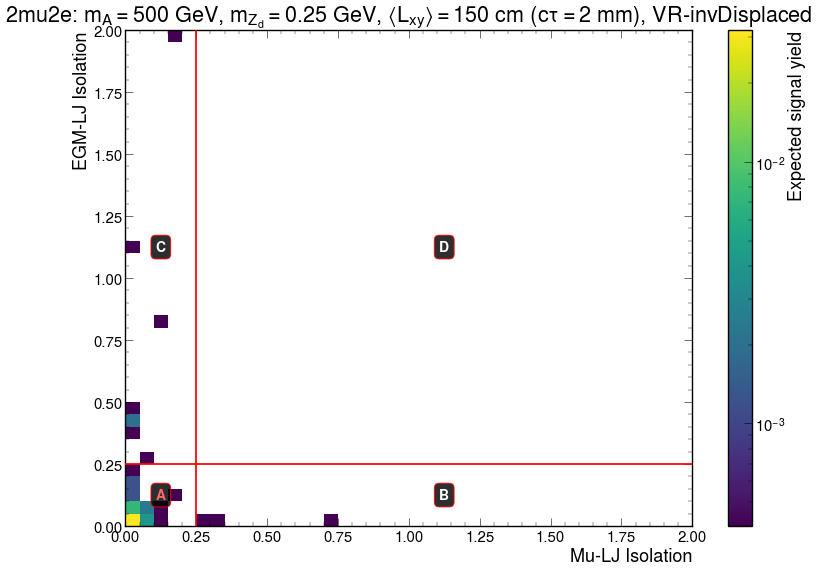

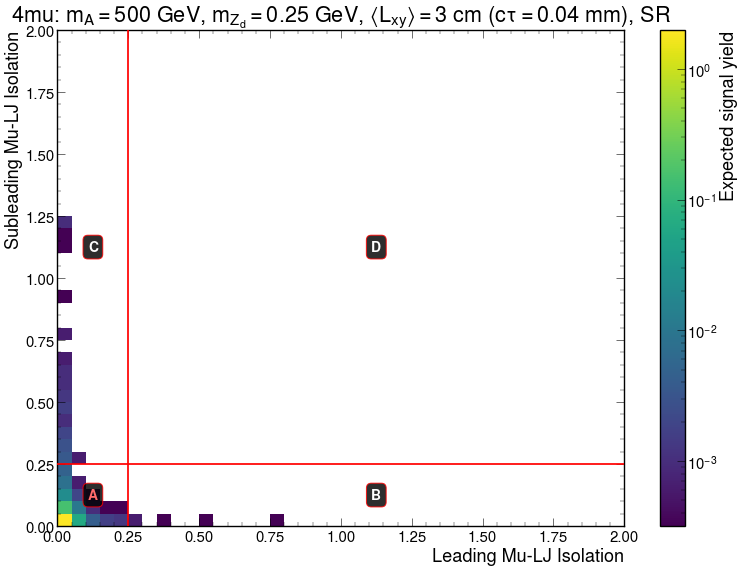

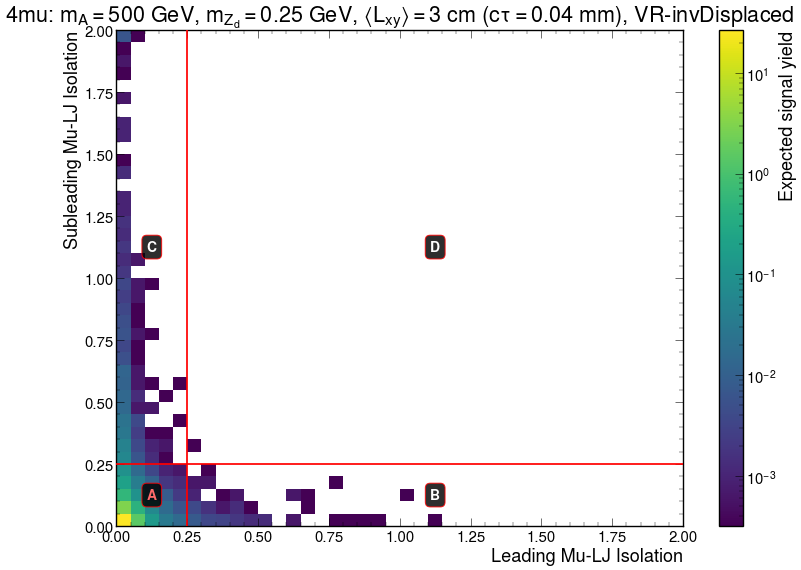

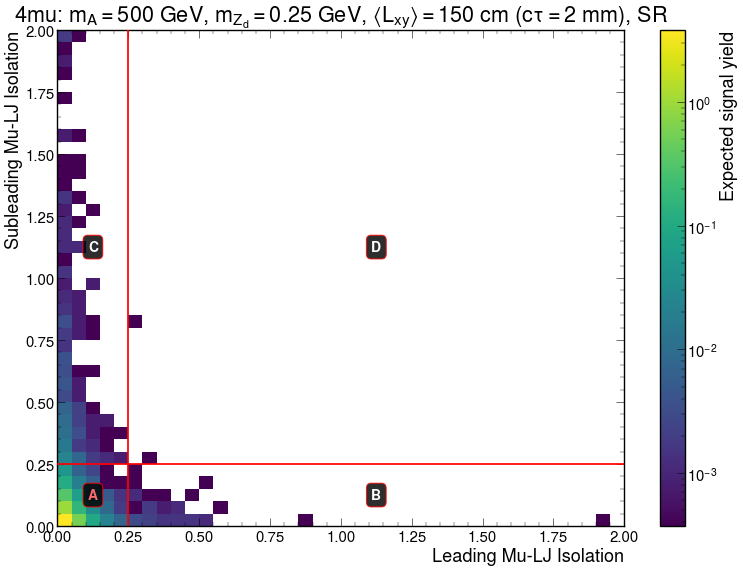

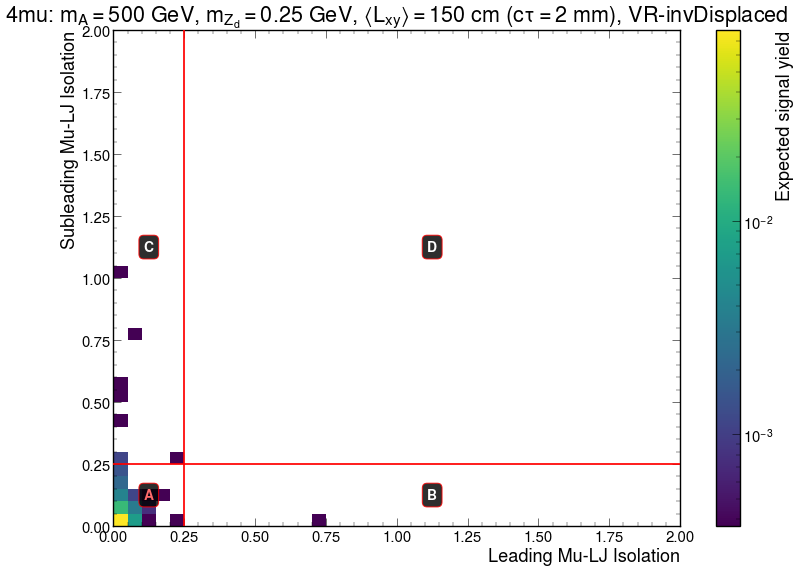

In [28]:
# Individual signal benchmarks in the ABCD planes (physical stored yields).
# For mA=500 GeV and mZd=0.25 GeV, the signal-grid conversion is:
# average transverse lab-frame Lxy [cm] = 0.3, 3, 30, 150, 300
# generated proper ctau [mm]              = 0.004, 0.04, 0.4, 2.0, 4.0
SIGNAL_LXY_TO_CTAU_TOKEN = {
    3: (0.04, "0p04mm"),
    150: (2.0, "2p0mm"),
}
SIGNAL_BENCHMARK_SELECTIONS = ("SR", "VR-invDisplaced")
SIGNAL_BENCHMARK_TOPOLOGIES = tuple(CHANNEL_CONFIGS)
SIGNAL_SAMPLE_PREFIX = {"2mu2e": "2Mu2E", "4mu": "4Mu"}

available_signal_samples = set(sample_groups.get("Signal", []))
benchmark_targets = []
for topology in SIGNAL_BENCHMARK_TOPOLOGIES:
    for mean_lxy_cm, (ctau_mm, ctau_token) in SIGNAL_LXY_TO_CTAU_TOKEN.items():
        sample_prefix = SIGNAL_SAMPLE_PREFIX[topology]
        sample = f"{sample_prefix}_500GeV_0p25GeV_{ctau_token}"
        if sample not in available_signal_samples:
            print(f"Missing benchmark sample: {sample}")
            continue
        benchmark_targets.append((sample, topology, mean_lxy_cm, ctau_mm))

for sample, topology, mean_lxy_cm, ctau_mm in benchmark_targets:
    cfg = CHANNEL_CONFIGS[topology]
    for selection in SIGNAL_BENCHMARK_SELECTIONS:
        plane = group_hist(sample, topology, selection)
        if plane is None or values_variances(plane)[0].sum() <= 0:
            print(f"Skip empty plane: {sample}, {selection}")
            continue

        title = (
            rf"{topology}: $m_A=500$ GeV, $m_{{Z_d}}=0.25$ GeV, "
            rf"$\langle L_{{xy}}\rangle={mean_lxy_cm:g}$ cm "
            rf"($c\tau={ctau_mm:g}$ mm), {selection}"
        )
        fig, ax = plot_abcd_plane(plane, title, cfg, blind_a=False)
        fig.axes[-1].set_ylabel("Expected signal yield")
        plt.show()
        plt.close(fig)


In [29]:
# Rank signal points with sizeable contamination in the inverted-displacement VR.
# S/B is computed after integrating every bin in each nominal ABCD region.
CONTAMINATION_SELECTION = "VR-invDisplaced"
CONTAMINATION_THRESHOLD = 0.10

high_contamination = (
    control_contamination.loc[
        (control_contamination.selection == CONTAMINATION_SELECTION)
        & np.isfinite(control_contamination.S_over_B_MC)
        & (control_contamination.S_over_B_MC >= CONTAMINATION_THRESHOLD),
        [
            "signal", "topology", "mA_GeV", "mZd_GeV", "ctau_mm",
            "region", "signal_yield", "background_mc_yield",
            "S_over_B_MC", "S_over_SplusB_MC", "signal_neff",
            "background_mc_neff", "small_background_flag",
        ],
    ]
    .sort_values("S_over_B_MC", ascending=False)
    .reset_index(drop=True)
)
high_contamination.index = np.arange(1, len(high_contamination) + 1)
high_contamination.index.name = "rank"

print(
    f"{CONTAMINATION_SELECTION}: {len(high_contamination)} signal point-region "
    f"entries have integrated S/B >= {100 * CONTAMINATION_THRESHOLD:.0f}%"
)
if not high_contamination.empty:
    print("Counts by ABCD region:", high_contamination.region.value_counts().to_dict())

display(
    high_contamination.style.format({
        "mA_GeV": "{:.0f}",
        "mZd_GeV": "{:.2g}",
        "ctau_mm": "{:.4g}",
        "signal_yield": "{:.3f}",
        "background_mc_yield": "{:.3f}",
        "S_over_B_MC": "{:.1%}",
        "S_over_SplusB_MC": "{:.1%}",
        "signal_neff": "{:.2f}",
        "background_mc_neff": "{:.2f}",
    })
)


VR-invDisplaced: 20 signal point-region entries have integrated S/B >= 10%
Counts by ABCD region: {'A': 20}


,signal,topology,mA_GeV,mZd_GeV,ctau_mm,region,signal_yield,background_mc_yield,S_over_B_MC,S_over_SplusB_MC,signal_neff,background_mc_neff,small_background_flag
rank,,,,,,,,,,,,,
1,4Mu_800GeV_5p0GeV_0p05mm,4mu,800,5,0.05,A,343.435,126.067,272.4%,73.1%,104144.00,37.38,False
2,4Mu_800GeV_1p2GeV_0p012mm,4mu,800,1.2,0.012,A,333.569,126.067,264.6%,72.6%,130394.00,37.38,False
3,4Mu_800GeV_0p25GeV_0p0025mm,4mu,800,0.25,0.0025,A,275.435,126.067,218.5%,68.6%,121065.00,37.38,False
4,4Mu_800GeV_5p0GeV_0p5mm,4mu,800,5,0.5,A,239.394,126.067,189.9%,65.5%,65965.00,37.38,False
5,4Mu_800GeV_1p2GeV_0p12mm,4mu,800,1.2,0.12,A,221.473,126.067,175.7%,63.7%,74863.00,37.38,False
6,4Mu_800GeV_0p25GeV_0p025mm,4mu,800,0.25,0.025,A,181.034,126.067,143.6%,58.9%,71700.00,37.38,False
7,4Mu_500GeV_1p2GeV_0p019mm,4mu,500,1.2,0.019,A,51.778,126.067,41.1%,29.1%,164663.00,37.38,False
8,4Mu_500GeV_5p0GeV_0p08mm,4mu,500,5,0.08,A,51.699,126.067,41.0%,29.1%,187450.00,37.38,False
9,4Mu_500GeV_0p25GeV_0p004mm,4mu,500,0.25,0.004,A,49.259,126.067,39.1%,28.1%,182954.00,37.38,False
